# Arithmetic — main experiments

**Purpose:** Reproduces every figure, table, and statistic in the
"Investigating Human Alignment in LLM Arithmetic" paper (Sec 3.4–3.5, Supp) for the 12B
Pythia-deduped model and the smaller Pythia model sweep.

**Source data:** the Pile (`EleutherAI/the_pile_deduplicated`) — see
`notebooks/01_corpus_scan.ipynb`.

---

## Report → notebook map

| Report section | Research question | Notebook section |
|---|---|---|
| Sec 3.4, Table 1, Fig 5 | RQ4 (10×10 4-op 4-shot) | Part 1, Part 2 (table), Part 2 (heatmaps) |
| Sec 3.4, Fig 6 | RQ4 (1- and 2-digit 4-shot) | Part 4, Part 6 (direct), Part 7 (inverse) |
| Sec 3.4 inverse-pair correlations | RQ4 (cross-op) | Part 7 (cross-op correlation cells) |
| Sec 3.5, Fig X | RQ5 (subproblem difficulty, 2-digit) | Part 9a (composite-surprisal), Part 9b (carry-stratified) |
| Sec 3.6, Fig X | Prominent operands | Part 9c (prominent-operands) |
| Supp: zero-shot Fig X | RQ4 zero-shot ablation | Part 2b, Part 2c |
| Supp: smaller Pythia models | RQ4 model-size sweep | Part 3a, Part 8 |

**Companion notebooks (other report figures):**

- `02_number_distribution.ipynb` — Fig 1 (RQ1, 1–100 distribution) and Fig 4 (RQ3, number production).
- `03_metrics_powerlaw.ipynb` — Fig 2 (RQ2, all ops pooled) and Fig 3 (RQ2, by operation).
- `01_corpus_scan.ipynb` — Method 2.2 (extract arith matches and integer counts from the Pile).

---

## Run order

1. `00_setup.ipynb`
2. `01_corpus_scan.ipynb` (or skip — uses cached outputs in `data/`)
3. `02_number_distribution.ipynb`
4. `03_metrics_powerlaw.ipynb`
5. `04_arithmetic_main.ipynb` ← **you are here**

---

## Configuration

Edit the configuration cell below to switch model, prompt style, and shot count.
Default is **pythia-12b-deduped** at **k = 4** shots, matching the paper's main results.


In [1]:
%%capture
%pip install torch transformers
%pip install -U "huggingface_hub[cli]"
%pip install accelerate

# (recommended inside a fresh venv/conda env)
%pip uninstall -y huggingface_hub
%pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
%python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

In [2]:
import os

ROOT = os.getcwd()
while ROOT != "/" and not os.path.isdir(os.path.join(ROOT, "hf", "hub")):
    ROOT = os.path.dirname(ROOT)
assert os.path.isdir(os.path.join(ROOT, "hf", "hub")), "could not locate <root>/hf/hub"

os.environ["HF_HOME"] = os.path.join(ROOT, "hf")
os.environ["HF_HUB_CACHE"] = os.path.join(ROOT, "hf", "hub")
os.environ["HF_DATASETS_CACHE"] = os.path.join(ROOT, "hf", "datasets")
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login

/storage/home/hcoda1/9/kzhang430/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!hf auth whoami

user:  wristycargo


# Arithmetic Experiments 2: Addition Statistics (operands 1–10)

**Goal**: Measure model surprisal and exact-match accuracy for addition equations of the form `a + b = c` where `a, b ∈ {1,...,10}`.

**Plan**:
1. Evaluate all 100 addition problems (a, b ∈ {1,...,10}) on Pythia
2. Summarize accuracy and surprisal overall and by carry status
3. Visualize the full `a × b` grid
4. Identify the lowest and highest scoring addition problems

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
import itertools
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment Configuration — edit here
# ─────────────────────────────────────────────────────────────────────────────
import random

MODEL_NAME = "EleutherAI/pythia-12b-deduped"   # Pythia model to evaluate

K_SHOT     = 4    # k-shot demonstrations prepended to every prompt (0 = zero-shot)
KSHOT_SEED = 42    # random seed for demo selection (ensures reproducibility)

BATCH_SIZE_LOGPROB  = 64   # batch size for surprisal eval (lower if OOM)
BATCH_SIZE_ACCURACY = 32   # batch size for greedy-decode eval

## Utilities: Model Loading

In [6]:
PYTHIA_MODELS = [
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1b-deduped",
    "EleutherAI/pythia-1.4b-deduped",
    "EleutherAI/pythia-2.8b-deduped",
    "EleutherAI/pythia-6.9b-deduped",
    "EleutherAI/pythia-12b-deduped",
]

def load_model(name, device=device):
    print(f"Loading {name}...")
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id
    tok.padding_side = "left"   # left-pad for correct batched generation (decoder-only)
    mdl = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    mdl.eval()
    n = sum(p.numel() for p in mdl.parameters()) / 1e6
    print(f"  Loaded: {n:.0f}M params on {next(mdl.parameters()).device}")
    return tok, mdl

## Utilities: Evaluation Functions

In [7]:
@torch.inference_mode()
def eval_logprob(model, tokenizer, df, batch_size=32, prompt_col="prompt", target_col="target"):
    """Compute per-example log-probabilities of the target given the prompt."""
    prompts = df[prompt_col].tolist()
    targets = df[target_col].astype(str).tolist()
    full_texts = [f"{p} {t}" for p, t in zip(prompts, targets)]
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    out_rows = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="logprob", leave=False):
        bp = prompts[i:i+batch_size]
        bf = full_texts[i:i+batch_size]
        prompt_enc = tokenizer(bp, add_special_tokens=False)
        full_enc = tokenizer(bf, add_special_tokens=False)

        batch_ids, batch_mask, prompt_lens, target_lens = [], [], [], []
        for p_ids, full_ids in zip(prompt_enc["input_ids"], full_enc["input_ids"]):
            if full_ids[:len(p_ids)] != p_ids:
                raise ValueError("Prompt tokens are not a prefix of the full prompt+target tokens.")
            t_len = len(full_ids) - len(p_ids)
            if t_len <= 0:
                raise ValueError("Target tokenization produced an empty suffix.")
            batch_ids.append(full_ids)
            batch_mask.append([1]*len(full_ids))
            prompt_lens.append(len(p_ids))
            target_lens.append(t_len)

        max_len = max(len(x) for x in batch_ids)
        padded_ids  = [ids  + [pad_id]*(max_len-len(ids))  for ids  in batch_ids]
        padded_mask = [mask + [0]*(max_len-len(mask)) for mask in batch_mask]

        input_ids      = torch.tensor(padded_ids,  device=model.device)
        attention_mask = torch.tensor(padded_mask, device=model.device)
        logits   = model(input_ids=input_ids, attention_mask=attention_mask).logits
        log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
        next_tok  = input_ids[:, 1:]
        token_lp  = log_probs.gather(2, next_tok.unsqueeze(-1)).squeeze(-1)

        for p_len, t_len, tlp in zip(prompt_lens, target_lens, token_lp):
            start = p_len - 1
            tgt_lp = tlp[start:start+t_len]
            out_rows.append({
                "target_logprob":     tgt_lp.sum().item(),
                "avg_target_logprob": tgt_lp.mean().item(),
                "n_target_tokens":    int(t_len),
            })

    result = df.copy()
    result["target_logprob"]     = [r["target_logprob"]     for r in out_rows]
    result["avg_target_logprob"] = [r["avg_target_logprob"] for r in out_rows]
    result["n_target_tokens"]    = [r["n_target_tokens"]    for r in out_rows]
    # surprisal = negative TOTAL (summed) target log-prob = -log P(answer | prompt).
    # We use the sum, not the per-token mean, so multi-token answers (e.g. a
    # negative result "-9" tokenizes as [' -', '9']) are not diluted by the easy
    # magnitude token. NOTE: total log-prob grows with answer length, so
    # comparisons across answers/operations with differing token counts also
    # reflect how many tokens the answer takes (see n_target_tokens).
    result["surprisal"]          = -result["target_logprob"]
    return result

In [8]:
@torch.inference_mode()
def eval_accuracy(model, tokenizer, df, batch_size=16, prompt_col="prompt",
                  target_col="target", max_new_tokens=6):
    """Greedy decoding + exact-match accuracy."""
    prompts = df[prompt_col].tolist()
    targets = df[target_col].astype(str).tolist()
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    preds = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="accuracy", leave=False):
        bp  = prompts[i:i+batch_size]
        enc = tokenizer(bp, return_tensors="pt", padding=True,
                        add_special_tokens=False).to(model.device)
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=pad_id
        )
        for inp_ids, out_ids in zip(enc["input_ids"], out):
            gen = tokenizer.decode(out_ids[len(inp_ids):],
                                   skip_special_tokens=True).strip()
            m = re.match(r"(-?\d+)", gen)
            preds.append(m.group(1) if m else gen)

    result = df.copy()
    result["prediction"] = preds
    result["correct"]    = [p.strip() == t.strip() for p, t in zip(preds, targets)]
    return result

### Tokenization Sanity Check

This quick check shows why we score the fully tokenized `prompt + " " + target` string instead of tokenizing the prompt and target separately. For GPT-style tokenizers, the natural continuation after `=` is often a single whitespace-prefixed number token such as `" 1"` or `" 12"`.

In [9]:
# # Token-boundary sanity check for arithmetic prompts
# examples = [
#     "1 + 1 = 2",
#     "1 + 1 = ",
#     "2",
#     " 2",
#     "10 + 10 = 20",
#     "20",
#     " 20",
# ]

# for text in examples:
#     ids = tokenizer.encode(text, add_special_tokens=False)
#     toks = [tokenizer.decode([tok_id]) for tok_id in ids]
#     print(f"{text!r}")
#     print(f"  ids : {ids}")
#     print(f"  toks: {toks}")
#     print()

# print("Observation:")
# print("  Full strings like '1 + 1 = 2' typically end in a single token such as ' 2'.")
# print("  If you tokenize the prompt and target separately, you instead force the model")
# print("  to score a standalone space token followed by '2', which is a different continuation.")

In [10]:
# ─── K-shot Prompting Utilities ──────────────────────────────────────────────
#
# We use a fixed prefix (same k demonstrations for every query) rather than
# per-query dynamic selection. This is the standard approach for logprob/
# surprisal evaluation because it keeps the context identical across queries,
# making surprisal values directly comparable. The only downside is a small
# risk that the query itself appears in the demos; with k <= 16 and 100+
# problems this is unlikely, but `apply_kshot_prefix` optionally excludes
# the exact query row to be safe.
#
# If you prefer per-query selection (e.g. for few-shot accuracy studies),
# replace `build_kshot_prefix` with a function that samples differently per row.

def build_kshot_prefix(k, problem_type="single_addition", seed=KSHOT_SEED):
    """
    Build a fixed k-shot demonstration string.

    Parameters
    ----------
    k            : int  number of demonstrations (0 returns empty string)
    problem_type : str  "single_addition" (a+b=, a,b in 1..10) or "2digit" (A+B=)
    seed         : int  RNG seed for reproducibility

    Returns
    -------
    str  newline-separated demonstration lines.
    """
    if k == 0:
        return ""

    rng = random.Random(seed)

    if problem_type == "single_addition":
        pool = [(a, b) for a, b in itertools.product(range(1, 11), range(1, 11))]
        rng.shuffle(pool)
        lines = [f"{a} + {b} = {a+b}" for a, b in pool[:k]]

    elif problem_type == "2digit":
        pool = [(A, B) for A in range(10, 100) for B in range(10, 100)]
        rng.shuffle(pool)
        lines = [f"{A} + {B} = {A+B}" for A, B in pool[:k]]

    else:
        raise ValueError(f"Unknown problem_type: {problem_type!r}")

    return "\n".join(lines)


def apply_kshot_prefix(df, prefix, prompt_col="prompt", out_col="eval_prompt"):
    """
    Prepend `prefix` to every prompt in df[prompt_col], storing the result in
    df[out_col]. Pass `prompt_col="eval_prompt"` to `eval_logprob` /
    `eval_accuracy`.

    If prefix is empty, `eval_prompt == prompt` (zero-shot pass-through).
    """
    df = df.copy()
    df[out_col] = (prefix + "\n" + df[prompt_col]) if prefix else df[prompt_col]
    return df


# Quick sanity-check
_demo = build_kshot_prefix(K_SHOT, "single_addition")
print(f"K_SHOT = {K_SHOT}")
if _demo:
    print(f"Demo prefix ({K_SHOT} examples):")
    print(_demo)
else:
    print("Zero-shot mode - no prefix added.")

K_SHOT = 4
Demo prefix (4 examples):
5 + 3 = 8
5 + 2 = 7
10 + 2 = 12
1 + 10 = 11


## Utilities: Pretraining Frequency

In [11]:
JSONL_PATH = "../data/pile_arith_matches_full_fresh_deduped.jsonl"

def load_freq_counts(path=JSONL_PATH):
    """
    Load addition-specific frequency counts from Pile JSONL.
    freq_ab[(a,b)] = # times 'a + b' appeared (all digit lengths).
    freq_digit[d]  = # times operand d (d in 1..10) appeared in any + expression.
    """
    freq_ab    = Counter()
    freq_digit = Counter()

    with open(path, "r") as f:
        for line in f:
            r = json.loads(line.strip())
            if r.get("op") != "+":
                continue
            a, b = int(r["a"]), int(r["b"])
            freq_ab[(a, b)] += 1
            # Accumulate per-operand frequencies for operands in 1..10
            if 1 <= a <= 10:
                freq_digit[a] += 1
            if 1 <= b <= 10:
                freq_digit[b] += 1

    total = sum(freq_ab.values())
    print(f"Loaded {total:,} '+' expressions from Pile")
    print(f"  Unique (a,b) pairs: {len(freq_ab):,}")
    return freq_ab, freq_digit

freq_ab, freq_digit = load_freq_counts()

Loaded 90,286 '+' expressions from Pile
  Unique (a,b) pairs: 14,062


---
# Part 1: Addition (operands 1–10)

We evaluate all **100 problems** of the form `a + b =` where:
- `a, b ∈ {1,...,10}`

These 100 problems cover every `(a, b)` pair with both operands in `{1,...,10}`.

We measure both **surprisal** (negative total/summed log-prob of the correct answer) and **exact-match accuracy** (greedy decoding).

In [12]:
# ── Generate all addition problems (operands 1..10) ─────────────────────────
def gen_single_digit_addition_problems():
    rows = []
    for a, b in itertools.product(range(1, 11), range(1, 11)):
        result = a + b
        prompt = f"{a} + {b} ="
        rows.append({
            "a": a,
            "b": b,
            "c": result,
            "prompt": prompt,
            "target": str(result),
            "has_carry": int(result >= 10),
            "digit_sum": result,
            "freq_a": freq_digit.get(a, 0),
            "freq_b": freq_digit.get(b, 0),
        })
    return pd.DataFrame(rows)


df_single = gen_single_digit_addition_problems()
print(f"Generated {len(df_single)} addition problems (a, b in 1..10)")
print(df_single[["prompt", "target", "has_carry"]].sample(8, random_state=0))

Generated 100 addition problems (a, b in 1..10)
      prompt target  has_carry
26   3 + 7 =     10          1
86   9 + 7 =     16          1
2    1 + 3 =      4          0
55   6 + 6 =     12          1
75   8 + 6 =     14          1
93  10 + 4 =     14          1
16   2 + 7 =      9          0
73   8 + 4 =     12          1


In [13]:
# ── Load model (MODEL_NAME set in Config cell above) ─────────────────────────
tokenizer, model = load_model(MODEL_NAME)

Loading EleutherAI/pythia-12b-deduped...


Loading checkpoint shards: 100%|██████████| 3/3 [01:33<00:00, 31.23s/it]

  Loaded: 11846M params on cuda:0


In [14]:
# ── Fix: left-pad for batched generation (decoder-only models) ─────────────
# Right padding corrupts model.generate() outputs for shorter sequences in a
# batch (the "right padding was detected" warning). This affects every accuracy
# eval (eval_accuracy); surprisal/eval_logprob is unaffected (it pads manually
# and gathers at the correct positions). Safe to run on the already-loaded
# tokenizer -- no need to reload the 12B model.
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
print(f"tokenizer.padding_side = {tokenizer.padding_side!r}  (re-run the accuracy cells after this)")


tokenizer.padding_side = 'left'  (re-run the accuracy cells after this)


In [15]:
# ── Evaluate single-digit addition problems ─────────────────────────────────
_prefix_single = build_kshot_prefix(K_SHOT)
df_single_kshot = apply_kshot_prefix(df_single, _prefix_single)

df_single_eval = eval_logprob(
    model,
    tokenizer,
    df_single_kshot,
    batch_size=BATCH_SIZE_LOGPROB,
    prompt_col="eval_prompt",
)
df_single_eval = eval_accuracy(
    model,
    tokenizer,
    df_single_eval,
    batch_size=BATCH_SIZE_ACCURACY,
    prompt_col="eval_prompt",
)
df_single_eval["model"] = MODEL_NAME
df_single_eval["k_shot"] = K_SHOT

print(f"K_SHOT={K_SHOT}  |  Overall accuracy : {df_single_eval['correct'].mean():.3f}")
print(f"K_SHOT={K_SHOT}  |  Mean surprisal   : {df_single_eval['surprisal'].mean():.3f}")
print()
print("By carry status (sum >= 10):")
print(df_single_eval.groupby("has_carry")[["correct", "surprisal"]].mean())

K_SHOT=4  |  Overall accuracy : 1.000
K_SHOT=4  |  Mean surprisal   : 0.033

By carry status (sum >= 10):
           correct  surprisal
has_carry                    
0              1.0   0.016355
1              1.0   0.043049


In [16]:
# ── Prefix-robustness check: repeat the single-digit eval over several fixed seeds ──
#
# The cell above is the canonical run (seed=KSHOT_SEED) that feeds all downstream
# analysis. Here we re-run the same evaluation under a few *different* fixed prefixes
# to confirm the carry effect isn't an artifact of one particular demo draw.
# Each seed still uses ONE fixed prefix for all queries (required for comparable
# surprisal); we vary only which prefix, then report mean +/- std across seeds.

PREFIX_SEEDS = [KSHOT_SEED, 1, 7, 123, 2024]

_seed_rows = []
for _s in PREFIX_SEEDS:
    _prefix = build_kshot_prefix(K_SHOT, "single_addition", seed=_s)
    _df = apply_kshot_prefix(df_single, _prefix)
    _df = eval_logprob(model, tokenizer, _df,
                       batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    _df = eval_accuracy(model, tokenizer, _df,
                        batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    g = _df.groupby("has_carry")[["correct", "surprisal"]].mean()
    g["seed"] = _s
    _seed_rows.append(g.reset_index())

df_seed_sweep = pd.concat(_seed_rows, ignore_index=True)

# Spread across prefixes, per carry status
seed_summary = (df_seed_sweep
                .groupby("has_carry")[["correct", "surprisal"]]
                .agg(["mean", "std"])
                .round(3))
print(f"K_SHOT={K_SHOT}  |  prefix seeds: {PREFIX_SEEDS}")
print("Across-prefix mean +/- std, by carry status:")
print(seed_summary)
print()
# Carry effect (carry - no_carry) per seed, to check the sign is stable
_piv = df_seed_sweep.pivot(index="seed", columns="has_carry", values="surprisal")
_piv["carry_surprisal_gap"] = _piv[1] - _piv[0]
print("Surprisal gap (carry - no_carry) per prefix seed:")
print(_piv["carry_surprisal_gap"].round(3))


K_SHOT=4  |  prefix seeds: [42, 1, 7, 123, 2024]
Across-prefix mean +/- std, by carry status:
          correct        surprisal       
             mean    std      mean    std
has_carry                                
0           1.000  0.000     0.014  0.003
1           0.997  0.007     0.050  0.019

Surprisal gap (carry - no_carry) per prefix seed:
seed
1       0.047
7       0.024
42      0.027
123     0.066
2024    0.015
Name: carry_surprisal_gap, dtype: float64


### Are there significant differences across addition problems?

In [17]:
from scipy.stats import f_oneway, variation

surp_vals = df_single_eval["surprisal"].values
acc_vals  = df_single_eval["correct"].values.astype(float)

cv = variation(surp_vals)
print(f"Surprisal — min: {surp_vals.min():.3f}  max: {surp_vals.max():.3f}"
      f"  std: {surp_vals.std():.3f}  CV: {cv:.3f}")
print(f"Accuracy  — min: {acc_vals.min():.3f}  max: {acc_vals.max():.3f}"
      f"  std: {acc_vals.std():.3f}")
print()

# One-way ANOVA: surprisal grouped by digit_sum (proxy for intrinsic difficulty)
groups = [df_single_eval[df_single_eval["digit_sum"]==s]["surprisal"].values
          for s in sorted(df_single_eval["digit_sum"].unique())]
groups = [g for g in groups if len(g) > 1]
F, p = f_oneway(*groups)
print(f"ANOVA (surprisal ~ digit_sum): F={F:.2f}, p={p:.3e}")
print(f"  → {'Significant' if p < 0.05 else 'Not significant'} variation across digit-sum groups")

print()
print("Mean surprisal by digit_sum:")
print(df_single_eval.groupby("digit_sum")["surprisal"].mean().round(3).to_string())

Surprisal — min: 0.002  max: 0.368  std: 0.052  CV: 1.550
Accuracy  — min: 1.000  max: 1.000  std: 0.000

ANOVA (surprisal ~ digit_sum): F=1.01, p=4.516e-01
  → Not significant variation across digit-sum groups

Mean surprisal by digit_sum:
digit_sum
2     0.006
3     0.003
4     0.023
5     0.013
6     0.024
7     0.016
8     0.015
9     0.016
10    0.041
11    0.055
12    0.024
13    0.049
14    0.028
15    0.043
16    0.039
17    0.112
18    0.016
19    0.031
20    0.023


### Heatmaps: Accuracy and Surprisal

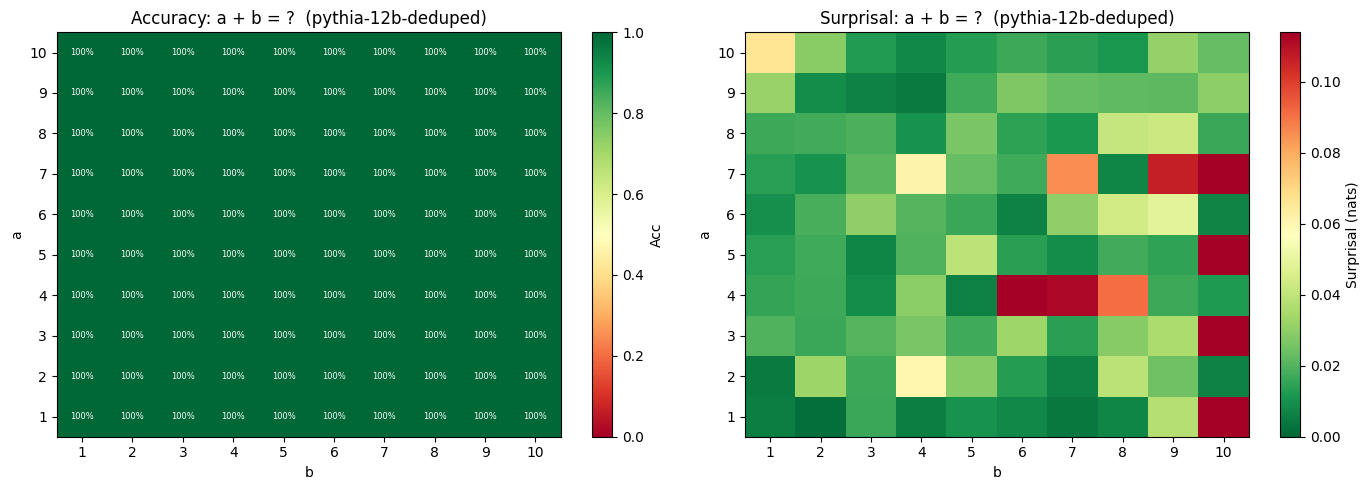

In [18]:
fig, (ax_acc, ax_surp) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy heatmap
piv_acc = df_single_eval.pivot(index="a", columns="b", values="correct")
im = ax_acc.imshow(piv_acc.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto", origin="lower")
ax_acc.set_xticks(range(10)); ax_acc.set_yticks(range(10))
ax_acc.set_xticklabels(range(1, 11)); ax_acc.set_yticklabels(range(1, 11))
ax_acc.set_xlabel("b"); ax_acc.set_ylabel("a")
ax_acc.set_title(f"Accuracy: a + b = ?  ({MODEL_NAME.split('/')[-1]})")
plt.colorbar(im, ax=ax_acc, label="Acc")
for i in range(10):
    for j in range(10):
        v = piv_acc.values[i, j]
        ax_acc.text(j, i, f"{v:.0%}", ha="center", va="center",
                    fontsize=6, color="black" if 0.2 < v < 0.85 else "white")

# Surprisal heatmap
piv_surp = df_single_eval.pivot(index="a", columns="b", values="surprisal")
vmax = df_single_eval["surprisal"].quantile(0.95)
im2 = ax_surp.imshow(piv_surp.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto", origin="lower")
ax_surp.set_xticks(range(10)); ax_surp.set_yticks(range(10))
ax_surp.set_xticklabels(range(1, 11)); ax_surp.set_yticklabels(range(1, 11))
ax_surp.set_xlabel("b"); ax_surp.set_ylabel("a")
ax_surp.set_title(f"Surprisal: a + b = ?  ({MODEL_NAME.split('/')[-1]})")
plt.colorbar(im2, ax=ax_surp, label="Surprisal (nats)")

plt.tight_layout()
plt.savefig("../results/figures/single_digit_addition_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part 2: All Four Operations (+, −, ×, ÷)

We extend the addition analysis to all four operations over the same 10×10 grid (`a, b ∈ {1,...,10}`, 100 problems each).

**Design choices (defaults used here):**

- **Inverse framing for − and ÷.** Subtraction is the inverse of addition and division the inverse of multiplication, so each cell `(a, b)` is defined as the operation that *undoes* its partner:
  - addition: `a + b = (a+b)`
  - subtraction: `(a+b) − b = a`
  - multiplication: `a × b = (a·b)`
  - division: `(a·b) ÷ b = a`

  This keeps all 100 cells integer-valued and makes − / ÷ the literal per-cell inverses of + / ×, which the cross-operation analysis (below) relies on.
- **Prompts use ASCII operators** `+ - * /` (e.g. `12 / 4 =`).
- **Problem size** = the largest number appearing in the equation (max magnitude of operands and answer).
- **Pile frequency** = count of the exact displayed expression `x op y`, merging unicode variants (`×`→`*`, `÷`→`/`).

The table below reports, per operation: mean accuracy (± std), and the Pearson correlation (with p-value) of surprisal with problem size and with log Pile frequency. Figure 5 shows the surprisal heatmaps. Finally we test whether accuracy on inverse pairs is more correlated than on non-inverse pairs.

In [19]:
# ── Pile frequency for all four operations ──────────────────────────────────
# freq_expr[(op, x, y)] = # times the exact expression 'x op y' appears in the Pile.
# Unicode variants are merged onto ASCII ops:  '×' -> '*',  '÷' -> '/'.
_OP_CANON = {"+": "+", "-": "-", "*": "*", "×": "*", "/": "/", "÷": "/"}

def load_freq_expr(path=JSONL_PATH):
    freq = Counter()
    with open(path, "r") as f:
        for line in f:
            r = json.loads(line.strip())
            op = _OP_CANON.get(r.get("op"))
            if op is None:
                continue
            freq[(op, int(r["a"]), int(r["b"]))] += 1
    return freq

freq_expr = load_freq_expr()
print(f"Loaded {sum(freq_expr.values()):,} expressions across {len(freq_expr):,} unique (op, a, b) keys")
for op in ["+", "-", "*", "/"]:
    n = sum(v for (o, _, _), v in freq_expr.items() if o == op)
    print(f"  {op}: {n:,} expressions")


Loaded 204,073 expressions across 39,151 unique (op, a, b) keys
  +: 90,286 expressions
  -: 51,995 expressions
  *: 44,412 expressions
  /: 17,380 expressions


In [20]:
# ── Problem generation for all four operations ──────────────────────────────
OPS        = ["+", "-", "*", "/"]
OP_NAMES   = {"+": "addition", "-": "subtraction", "*": "multiplication", "/": "division"}
OP_SYMBOL  = {"+": "+", "-": "-", "*": "*", "/": "/"}   # symbol shown in prompts

def op_cell(op, a, b):
    """Return (x, y, answer) shown for operation `op` at grid cell (a, b).
    Inverse framing: subtraction undoes addition, division undoes multiplication."""
    if op == "+":  return a,     b, a + b      # a + b = a+b
    if op == "-":  return a + b, b, a          # (a+b) - b = a
    if op == "*":  return a,     b, a * b      # a * b = a*b
    if op == "/":  return a * b, b, a          # (a*b) / b = a
    raise ValueError(f"Unknown op: {op!r}")

def gen_problems(op):
    sym = OP_SYMBOL[op]
    rows = []
    for a, b in itertools.product(range(1, 11), range(1, 11)):
        x, y, ans = op_cell(op, a, b)
        rows.append({
            "op": op, "a": a, "b": b, "x": x, "y": y, "answer": ans,
            "prompt": f"{x} {sym} {y} =",
            "target": str(ans),
            "problem_size": max(abs(x), abs(y), abs(ans)),   # largest number in eqn
            "freq": freq_expr.get((op, x, y), 0),            # Pile frequency of 'x op y'
        })
    return pd.DataFrame(rows)

problem_dfs = {op: gen_problems(op) for op in OPS}

print("Generated 100 problems per operation (a, b in 1..10). Example cell (a=3, b=4):")
for op in OPS:
    r = problem_dfs[op].query("a == 3 and b == 4").iloc[0]
    print(f"  {OP_NAMES[op]:14s}: {r['prompt']} {r['target']:>3}   "
          f"size={r['problem_size']:>3}  pile_freq={r['freq']}")


Generated 100 problems per operation (a, b in 1..10). Example cell (a=3, b=4):
  addition      : 3 + 4 =   7   size=  7  pile_freq=1468
  subtraction   : 7 - 4 =   3   size=  7  pile_freq=165
  multiplication: 3 * 4 =  12   size= 12  pile_freq=461
  division      : 12 / 4 =   3   size= 12  pile_freq=124


In [21]:
# ── Evaluate all four operations (surprisal + accuracy) ─────────────────────
# Each operation uses its own fixed k-shot prefix (same k demos for every query
# within that operation), keeping surprisals comparable within an operation.

def build_kshot_prefix_op(op, k=K_SHOT, seed=KSHOT_SEED):
    """Fixed k-shot demo string for `op`, sampled from the 10x10 (a,b) grid."""
    if k == 0:
        return ""
    rng = random.Random(seed)
    cells = list(itertools.product(range(1, 11), range(1, 11)))
    rng.shuffle(cells)
    sym = OP_SYMBOL[op]
    lines = []
    for a, b in cells[:k]:
        x, y, ans = op_cell(op, a, b)
        lines.append(f"{x} {sym} {y} = {ans}")
    return "\n".join(lines)

results = {}
for op in OPS:
    prefix = build_kshot_prefix_op(op)
    dfk = apply_kshot_prefix(problem_dfs[op], prefix)
    dfk = eval_logprob(model, tokenizer, dfk,
                       batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    dfk = eval_accuracy(model, tokenizer, dfk,
                        batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    dfk["model"]  = MODEL_NAME
    dfk["k_shot"] = K_SHOT
    results[op] = dfk
    print(f"{OP_NAMES[op]:14s} | acc = {dfk['correct'].mean():.3f} | mean surprisal = {dfk['surprisal'].mean():.3f}")


addition       | acc = 1.000 | mean surprisal = 0.033


subtraction    | acc = 1.000 | mean surprisal = 0.047


multiplication | acc = 1.000 | mean surprisal = 0.028


division       | acc = 0.970 | mean surprisal = 0.137


In [22]:
# ── Per-operation summary table ─────────────────────────────────────────────
# One row per operation:
#   mean_acc, std_acc                      — accuracy across the 100 problems
#   r_surp_size, p_size                    — Pearson corr of surprisal with problem size
#   r_surp_freq, p_freq                    — Pearson corr of surprisal with log1p(Pile freq)
from scipy.stats import pearsonr

def safe_pearson(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if np.std(x) == 0 or np.std(y) == 0 or len(x) < 3:
        return np.nan, np.nan
    r, p = pearsonr(x, y)
    return r, p

rows = []
for op in OPS:
    d = results[op]
    surp = d["surprisal"].values
    acc  = d["correct"].astype(float).values
    size = d["problem_size"].values.astype(float)
    logf = np.log1p(d["freq"].values.astype(float))
    r_size, p_size = safe_pearson(surp, size)
    r_freq, p_freq = safe_pearson(surp, logf)
    rows.append({
        "operation":   OP_NAMES[op],
        "mean_acc":    acc.mean(),
        "std_acc":     acc.std(),
        "r_surp_size": r_size,
        "p_size":      p_size,
        "r_surp_freq": r_freq,
        "p_freq":      p_freq,
    })

summary_table = pd.DataFrame(rows).set_index("operation")

print("Per-operation summary  (100 problems each; a, b in 1..10)")
print("  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)")
print("  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')")
print()
print(summary_table.to_string(float_format=lambda v: f"{v: .4g}"))
print()
print("Sentence-ready mean accuracy by operation:")
for op in OPS:
    a = results[op]["correct"].astype(float)
    print(f"  {OP_NAMES[op]:14s}: {a.mean():.3f}  (std {a.std():.3f})")

summary_table


Per-operation summary  (100 problems each; a, b in 1..10)
  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)
  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')

                mean_acc  std_acc  r_surp_size   p_size  r_surp_freq    p_freq
operation                                                                     
addition               1        0       0.2118  0.03435      -0.2804  0.004716
subtraction            1        0      0.04627   0.6476     -0.09151    0.3652
multiplication         1        0     -0.06515   0.5196       0.1312    0.1931
division            0.97   0.1706       0.2383  0.01695       -0.254   0.01078

Sentence-ready mean accuracy by operation:
  addition      : 1.000  (std 0.000)
  subtraction   : 1.000  (std 0.000)
  multiplication: 1.000  (std 0.000)
  division      : 0.970  (std 0.171)


,mean_acc,std_acc,r_surp_size,p_size,r_surp_freq,p_freq
operation,,,,,,
addition,1.00,0.000000,0.211846,0.034353,-0.280417,0.004716
subtraction,1.00,0.000000,0.046265,0.647612,-0.091515,0.365178
multiplication,1.00,0.000000,-0.065150,0.519582,0.131222,0.193135
division,0.97,0.170587,0.238323,0.016950,-0.253975,0.010779


### Figure 5: Surprisal heatmaps for each operation

Since accuracy is near-uniform within each operation (see the table above), we do not show accuracy heatmaps. Instead, Figure 5 shows the full `a × b` **surprisal** grid for all four operations, on a shared colour scale.

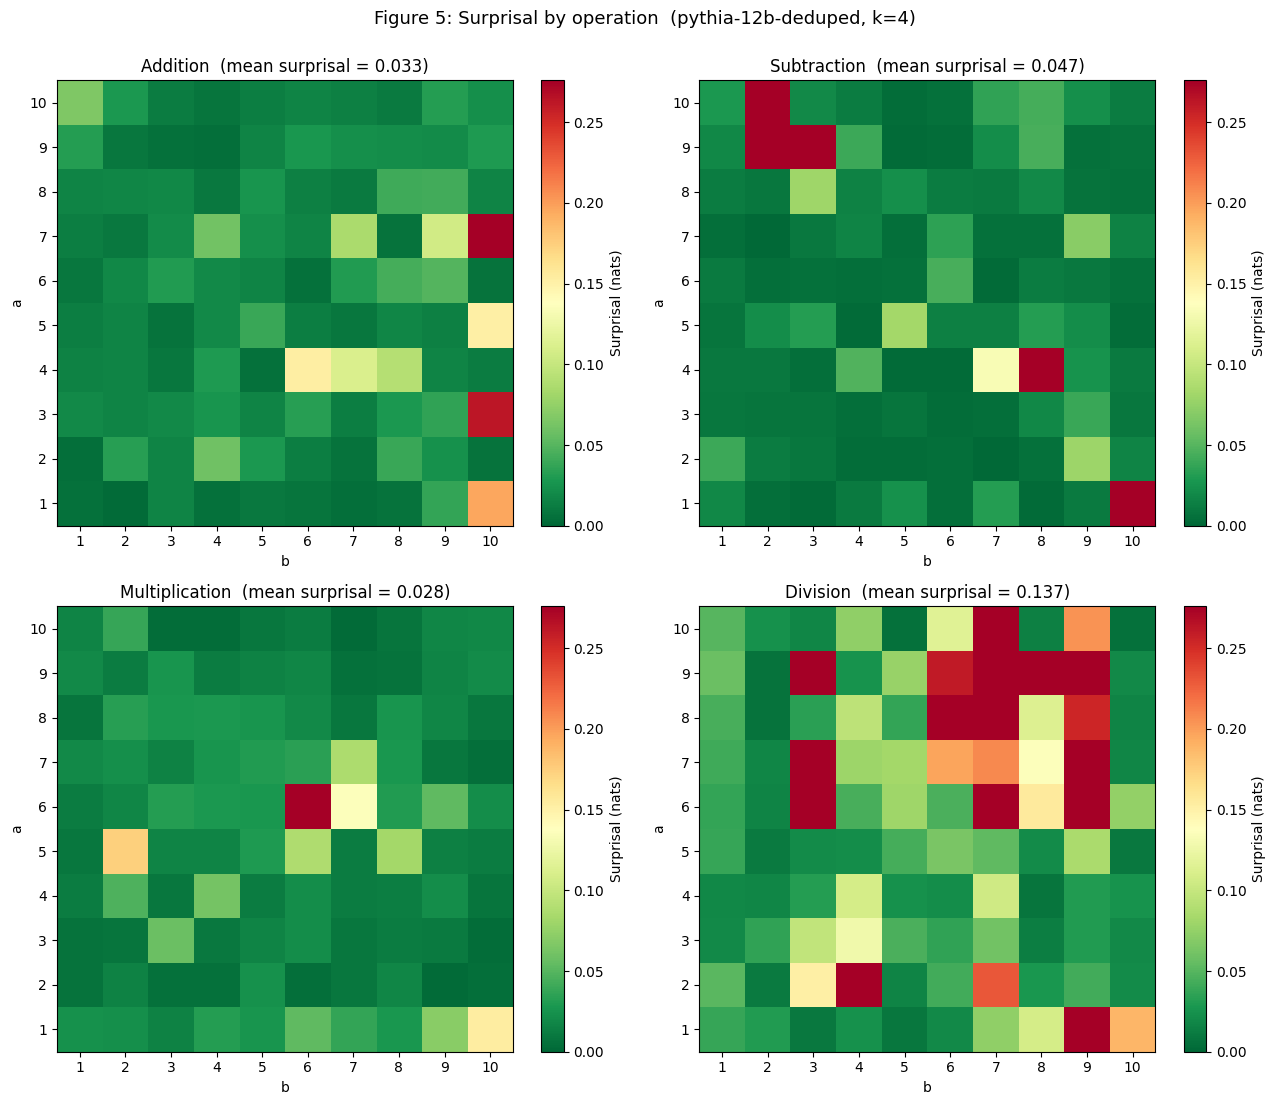

In [23]:
# ── Figure 5: surprisal heatmaps for all four operations ────────────────────
# Axes are the (a, b) grid index (1..10). For - and / the displayed operands are
# (a+b, b) and (a*b, b) respectively, but the cell is still indexed by (a, b) so
# the four panels are directly comparable. A shared colour scale (pooled 95th
# percentile) is used so surprisals are comparable across operations.

pooled = np.concatenate([results[op]["surprisal"].values for op in OPS])
vmax = float(np.quantile(pooled, 0.95))

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, op in zip(axes.ravel(), OPS):
    piv = results[op].pivot(index="a", columns="b", values="surprisal")
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto", origin="lower")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(range(1, 11)); ax.set_yticklabels(range(1, 11))
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()}  (mean surprisal = {results[op]['surprisal'].mean():.3f})")
    plt.colorbar(im, ax=ax, label="Surprisal (nats)")

fig.suptitle(f"Figure 5: Surprisal by operation  ({MODEL_NAME.split('/')[-1]}, k={K_SHOT})", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/four_op_surprisal_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


### Relationship between operations (inverse pairs)

Subtraction is the inverse of addition, and division is the inverse of multiplication — a relationship documented in the cognitive-science literature. If the model has *discovered* these links, performance on a problem and on its inverse should be correlated across the 10×10 grid.

We test this by correlating, cell-by-cell across the 100 problems, the accuracies (and, as a robustness check, the surprisals) of:

- **inverse pairs**: addition↔subtraction and multiplication↔division
- **baseline (non-inverse) pairs**: addition↔multiplication, addition↔division, subtraction↔multiplication, subtraction↔division

If the inverse-pair correlations exceed the average baseline correlation, that is evidence the model represents these operations as linked inverses rather than as four independent tasks.

In [24]:
# ── Cross-operation accuracy correlations ───────────────────────────────────
# Align the 100 per-cell accuracies (and surprisals) across operations by (a,b),
# then test whether INVERSE pairs (+ vs -, * vs /) are more correlated than the
# non-inverse "cross" pairs that serve as a baseline.

acc_wide  = pd.DataFrame({op: results[op].set_index(["a", "b"])["correct"].astype(float) for op in OPS})
surp_wide = pd.DataFrame({op: results[op].set_index(["a", "b"])["surprisal"]            for op in OPS})

acc_corr  = acc_wide.corr()    # Pearson on 0/1 == phi coefficient
surp_corr = surp_wide.corr()

inv_pairs   = [("+", "-"), ("*", "/")]                          # addition~subtraction, mult~division
cross_pairs = [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]  # baseline (non-inverse)

def pair_vals(corr, pairs):
    vals = [corr.loc[i, j] for i, j in pairs]
    return vals, float(np.nanmean(vals))

print("=== ACCURACY correlations across the 100 (a,b) cells ===")
print(acc_corr.round(3).to_string())
if acc_corr.isna().any().any():
    sat = [OP_NAMES[op] for op in OPS if acc_wide[op].std() == 0]
    print(f"  NOTE: NaNs arise where accuracy is saturated (no variance): {sat}")
a_inv, a_inv_m   = pair_vals(acc_corr, inv_pairs)
a_cross, a_cross_m = pair_vals(acc_corr, cross_pairs)
print(f"  inverse pairs : add~sub={acc_corr.loc['+','-']:.3f}, mul~div={acc_corr.loc['*','/']:.3f}  (mean={a_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={a_cross_m:.3f}  values={[round(v,3) for v in a_cross]}")
print(f"  inverse - baseline (accuracy): {a_inv_m - a_cross_m:+.3f}")
print()

print("=== SURPRISAL correlations (robustness: continuous, never saturated) ===")
print(surp_corr.round(3).to_string())
s_inv, s_inv_m     = pair_vals(surp_corr, inv_pairs)
s_cross, s_cross_m = pair_vals(surp_corr, cross_pairs)
print(f"  inverse pairs : add~sub={surp_corr.loc['+','-']:.3f}, mul~div={surp_corr.loc['*','/']:.3f}  (mean={s_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={s_cross_m:.3f}  values={[round(v,3) for v in s_cross]}")
print(f"  inverse - baseline (surprisal): {s_inv_m - s_cross_m:+.3f}")
print()
print("Interpretation: a positive 'inverse - baseline' gap is the signature of the model")
print("linking each operation to its inverse (higher than chance cross-operation transfer).")


=== ACCURACY correlations across the 100 (a,b) cells ===
    +   -   *    /
+ NaN NaN NaN  NaN
- NaN NaN NaN  NaN
* NaN NaN NaN  NaN
/ NaN NaN NaN  1.0
  NOTE: NaNs arise where accuracy is saturated (no variance): ['addition', 'subtraction', 'multiplication']
  inverse pairs : add~sub=nan, mul~div=nan  (mean=nan)
  baseline (cross pairs): mean=nan  values=[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
  inverse - baseline (accuracy): +nan

=== SURPRISAL correlations (robustness: continuous, never saturated) ===
       +      -      *      /
+  1.000  0.137  0.020 -0.031
-  0.137  1.000  0.096  0.002
*  0.020  0.096  1.000 -0.030
/ -0.031  0.002 -0.030  1.000
  inverse pairs : add~sub=0.137, mul~div=-0.030  (mean=0.053)
  baseline (cross pairs): mean=0.022  values=[np.float64(0.02), np.float64(-0.031), np.float64(0.096), np.float64(0.002)]
  inverse - baseline (surprisal): +0.032

Interpretation: a positive 'inverse - baseline' gap is the signature of the model
lin

---
# Part 2b: Zero-shot, direct operands (strictly 1–10)

Re-run of Part 2 with two changes:

1. **Zero-shot** — no k-shot demonstrations (`k = 0`); each problem is scored from the bare prompt `x op y =`.
2. **Operands strictly 1–10** (no inverse framing):
   - addition: `a + b`
   - subtraction: `a − b`  — answers may be **0 or negative** (−9…9)
   - multiplication: `a × b`
   - division: `a / b`, restricted to **exact (a mod b = 0)** cells so answers stay integer with both operands in 1–10. This yields fewer than 100 division cells; the other three operations keep all 100.

Everything else (problem size = largest number in the equation; Pile frequency of the exact `x op y`; Pearson correlations) matches Part 2. Cross-operation correlations involving division use only the exact-division cells.

This section reuses `freq_expr`, the eval functions, and `model`/`tokenizer` loaded above, and writes to `results_direct` / `summary_table_direct` (Part 2's `results` is left untouched for comparison).

In [25]:
# ── Problem generation: direct operands strictly in 1..10 (no inverse framing) ──
def op_cell_direct(op, a, b):
    if op == "+": return a, b, a + b
    if op == "-": return a, b, a - b      # answer may be 0 or negative
    if op == "*": return a, b, a * b
    if op == "/": return a, b, a // b     # only used when a % b == 0
    raise ValueError(f"Unknown op: {op!r}")

def gen_problems_direct(op):
    sym = OP_SYMBOL[op]
    rows = []
    for a, b in itertools.product(range(1, 11), range(1, 11)):
        if op == "/" and a % b != 0:
            continue   # keep operands in 1..10 -> only exact divisions stay integer
        x, y, ans = op_cell_direct(op, a, b)
        rows.append({
            "op": op, "a": a, "b": b, "x": x, "y": y, "answer": ans,
            "prompt": f"{x} {sym} {y} =",
            "target": str(ans),
            "problem_size": max(abs(x), abs(y), abs(ans)),
            "freq": freq_expr.get((op, a, b), 0),
        })
    return pd.DataFrame(rows)

problem_dfs_direct = {op: gen_problems_direct(op) for op in OPS}

print("Direct operands strictly in 1..10 (zero-shot variant). Cells per operation:")
for op in OPS:
    d = problem_dfs_direct[op]
    print(f"  {OP_NAMES[op]:14s}: {len(d):3d} cells   e.g. {d.iloc[0]['prompt']} {d.iloc[0]['target']}")
print()
print("Note: subtraction answers can be 0 or negative; division keeps only exact (a % b == 0)")
print(f"      cells so operands stay in 1..10 with integer answers ({len(problem_dfs_direct['/'])} division cells).")


Direct operands strictly in 1..10 (zero-shot variant). Cells per operation:
  addition      : 100 cells   e.g. 1 + 1 = 2
  subtraction   : 100 cells   e.g. 1 - 1 = 0
  multiplication: 100 cells   e.g. 1 * 1 = 1
  division      :  27 cells   e.g. 1 / 1 = 1

Note: subtraction answers can be 0 or negative; division keeps only exact (a % b == 0)
      cells so operands stay in 1..10 with integer answers (27 division cells).


In [26]:
# ── Evaluate all four operations: ZERO-SHOT (no demonstrations) ──────────────
# The raw prompt "x op y =" is scored directly (prompt_col="prompt", no prefix).

results_direct = {}
for op in OPS:
    df = problem_dfs_direct[op]
    dfk = eval_logprob(model, tokenizer, df,
                       batch_size=BATCH_SIZE_LOGPROB, prompt_col="prompt")
    dfk = eval_accuracy(model, tokenizer, dfk,
                        batch_size=BATCH_SIZE_ACCURACY, prompt_col="prompt")
    dfk["model"]  = MODEL_NAME
    dfk["k_shot"] = 0
    results_direct[op] = dfk
    print(f"{OP_NAMES[op]:14s} | n={len(dfk):3d} | acc = {dfk['correct'].mean():.3f} | "
          f"mean surprisal = {dfk['surprisal'].mean():.3f}")


addition       | n=100 | acc = 0.010 | mean surprisal = 5.401


subtraction    | n=100 | acc = 0.190 | mean surprisal = 3.617


multiplication | n=100 | acc = 0.380 | mean surprisal = 2.353


division       | n= 27 | acc = 0.407 | mean surprisal = 1.949


In [27]:
# ── Per-operation summary table (zero-shot, direct operands) ────────────────
rows = []
for op in OPS:
    d = results_direct[op]
    surp = d["surprisal"].values
    acc  = d["correct"].astype(float).values
    size = d["problem_size"].values.astype(float)
    logf = np.log1p(d["freq"].values.astype(float))
    r_size, p_size = safe_pearson(surp, size)
    r_freq, p_freq = safe_pearson(surp, logf)
    rows.append({
        "operation":   OP_NAMES[op],
        "n":           len(d),
        "mean_acc":    acc.mean(),
        "std_acc":     acc.std(),
        "r_surp_size": r_size,
        "p_size":      p_size,
        "r_surp_freq": r_freq,
        "p_freq":      p_freq,
    })

summary_table_direct = pd.DataFrame(rows).set_index("operation")

print("Per-operation summary  (ZERO-SHOT, direct operands 1..10)")
print("  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)")
print("  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')")
print()
print(summary_table_direct.to_string(float_format=lambda v: f"{v: .4g}"))
print()
print("Sentence-ready mean accuracy by operation (zero-shot, direct):")
for op in OPS:
    a = results_direct[op]["correct"].astype(float)
    print(f"  {OP_NAMES[op]:14s}: {a.mean():.3f}  (std {a.std():.3f}, n {len(a)})")

summary_table_direct


Per-operation summary  (ZERO-SHOT, direct operands 1..10)
  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)
  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')

                  n  mean_acc  std_acc  r_surp_size     p_size  r_surp_freq     p_freq
operation                                                                             
addition        100      0.01   0.0995       0.6608  7.383e-14      -0.7466  4.818e-19
subtraction     100      0.19   0.3923       0.1646     0.1018      -0.6181  7.294e-12
multiplication  100      0.38   0.4854       0.3605  0.0002293      -0.4564  1.825e-06
division         27    0.4074   0.4914       0.0896     0.6567       0.1783     0.3736

Sentence-ready mean accuracy by operation (zero-shot, direct):
  addition      : 0.010  (std 0.100, n 100)
  subtraction   : 0.190  (std 0.394, n 100)
  multiplication: 0.380  (std 0.488, n 100)
  division      : 0.407  (std 0.501, n 27)


,n,mean_acc,std_acc,r_surp_size,p_size,r_surp_freq,p_freq
operation,,,,,,,
addition,100,0.010000,0.099499,0.660788,7.382793e-14,-0.746599,4.817858e-19
subtraction,100,0.190000,0.392301,0.164557,1.018271e-01,-0.618129,7.293554e-12
multiplication,100,0.380000,0.485386,0.360495,2.293189e-04,-0.456356,1.824933e-06
division,27,0.407407,0.491352,0.089601,6.567219e-01,0.178297,3.735838e-01


### Figure 5 (zero-shot, direct operands): surprisal heatmaps

Surprisal grid for all four operations under zero-shot prompting with operands strictly in 1–10. Division shows only exact-division cells (others blank).

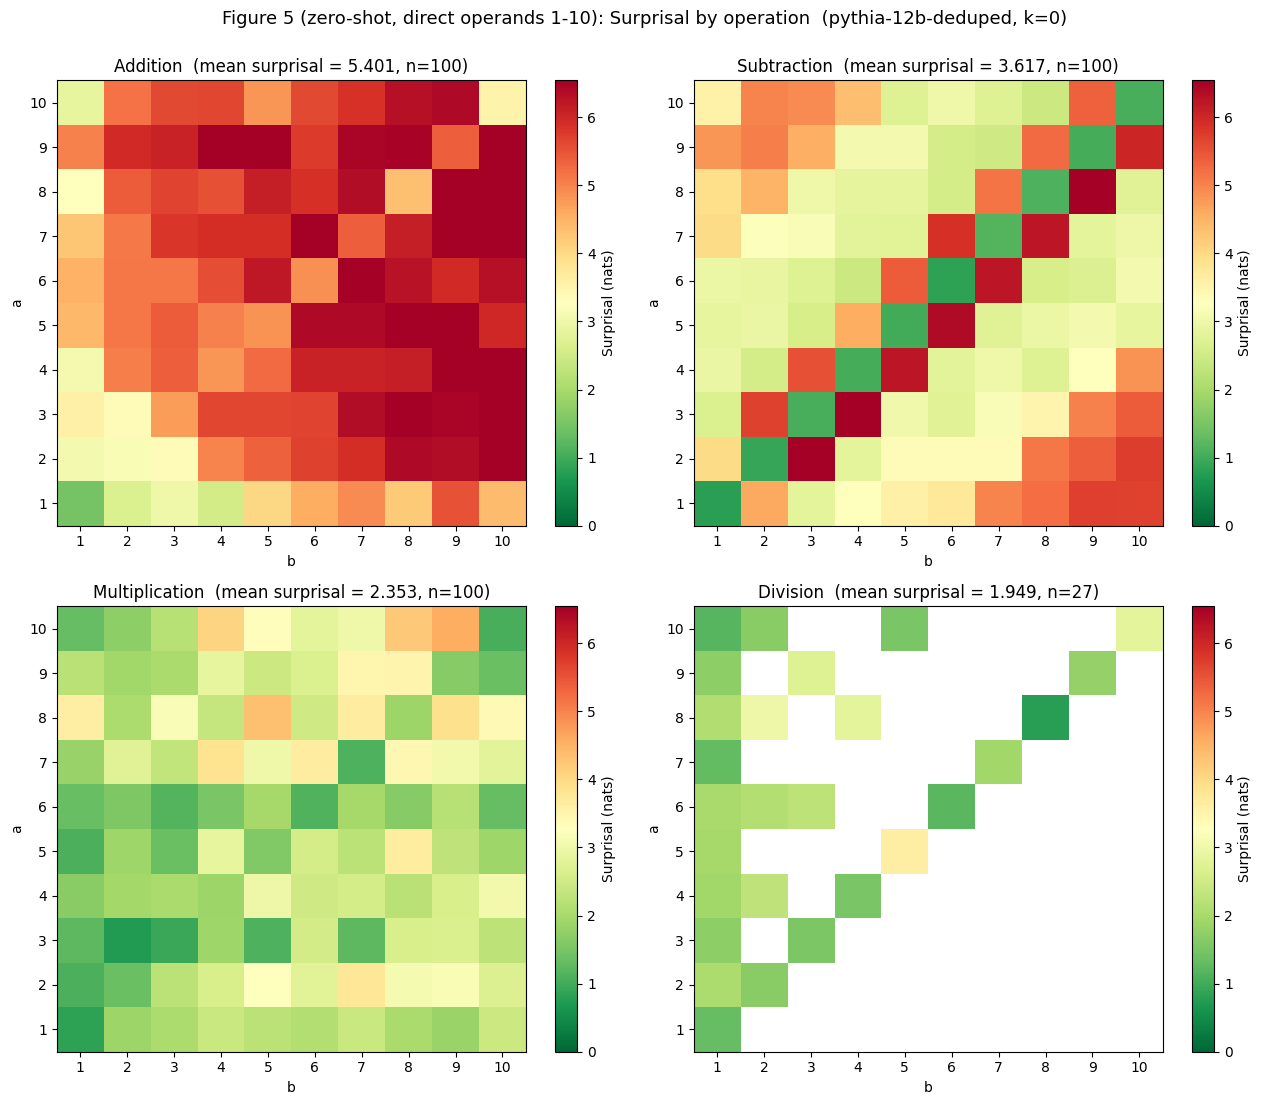

In [28]:
# ── Figure 5 (zero-shot, direct): surprisal heatmaps ────────────────────────
# Axes are operands a, b in 1..10. For division, non-exact cells are excluded and
# render as blank.

pooled_d = np.concatenate([results_direct[op]["surprisal"].values for op in OPS])
vmax_d = float(np.quantile(pooled_d, 0.95))

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, op in zip(axes.ravel(), OPS):
    piv = (results_direct[op]
           .pivot(index="a", columns="b", values="surprisal")
           .reindex(index=range(1, 11), columns=range(1, 11)))
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax_d, aspect="auto", origin="lower")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(range(1, 11)); ax.set_yticklabels(range(1, 11))
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()}  (mean surprisal = {results_direct[op]['surprisal'].mean():.3f}, "
                 f"n={len(results_direct[op])})")
    plt.colorbar(im, ax=ax, label="Surprisal (nats)")

fig.suptitle(f"Figure 5 (zero-shot, direct operands 1-10): Surprisal by operation  ({MODEL_NAME.split('/')[-1]}, k=0)",
             y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/four_op_surprisal_heatmaps_zeroshot.png", dpi=150, bbox_inches="tight")
plt.show()


### Relationship between operations (zero-shot, direct operands)

Same inverse-pair vs. baseline test as before, but on the zero-shot, direct-operand results. Pairs involving division use only the exact-division cells the two operations share.

In [29]:
# ── Cross-operation correlations (zero-shot, direct operands) ───────────────
# Division has fewer cells (exact divisions only), so any pair involving division
# is computed on the cells both operations share (pandas corr = pairwise-complete).

acc_wide_d  = pd.DataFrame({op: results_direct[op].set_index(["a", "b"])["correct"].astype(float) for op in OPS})
surp_wide_d = pd.DataFrame({op: results_direct[op].set_index(["a", "b"])["surprisal"]            for op in OPS})
acc_corr_d  = acc_wide_d.corr()
surp_corr_d = surp_wide_d.corr()

inv_pairs   = [("+", "-"), ("*", "/")]
cross_pairs = [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]

def npair(wide, i, j):
    return int(wide[[i, j]].dropna().shape[0])

print("=== ACCURACY correlations (zero-shot, direct; pairwise-complete) ===")
print(acc_corr_d.round(3).to_string())
if acc_corr_d.isna().any().any():
    sat = [OP_NAMES[op] for op in OPS if acc_wide_d[op].dropna().std() == 0]
    print(f"  NOTE: NaNs where accuracy is saturated (no variance): {sat}")
a_inv, a_inv_m     = pair_vals(acc_corr_d, inv_pairs)
a_cross, a_cross_m = pair_vals(acc_corr_d, cross_pairs)
print(f"  inverse pairs : add~sub={acc_corr_d.loc['+','-']:.3f} (n={npair(acc_wide_d,'+','-')}), "
      f"mul~div={acc_corr_d.loc['*','/']:.3f} (n={npair(acc_wide_d,'*','/')})  (mean={a_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={a_cross_m:.3f}  values={[round(v,3) for v in a_cross]}")
print(f"  inverse - baseline (accuracy): {a_inv_m - a_cross_m:+.3f}")
print()

print("=== SURPRISAL correlations (zero-shot, direct) ===")
print(surp_corr_d.round(3).to_string())
s_inv, s_inv_m     = pair_vals(surp_corr_d, inv_pairs)
s_cross, s_cross_m = pair_vals(surp_corr_d, cross_pairs)
print(f"  inverse pairs : add~sub={surp_corr_d.loc['+','-']:.3f} (n={npair(surp_wide_d,'+','-')}), "
      f"mul~div={surp_corr_d.loc['*','/']:.3f} (n={npair(surp_wide_d,'*','/')})  (mean={s_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={s_cross_m:.3f}  values={[round(v,3) for v in s_cross]}")
print(f"  inverse - baseline (surprisal): {s_inv_m - s_cross_m:+.3f}")


=== ACCURACY correlations (zero-shot, direct; pairwise-complete) ===
       +      -      *      /
+  1.000  0.208  0.128 -0.163
-  0.208  1.000  0.356 -0.012
*  0.128  0.356  1.000 -0.187
/ -0.163 -0.012 -0.187  1.000
  inverse pairs : add~sub=0.208 (n=100), mul~div=-0.187 (n=27)  (mean=0.010)
  baseline (cross pairs): mean=0.078  values=[np.float64(0.128), np.float64(-0.163), np.float64(0.356), np.float64(-0.012)]
  inverse - baseline (accuracy): -0.067

=== SURPRISAL correlations (zero-shot, direct) ===
       +      -      *      /
+  1.000  0.230  0.470  0.341
-  0.230  1.000  0.277  0.152
*  0.470  0.277  1.000  0.103
/  0.341  0.152  0.103  1.000
  inverse pairs : add~sub=0.230 (n=100), mul~div=0.103 (n=27)  (mean=0.167)
  baseline (cross pairs): mean=0.310  values=[np.float64(0.47), np.float64(0.341), np.float64(0.277), np.float64(0.152)]
  inverse - baseline (surprisal): -0.143


---
# Part 2c: Zero-shot, inverse framing

Combines the zero-shot setting of Part 2b with the inverse framing of Part 2:

- **Zero-shot** (`k = 0`): each problem is scored from the bare prompt `x op y =`, no demonstrations.
- **Inverse framing** (same as Part 2, reuses `problem_dfs`):
  - addition: `a + b = (a+b)`
  - subtraction: `(a+b) − b = a`
  - multiplication: `a × b = (a·b)`
  - division: `(a·b) ÷ b = a`

All four operations keep the full 100-cell grid with **positive integer** answers, so there are no negative-answer / reduced-cell artifacts here. Surprisal is the total `−log P(answer | prompt)` set in `eval_logprob`. Results go to `results_inv_zs` / `summary_table_inv_zs`; Parts 2 and 2b are left untouched.

In [30]:
# ── Evaluate all four operations: ZERO-SHOT, inverse framing ─────────────
# Reuses the inverse-framed problems from Part 2 (problem_dfs); k=0 (raw prompt, no prefix).
results_inv_zs = {}
for op in OPS:
    dfk = eval_logprob(model, tokenizer, problem_dfs[op],
                       batch_size=BATCH_SIZE_LOGPROB, prompt_col="prompt")
    dfk = eval_accuracy(model, tokenizer, dfk,
                        batch_size=BATCH_SIZE_ACCURACY, prompt_col="prompt")
    dfk["model"]  = MODEL_NAME
    dfk["k_shot"] = 0
    results_inv_zs[op] = dfk
    print(f"{OP_NAMES[op]:14s} | n={len(dfk):3d} | acc = {dfk['correct'].mean():.3f} | "
          f"mean surprisal = {dfk['surprisal'].mean():.3f}")


addition       | n=100 | acc = 0.010 | mean surprisal = 5.401


subtraction    | n=100 | acc = 0.000 | mean surprisal = 4.133


multiplication | n=100 | acc = 0.380 | mean surprisal = 2.353


division       | n=100 | acc = 0.120 | mean surprisal = 3.019


In [31]:
# ── Per-operation summary table (zero-shot, inverse framing) ────────────
rows = []
for op in OPS:
    d = results_inv_zs[op]
    surp = d["surprisal"].values
    acc  = d["correct"].astype(float).values
    size = d["problem_size"].values.astype(float)
    logf = np.log1p(d["freq"].values.astype(float))
    r_size, p_size = safe_pearson(surp, size)
    r_freq, p_freq = safe_pearson(surp, logf)
    rows.append({
        "operation":   OP_NAMES[op],
        "n":           len(d),
        "mean_acc":    acc.mean(),
        "std_acc":     acc.std(),
        "r_surp_size": r_size,
        "p_size":      p_size,
        "r_surp_freq": r_freq,
        "p_freq":      p_freq,
    })

summary_table_inv_zs = pd.DataFrame(rows).set_index("operation")

print("Per-operation summary  (ZERO-SHOT, inverse framing)")
print("  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)")
print("  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')")
print()
print(summary_table_inv_zs.to_string(float_format=lambda v: f"{v: .4g}"))
print()
print("Sentence-ready mean accuracy by operation (zero-shot, inverse):")
for op in OPS:
    a = results_inv_zs[op]["correct"].astype(float)
    print(f"  {OP_NAMES[op]:14s}: {a.mean():.3f}  (std {a.std():.3f}, n {len(a)})")

summary_table_inv_zs


Per-operation summary  (ZERO-SHOT, inverse framing)
  r_surp_size = Pearson r(surprisal, problem size = largest number in eqn)
  r_surp_freq = Pearson r(surprisal, log1p Pile frequency of 'x op y')

                  n  mean_acc  std_acc  r_surp_size     p_size  r_surp_freq     p_freq
operation                                                                             
addition        100      0.01   0.0995       0.6608  7.383e-14      -0.7466  4.818e-19
subtraction     100         0        0       0.4109  2.175e-05      -0.5224   2.48e-08
multiplication  100      0.38   0.4854       0.3605  0.0002293      -0.4564  1.825e-06
division        100      0.12    0.325       0.6685  2.984e-14       -0.498  1.349e-07

Sentence-ready mean accuracy by operation (zero-shot, inverse):
  addition      : 0.010  (std 0.100, n 100)
  subtraction   : 0.000  (std 0.000, n 100)
  multiplication: 0.380  (std 0.488, n 100)
  division      : 0.120  (std 0.327, n 100)


,n,mean_acc,std_acc,r_surp_size,p_size,r_surp_freq,p_freq
operation,,,,,,,
addition,100,0.01,0.099499,0.660788,7.382793e-14,-0.746599,4.817858e-19
subtraction,100,0.00,0.000000,0.410869,2.175121e-05,-0.522396,2.480296e-08
multiplication,100,0.38,0.485386,0.360495,2.293189e-04,-0.456356,1.824933e-06
division,100,0.12,0.324962,0.668457,2.983960e-14,-0.498012,1.348637e-07


### Figure 5 (zero-shot, inverse framing): surprisal heatmaps

Surprisal grid for all four operations under zero-shot prompting with the inverse framing. Axes are the `(a, b)` grid index (1–10); all four panels are full 100-cell grids on a shared colour scale.

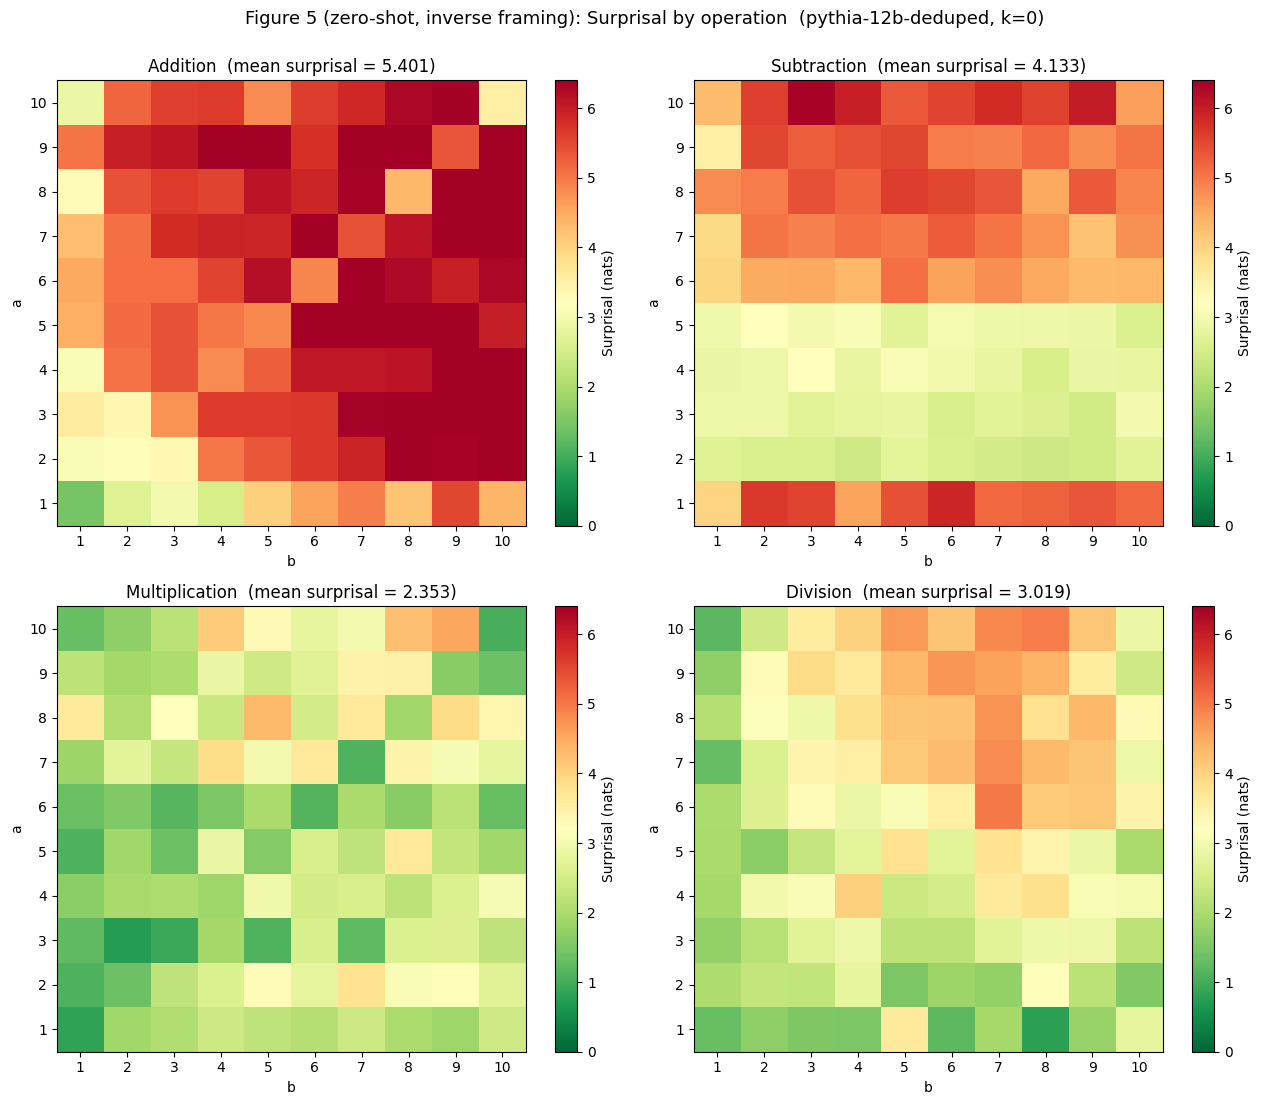

In [32]:
# ── Figure 5 (zero-shot, inverse framing): surprisal heatmaps ──────────
pooled_iz = np.concatenate([results_inv_zs[op]["surprisal"].values for op in OPS])
vmax_iz = float(np.quantile(pooled_iz, 0.95))

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, op in zip(axes.ravel(), OPS):
    piv = results_inv_zs[op].pivot(index="a", columns="b", values="surprisal")
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax_iz, aspect="auto", origin="lower")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(range(1, 11)); ax.set_yticklabels(range(1, 11))
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()}  (mean surprisal = {results_inv_zs[op]['surprisal'].mean():.3f})")
    plt.colorbar(im, ax=ax, label="Surprisal (nats)")

fig.suptitle(f"Figure 5 (zero-shot, inverse framing): Surprisal by operation  ({MODEL_NAME.split('/')[-1]}, k=0)",
             y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/four_op_surprisal_heatmaps_inverse_zeroshot.png", dpi=150, bbox_inches="tight")
plt.show()


### Relationship between operations (zero-shot, inverse framing)

Same inverse-pair vs. baseline test as Part 2, but zero-shot. All operations have full 100-cell grids, so every pair uses n = 100.

In [33]:
# ── Cross-operation correlations (zero-shot, inverse framing) ──────────
acc_wide_iz  = pd.DataFrame({op: results_inv_zs[op].set_index(["a", "b"])["correct"].astype(float) for op in OPS})
surp_wide_iz = pd.DataFrame({op: results_inv_zs[op].set_index(["a", "b"])["surprisal"]            for op in OPS})
acc_corr_iz  = acc_wide_iz.corr()
surp_corr_iz = surp_wide_iz.corr()

inv_pairs   = [("+", "-"), ("*", "/")]
cross_pairs = [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]

print("=== ACCURACY correlations across the 100 (a,b) cells (zero-shot, inverse) ===")
print(acc_corr_iz.round(3).to_string())
if acc_corr_iz.isna().any().any():
    sat = [OP_NAMES[op] for op in OPS if acc_wide_iz[op].std() == 0]
    print(f"  NOTE: NaNs where accuracy is saturated (no variance): {sat}")
a_inv, a_inv_m     = pair_vals(acc_corr_iz, inv_pairs)
a_cross, a_cross_m = pair_vals(acc_corr_iz, cross_pairs)
print(f"  inverse pairs : add~sub={acc_corr_iz.loc['+','-']:.3f}, mul~div={acc_corr_iz.loc['*','/']:.3f}  (mean={a_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={a_cross_m:.3f}  values={[round(v,3) for v in a_cross]}")
print(f"  inverse - baseline (accuracy): {a_inv_m - a_cross_m:+.3f}")
print()

print("=== SURPRISAL correlations (zero-shot, inverse) ===")
print(surp_corr_iz.round(3).to_string())
s_inv, s_inv_m     = pair_vals(surp_corr_iz, inv_pairs)
s_cross, s_cross_m = pair_vals(surp_corr_iz, cross_pairs)
print(f"  inverse pairs : add~sub={surp_corr_iz.loc['+','-']:.3f}, mul~div={surp_corr_iz.loc['*','/']:.3f}  (mean={s_inv_m:.3f})")
print(f"  baseline (cross pairs): mean={s_cross_m:.3f}  values={[round(v,3) for v in s_cross]}")
print(f"  inverse - baseline (surprisal): {s_inv_m - s_cross_m:+.3f}")


=== ACCURACY correlations across the 100 (a,b) cells (zero-shot, inverse) ===
       +   -      *      /
+  1.000 NaN  0.128 -0.037
-    NaN NaN    NaN    NaN
*  0.128 NaN  1.000  0.028
/ -0.037 NaN  0.028  1.000
  NOTE: NaNs where accuracy is saturated (no variance): ['subtraction']
  inverse pairs : add~sub=nan, mul~div=0.028  (mean=0.028)
  baseline (cross pairs): mean=0.046  values=[np.float64(0.128), np.float64(-0.037), np.float64(nan), np.float64(nan)]
  inverse - baseline (accuracy): -0.018

=== SURPRISAL correlations (zero-shot, inverse) ===
       +      -      *      /
+  1.000  0.021  0.470  0.527
-  0.021  1.000  0.257  0.395
*  0.470  0.257  1.000  0.394
/  0.527  0.395  0.394  1.000
  inverse pairs : add~sub=0.021, mul~div=0.394  (mean=0.208)
  baseline (cross pairs): mean=0.412  values=[np.float64(0.47), np.float64(0.527), np.float64(0.257), np.float64(0.395)]
  inverse - baseline (surprisal): -0.205


### Diagnostic: surprisal vs. answer value (collapse across operations)

Tests whether zero-shot surprisal is essentially a function of the **answer value**, shared across operations. If the four per-operation curves overlap with a knee near 5–6, that explains why subtraction shows a sharp `a=5→6` step (answer = `a`, horizontal rows) while addition shows the *same* threshold as a diagonal gradient (answer = `a+b`).

Pooled mean surprisal by answer value (all four operations), answers 1-12:
         mean  count
answer              
1       3.383     21
2       2.240     23
3       2.556     24
4       2.872     26
5       2.782     26
6       3.750     29
7       4.222     28
8       4.332     31
9       4.230     31
10      4.602     33
11      5.678     10
12      4.732     13

  pooled mean surprisal, answer <= 5 : 2.758
  pooled mean surprisal, answer >= 6 : 4.142


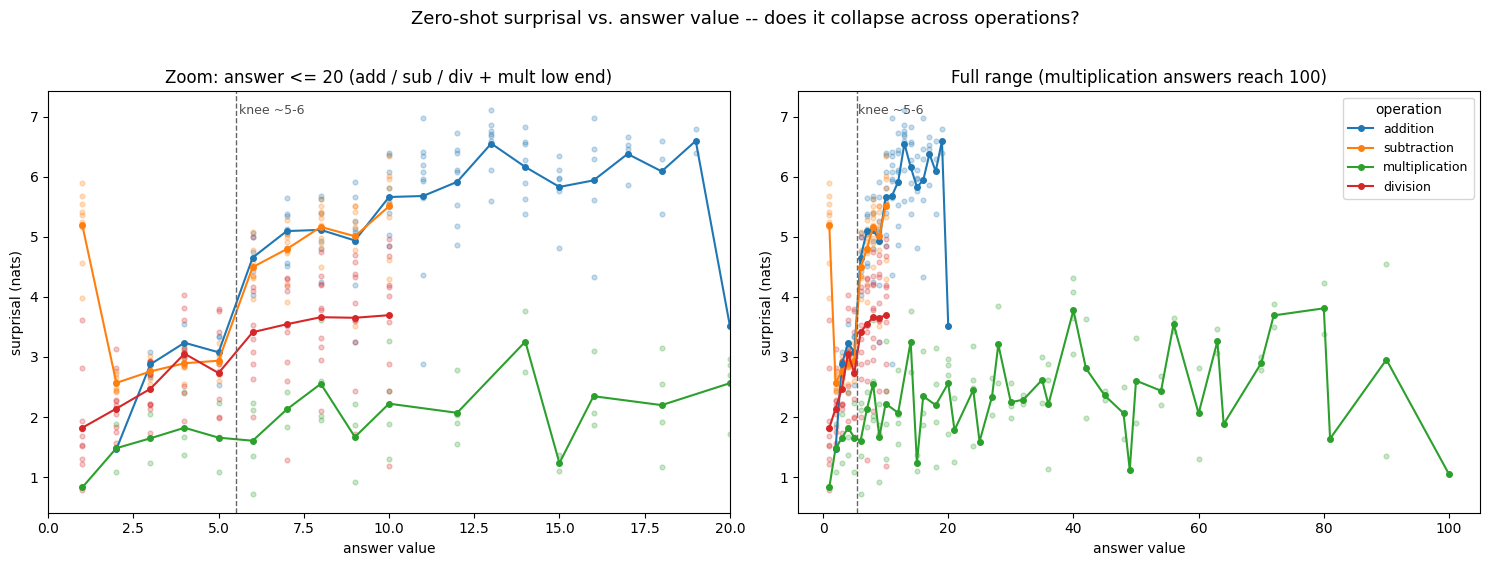

In [34]:
# ── Diagnostic: is zero-shot surprisal just a function of the ANSWER value? ──
# If yes, all four operations (inverse framing) collapse onto ONE
# surprisal-vs-answer curve with a knee near 5-6 -- which is why subtraction
# (answer = a, horizontal rows) shows a sharp 5->6 step while addition
# (answer = a+b, diagonals) shows the same threshold smeared into a gradient.

allcells = pd.concat([results_inv_zs[op][["op", "answer", "surprisal"]] for op in OPS],
                     ignore_index=True)
pooled = allcells.groupby("answer")["surprisal"].agg(["mean", "count"])

print("Pooled mean surprisal by answer value (all four operations), answers 1-12:")
print(pooled.head(12).round(3).to_string())
print()
print(f"  pooled mean surprisal, answer <= 5 : {allcells[allcells['answer'] <= 5]['surprisal'].mean():.3f}")
print(f"  pooled mean surprisal, answer >= 6 : {allcells[allcells['answer'] >= 6]['surprisal'].mean():.3f}")

colors = {"+": "tab:blue", "-": "tab:orange", "*": "tab:green", "/": "tab:red"}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.5))
for ax in (axL, axR):
    for op in OPS:                                    # individual cells (faint)
        d = results_inv_zs[op]
        ax.scatter(d["answer"], d["surprisal"], s=12, alpha=0.25, color=colors[op])
    for op in OPS:                                    # per-op mean curve
        g = results_inv_zs[op].groupby("answer")["surprisal"].mean()
        ax.plot(g.index, g.values, marker="o", ms=4, color=colors[op], label=OP_NAMES[op])
    ax.axvline(5.5, ls="--", color="0.4", lw=1)
    ax.text(5.6, 0.97, "knee ~5-6", transform=ax.get_xaxis_transform(),
            fontsize=9, va="top", color="0.3")
    ax.set_xlabel("answer value"); ax.set_ylabel("surprisal (nats)")
axL.set_xlim(0, 20)
axL.set_title("Zoom: answer <= 20 (add / sub / div + mult low end)")
axR.set_title("Full range (multiplication answers reach 100)")
axR.legend(title="operation", fontsize=9)
fig.suptitle("Zero-shot surprisal vs. answer value -- does it collapse across operations?",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/zeroshot_surprisal_vs_answer.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Part 3: Fact-triple framing — accuracy-based inverse correlation

Goal: make the **inverse pairs** (addition~subtraction, multiplication~division) correlate more than the **cross pairs** (the other four combinations).

Why the earlier surprisal analysis was weak: in the inverse framing the scored answer of the inverse op is always small (`-`→`a`, `/`→`a`), so its *surprisal* is dominated by the answer-magnitude prior, not by the difficulty of the fact (the hard number `c` sits in the prompt). Surprisal can't capture an inverse pair symmetrically.

Design used here:
- **Measure accuracy**, not surprisal — it is symmetric across the two directions of a fact `(a, b, c)`: `a×b=?`→`c` and `c÷b=?`→`a` both test the same fact.
- **Run where accuracy has variance** (12B saturates `+`/`-`): (3a) a **model-size sweep** over Pythia 70M–1.4B on the single-digit grid; (3b) **2-digit operands** at 12B.
- **Inverse fact-triple framing** (same as Part 2): `+: a+b=c`, `-: c-b=a`, `*: a*b=c`, `/: c/b=a`.
- **Partial correlations** controlling for operand magnitude (`a, b, a*b`): the cross-pair baseline is mostly "big operands are hard for everything", so partialling it out sharpens inverse > cross.

In [35]:
# ── Part 3 framework: fact-triple problems + accuracy-based inverse analysis ──
import gc

def gen_fact_problems(op, pairs):
    # Build fact-triple problems for `op` over explicit (a, b) pairs (inverse framing via op_cell).
    sym = OP_SYMBOL[op]
    rows = []
    for a, b in pairs:
        x, y, ans = op_cell(op, a, b)
        rows.append({"op": op, "a": a, "b": b, "x": x, "y": y, "answer": ans,
                     "prompt": f"{x} {sym} {y} =", "target": str(ans),
                     "problem_size": max(abs(x), abs(y), abs(ans))})
    return pd.DataFrame(rows)

def kshot_fact(op, pool_pairs, k=K_SHOT, seed=KSHOT_SEED):
    # Fixed k-shot demo string for `op`, sampled from pool_pairs.
    if k == 0:
        return ""
    rng = random.Random(seed)
    pp = list(pool_pairs); rng.shuffle(pp)
    sym = OP_SYMBOL[op]
    lines = []
    for a, b in pp[:k]:
        x, y, ans = op_cell(op, a, b)
        lines.append(f"{x} {sym} {y} = {ans}")
    return "\n".join(lines)

def eval_ops_accuracy(mdl, tok, pairs, k=K_SHOT, seed=KSHOT_SEED):
    # Accuracy of all four operations on the fact grid defined by `pairs`.
    res = {}
    for op in OPS:
        df = gen_fact_problems(op, pairs)
        df = apply_kshot_prefix(df, kshot_fact(op, pairs, k=k, seed=seed))
        df = eval_accuracy(mdl, tok, df, batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
        res[op] = df
    return res

def _residualize(v, Z):
    beta, *_ = np.linalg.lstsq(Z, v, rcond=None)
    return v - Z @ beta

def inverse_vs_cross(res):
    # Inverse-pair vs cross-pair accuracy correlations, raw and partial.
    # Partial controls for operand magnitude (a, b, a*b).
    acc = pd.DataFrame({op: res[op].set_index(["a", "b"])["correct"].astype(float) for op in OPS})
    idx = acc.index.to_frame(index=False).astype(float)
    cov_all = np.column_stack([idx["a"].values, idx["b"].values, (idx["a"] * idx["b"]).values])

    def corr_pair(i, j, partial):
        sub = acc[[i, j]].dropna()
        if len(sub) < 5 or sub[i].std() == 0 or sub[j].std() == 0:
            return np.nan
        xi, yj = sub[i].values, sub[j].values
        if partial:
            rows = acc.index.get_indexer(sub.index)
            Z = np.column_stack([np.ones(len(sub)), cov_all[rows]])
            xi, yj = _residualize(xi, Z), _residualize(yj, Z)
            if np.std(xi) == 0 or np.std(yj) == 0:
                return np.nan
        return safe_pearson(xi, yj)[0]

    out = {}
    for partial in (False, True):
        tag = "partial" if partial else "raw"
        inv   = [corr_pair("+", "-", partial), corr_pair("*", "/", partial)]
        cross = [corr_pair(a, b, partial) for a, b in [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]]
        out[f"add_sub_{tag}"]      = inv[0]
        out[f"mul_div_{tag}"]      = inv[1]
        out[f"inverse_mean_{tag}"] = float(np.nanmean(inv))
        out[f"cross_mean_{tag}"]   = float(np.nanmean(cross))
        out[f"gap_{tag}"]          = float(np.nanmean(inv) - np.nanmean(cross))
    return out, acc

print("Part 3 framework ready: gen_fact_problems, kshot_fact, eval_ops_accuracy, inverse_vs_cross")

Part 3 framework ready: gen_fact_problems, kshot_fact, eval_ops_accuracy, inverse_vs_cross


## Part 3a: Model-size sweep (single-digit fact grid)

For each Pythia size in `PYTHIA_MODELS`, evaluate 4-op accuracy on the single-digit fact grid (`a, b in 1..10`) and compute the inverse-pair vs cross-pair accuracy correlation. If the inverse > cross gap grows with scale, that is evidence the model increasingly represents operations as linked inverses. Smaller models also avoid the saturation that makes the gap undefined at 12B.

In [36]:
# ── Part 3a: sweep over Pythia sizes (single-digit fact grid) ────────────
# Covers the full Pythia-deduped suite (70M..12B). The 12B is already loaded as
# `model`/`tokenizer`, so we reuse it rather than load a second copy.
# Memory: the resident 12B (~24GB fp16) plus one swept model at a time -> peak is
# during 6.9B (~24+14GB). If you OOM, run this before loading the 12B, or trim
# the largest entries from PYTHIA_MODELS.
sweep_pairs = list(itertools.product(range(1, 11), range(1, 11)))   # 100 single-digit cells
sweep_rows, sweep_acc_by_model = [], {}

for name in PYTHIA_MODELS:
    reuse = (name == MODEL_NAME) and ("model" in globals()) and ("tokenizer" in globals())
    if reuse:
        mdl_s, tok_s = model, tokenizer        # already loaded; do not double-load or free
        print(f"Reusing already-loaded {name}")
    else:
        tok_s, mdl_s = load_model(name)
    res = eval_ops_accuracy(mdl_s, tok_s, sweep_pairs, k=K_SHOT)
    metrics, accw = inverse_vs_cross(res)
    metrics["model"]    = name.split("/")[-1]
    metrics["n_params"] = sum(p.numel() for p in mdl_s.parameters())
    metrics["mean_acc"] = float(np.mean([res[op]["correct"].mean() for op in OPS]))
    sweep_rows.append(metrics)
    sweep_acc_by_model[name] = accw
    del res
    if not reuse:
        del mdl_s, tok_s
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep_rows).set_index("model")
cols = ["n_params", "mean_acc", "add_sub_raw", "mul_div_raw", "inverse_mean_raw",
        "cross_mean_raw", "gap_raw", "inverse_mean_partial", "cross_mean_partial", "gap_partial"]
print("Inverse-pair vs cross-pair accuracy correlation by model size:")
print(sweep_df[cols].to_string(float_format=lambda v: f"{v: .3g}"))
sweep_df[cols]


Loading EleutherAI/pythia-70m-deduped...
  Loaded: 70M params on cuda:0


Loading EleutherAI/pythia-160m-deduped...
  Loaded: 162M params on cuda:0


Loading EleutherAI/pythia-410m-deduped...
  Loaded: 405M params on cuda:0


Loading EleutherAI/pythia-1b-deduped...
  Loaded: 1012M params on cuda:0


Loading EleutherAI/pythia-1.4b-deduped...


...

Loading checkpoint shards: 100%|██████████| 2/2 [02:16<00:00, 68.22s/it]


  Loaded: 6857M params on cuda:0


Reusing already-loaded EleutherAI/pythia-12b-deduped


Inverse-pair vs cross-pair accuracy correlation by model size:
                        n_params  mean_acc  add_sub_raw  mul_div_raw  inverse_mean_raw  cross_mean_raw  gap_raw  inverse_mean_partial  cross_mean_partial  gap_partial
model                                                                                                                                                                 
pythia-70m-deduped      70426624    0.0575          NaN       0.0882            0.0882           0.117  -0.0286                0.0993              0.0668       0.0325
pythia-160m-deduped    162322944    0.0675          NaN       0.0363            0.0363          0.0493  -0.0131                0.0716              0.0671      0.00444
pythia-410m-deduped    405334016      0.21          NaN        0.378             0.378          0.0655    0.312                 0.348             -0.0649        0.413
pythia-1b-deduped     1011781632     0.422        0.214        0.314             0.264           0.177

,n_params,mean_acc,add_sub_raw,mul_div_raw,inverse_mean_raw,cross_mean_raw,gap_raw,inverse_mean_partial,cross_mean_partial,gap_partial
model,,,,,,,,,,
pythia-70m-deduped,70426624,0.0575,NaN,0.088181,0.088181,0.116740,-0.028559,0.099300,0.066821,0.032479
pythia-160m-deduped,162322944,0.0675,NaN,0.036282,0.036282,0.049343,-0.013062,0.071573,0.067131,0.004442
pythia-410m-deduped,405334016,0.2100,NaN,0.377708,0.377708,0.065506,0.312202,0.347646,-0.064916,0.412562
pythia-1b-deduped,1011781632,0.4225,0.214182,0.314058,0.264120,0.176953,0.087167,0.148808,0.096946,0.051862
pythia-1.4b-deduped,1414647808,0.7850,0.090993,-0.121948,-0.015477,0.045297,-0.060774,-0.002507,0.035221,-0.037728
pythia-2.8b-deduped,2775208960,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pythia-6.9b-deduped,6857302016,0.9850,-0.020515,NaN,-0.020515,-0.015308,-0.005207,-0.020760,-0.005777,-0.014983
pythia-12b-deduped,11846072320,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


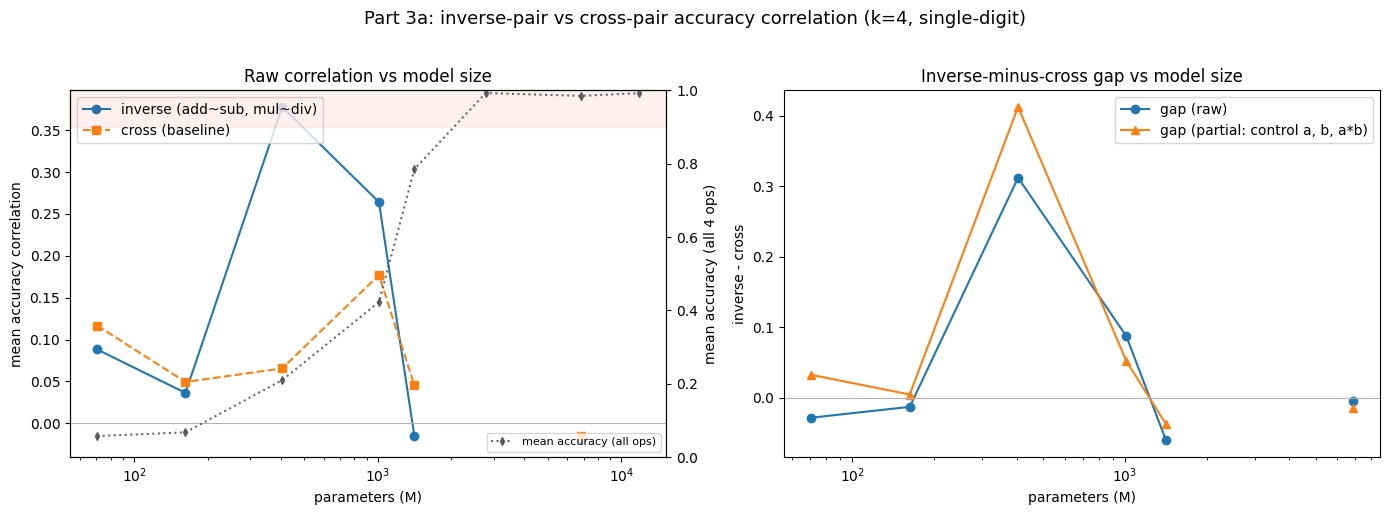

In [37]:
# ── Part 3a: plot inverse vs cross correlation across model size ─────────
x = sweep_df["n_params"].values / 1e6
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5))

# left panel: raw inverse vs cross correlation, with mean accuracy on a twin axis
ax0.plot(x, sweep_df["inverse_mean_raw"], "o-",  color="tab:blue",   label="inverse (add~sub, mul~div)")
ax0.plot(x, sweep_df["cross_mean_raw"],   "s--", color="tab:orange", label="cross (baseline)")
ax0.set_xscale("log"); ax0.axhline(0, color="0.7", lw=0.8)
ax0.set_xlabel("parameters (M)"); ax0.set_ylabel("mean accuracy correlation")
ax0.set_title("Raw correlation vs model size"); ax0.legend(loc="upper left")
ax0b = ax0.twinx()
ax0b.plot(x, sweep_df["mean_acc"], ":", color="0.3", marker="d", ms=4, alpha=0.85,
          label="mean accuracy (all ops)")
ax0b.set_ylabel("mean accuracy (all 4 ops)"); ax0b.set_ylim(0, 1)
ax0b.axhspan(0.9, 1.0, color="red", alpha=0.06)      # saturation zone -> correlation unreliable
ax0b.legend(loc="lower right", fontsize=8)

# right panel: inverse - cross gap (raw and partial)
ax1.plot(x, sweep_df["gap_raw"],     "o-", label="gap (raw)")
ax1.plot(x, sweep_df["gap_partial"], "^-", label="gap (partial: control a, b, a*b)")
ax1.set_xscale("log"); ax1.axhline(0, color="0.7", lw=0.8)
ax1.set_xlabel("parameters (M)"); ax1.set_ylabel("inverse - cross")
ax1.set_title("Inverse-minus-cross gap vs model size"); ax1.legend()

fig.suptitle(f"Part 3a: inverse-pair vs cross-pair accuracy correlation (k={K_SHOT}, single-digit)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part3_sweep_inverse_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 3b: 2-digit operands at 12B

Keep the loaded 12B model but use harder 2-digit operands so accuracy is no longer saturated, giving the cross-operation correlations room to show. We use the **full 90×90 grid** (all `a, b in 10..99`, 8100 cells); all four operations use the same `(a, b)` pairs so the per-cell correlations are aligned.

2-digit grid: 8100 cells (full 90x90); evaluating 12B on 4 operations...


Per-op accuracy (2-digit, 12B):
  addition      : 0.830
  subtraction   : 0.737
  multiplication: 0.236
  division      : 0.190

[raw    ] add~sub= 0.196  mul~div= 0.193  inverse_mean= 0.195  cross_mean= 0.076  GAP=+0.118
[partial] add~sub= 0.080  mul~div= 0.163  inverse_mean= 0.121  cross_mean= 0.010  GAP=+0.111


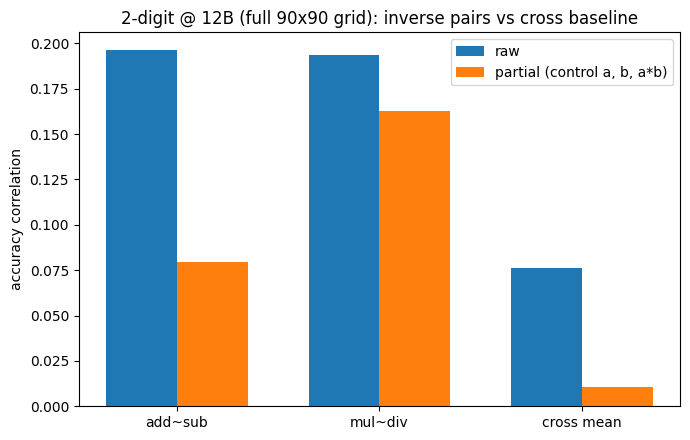

In [38]:
# ── Part 3b: 2-digit fact grid at 12B (full 90x90 grid) ─────────────────
pairs_2d = list(itertools.product(range(10, 100), range(10, 100)))   # full 8100-cell grid
print(f"2-digit grid: {len(pairs_2d)} cells (full 90x90); evaluating 12B on 4 operations...")

res_2d = eval_ops_accuracy(model, tokenizer, pairs_2d, k=K_SHOT)
print("Per-op accuracy (2-digit, 12B):")
for op in OPS:
    print(f"  {OP_NAMES[op]:14s}: {res_2d[op]['correct'].mean():.3f}")

metrics_2d, acc_2d = inverse_vs_cross(res_2d)
print()
for tag in ("raw", "partial"):
    print(f"[{tag:7s}] add~sub={metrics_2d['add_sub_'+tag]: .3f}  mul~div={metrics_2d['mul_div_'+tag]: .3f}  "
          f"inverse_mean={metrics_2d['inverse_mean_'+tag]: .3f}  cross_mean={metrics_2d['cross_mean_'+tag]: .3f}  "
          f"GAP={metrics_2d['gap_'+tag]:+.3f}")

labels = ["add~sub", "mul~div", "cross mean"]
raw = [metrics_2d["add_sub_raw"], metrics_2d["mul_div_raw"], metrics_2d["cross_mean_raw"]]
par = [metrics_2d["add_sub_partial"], metrics_2d["mul_div_partial"], metrics_2d["cross_mean_partial"]]
xb = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(xb - w/2, raw, w, label="raw")
ax.bar(xb + w/2, par, w, label="partial (control a, b, a*b)")
ax.set_xticks(xb); ax.set_xticklabels(labels); ax.axhline(0, color="0.7", lw=0.8)
ax.set_ylabel("accuracy correlation")
ax.set_title("2-digit @ 12B (full 90x90 grid): inverse pairs vs cross baseline")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/part3_2digit_inverse_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Part 4: 2-digit problems (12B, 4-shot) — full Part-2-style analysis

Re-runs the Part 2 pipeline (surprisal + accuracy, summary table, heatmaps, cross-operation correlations) on the **full 90×90 two-digit grid** (`a, b in 10..99`, 8100 cells) at 12B with 4-shot prompting, using the same inverse framing: `+: a+b`, `-: (a+b)-b`, `*: a*b`, `/: (a*b)/b`.

Why: at single digits the 12B is saturated (accuracy ~1, surprisal ~0) so the maps are flat. Two-digit problems are hard enough to reveal real difficulty structure — and unlike single-digit, the **accuracy heatmaps are now informative**. Surprisal is the total `-log P(answer)` set in `eval_logprob`. Results go to `results4`.

In [39]:
# ── Part 4: generate 2-digit problems + evaluate (surprisal & accuracy) ──
def gen_problems_2d(op, pairs):
    sym = OP_SYMBOL[op]
    rows = []
    for a, b in pairs:
        x, y, ans = op_cell(op, a, b)
        rows.append({"op": op, "a": a, "b": b, "x": x, "y": y, "answer": ans,
                     "prompt": f"{x} {sym} {y} =", "target": str(ans),
                     "problem_size": max(abs(x), abs(y), abs(ans)),
                     "freq": freq_expr.get((op, x, y), 0)})
    return pd.DataFrame(rows)

PAIRS_2D = list(itertools.product(range(10, 100), range(10, 100)))   # full 90x90 = 8100 cells
problem_dfs_2d = {op: gen_problems_2d(op, PAIRS_2D) for op in OPS}

results4 = {}
for op in OPS:
    prefix = kshot_fact(op, PAIRS_2D, k=K_SHOT)
    dfk = apply_kshot_prefix(problem_dfs_2d[op], prefix)
    dfk = eval_logprob(model, tokenizer, dfk, batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    dfk = eval_accuracy(model, tokenizer, dfk, batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    dfk["model"] = MODEL_NAME; dfk["k_shot"] = K_SHOT
    results4[op] = dfk
    print(f"{OP_NAMES[op]:14s} | n={len(dfk)} | acc={dfk['correct'].mean():.3f} | mean surprisal={dfk['surprisal'].mean():.3f}")


addition       | n=8100 | acc=0.830 | mean surprisal=0.505


subtraction    | n=8100 | acc=0.737 | mean surprisal=0.867


multiplication | n=8100 | acc=0.236 | mean surprisal=4.570


division       | n=8100 | acc=0.190 | mean surprisal=3.037


In [40]:
# ── Part 4: per-operation summary table (2-digit, 4-shot) ───────────────
rows = []
for op in OPS:
    d = results4[op]
    surp = d["surprisal"].values
    acc  = d["correct"].astype(float).values
    size = d["problem_size"].values.astype(float)
    logf = np.log1p(d["freq"].values.astype(float))
    r_size, p_size = safe_pearson(surp, size)
    r_freq, p_freq = safe_pearson(surp, logf)
    rows.append({"operation": OP_NAMES[op], "n": len(d),
                 "mean_acc": acc.mean(), "std_acc": acc.std(),
                 "r_surp_size": r_size, "p_size": p_size,
                 "r_surp_freq": r_freq, "p_freq": p_freq})
summary_table_2d = pd.DataFrame(rows).set_index("operation")
print("Per-operation summary  (2-digit, 12B, k=%d)" % K_SHOT)
print("  r_surp_size = Pearson r(surprisal, problem size);  r_surp_freq = Pearson r(surprisal, log1p Pile freq)")
print()
print(summary_table_2d.to_string(float_format=lambda v: f"{v: .4g}"))
summary_table_2d


Per-operation summary  (2-digit, 12B, k=4)
  r_surp_size = Pearson r(surprisal, problem size);  r_surp_freq = Pearson r(surprisal, log1p Pile freq)

                   n  mean_acc  std_acc  r_surp_size      p_size  r_surp_freq      p_freq
operation                                                                                
addition        8100    0.8301   0.3755       0.3362  3.186e-213      -0.1938   2.121e-69
subtraction     8100    0.7374     0.44       0.3564  3.662e-241      -0.1882   1.738e-65
multiplication  8100    0.2362   0.4247       0.5551           0      -0.3774  1.301e-272
division        8100    0.1898   0.3921      0.01631      0.1422      -0.1379   1.117e-35


,n,mean_acc,std_acc,r_surp_size,p_size,r_surp_freq,p_freq
operation,,,,,,,
addition,8100,0.830123,0.375524,0.336200,3.186055e-213,-0.193822,2.120544e-69
subtraction,8100,0.737407,0.440043,0.356369,3.662045e-241,-0.188227,1.737530e-65
multiplication,8100,0.236173,0.424730,0.555110,0.000000e+00,-0.377441,1.301437e-272
division,8100,0.189753,0.392106,0.016309,1.421899e-01,-0.137891,1.117321e-35


### 2-digit heatmaps: accuracy and surprisal

Full `a × b` grid (operands 10–99). Accuracy maps show where the 12B fails; surprisal maps show graded difficulty. For `-`/`÷` the answer is `a` (structure runs along rows); for `+`/`×` the answer grows with both operands.

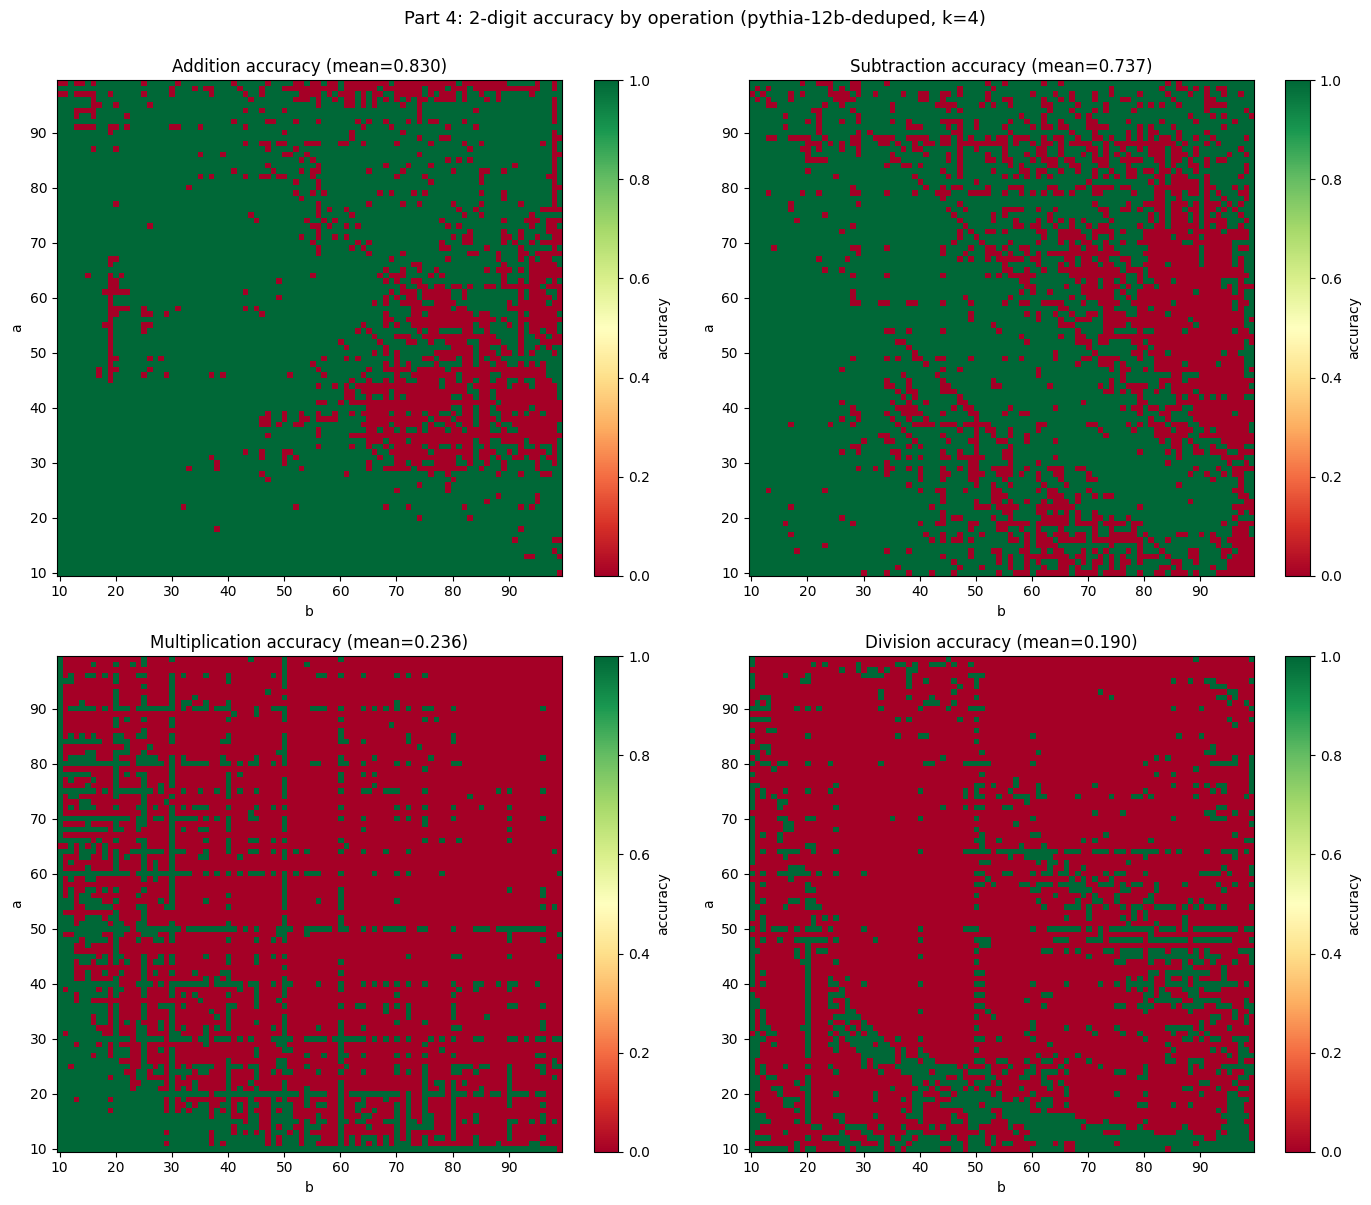

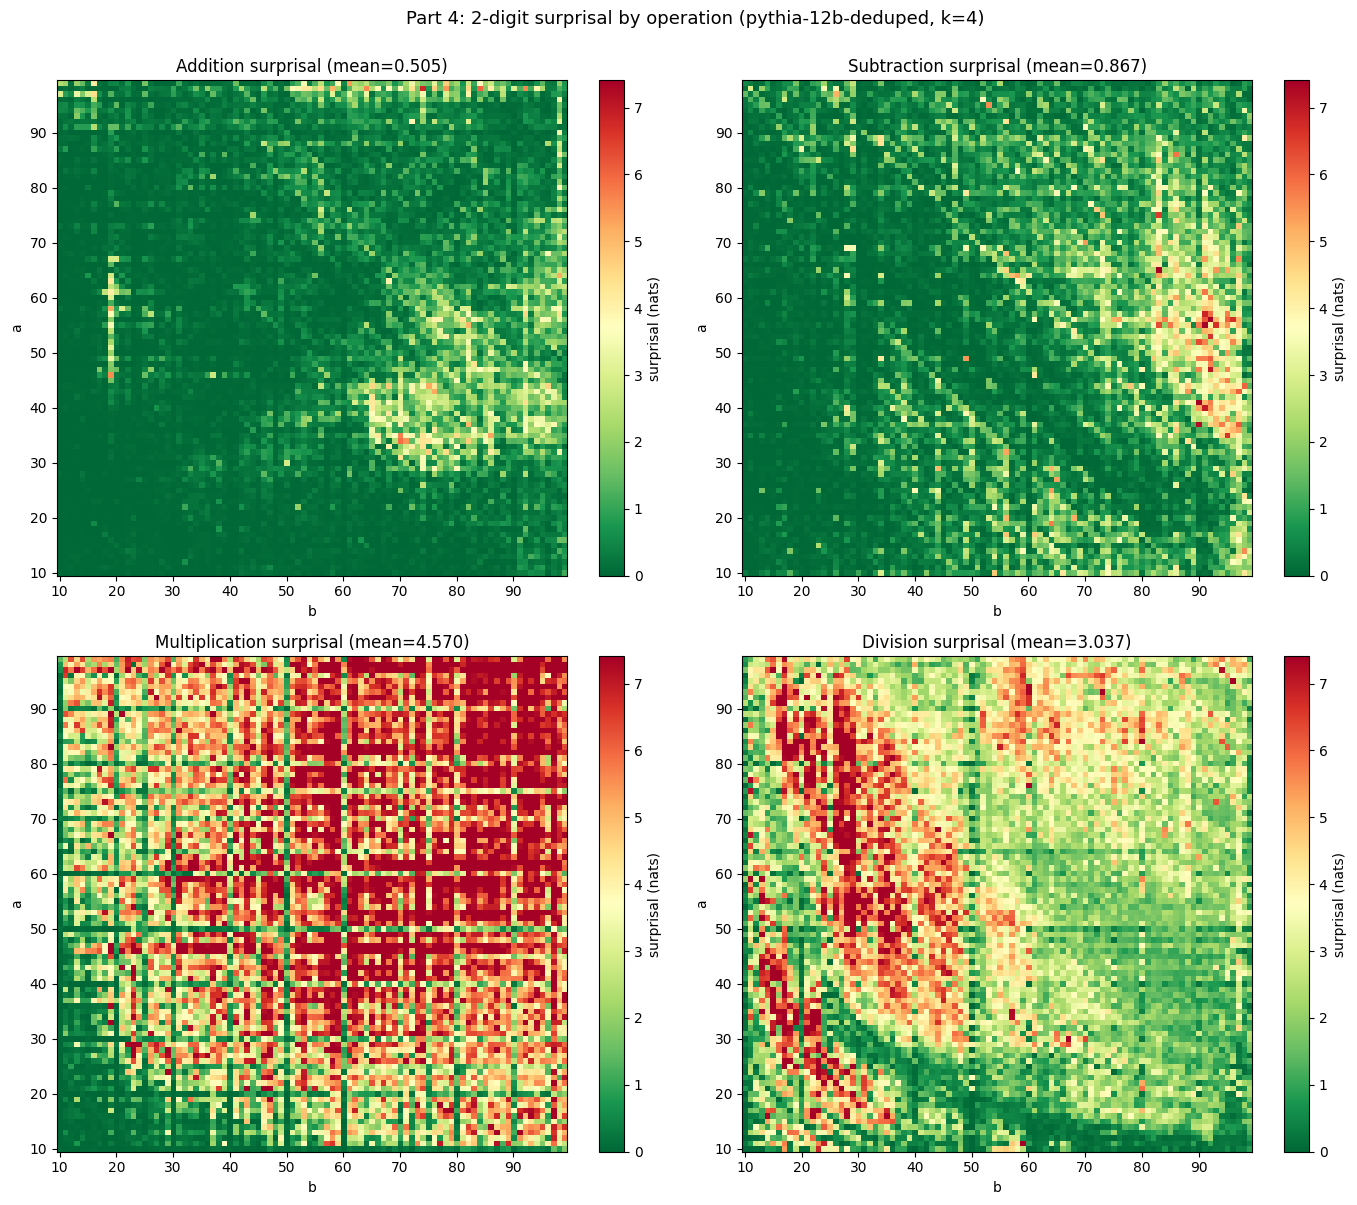

In [41]:
# ── Part 4: accuracy + surprisal heatmaps (2-digit, axes a,b in 10..99) ──
tick_pos = list(range(0, 90, 10)); tick_lab = list(range(10, 100, 10))

# accuracy
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, op in zip(axes.ravel(), OPS):
    piv = results4[op].pivot(index="a", columns="b", values="correct")
    im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto", origin="lower")
    ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
    ax.set_xticklabels(tick_lab); ax.set_yticklabels(tick_lab)
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()} accuracy (mean={results4[op]['correct'].mean():.3f})")
    plt.colorbar(im, ax=ax, label="accuracy")
fig.suptitle(f"Part 4: 2-digit accuracy by operation ({MODEL_NAME.split('/')[-1]}, k={K_SHOT})", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part4_2digit_accuracy_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# surprisal
pooled4 = np.concatenate([results4[op]["surprisal"].values for op in OPS])
vmax4 = float(np.quantile(pooled4, 0.95))
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, op in zip(axes.ravel(), OPS):
    piv = results4[op].pivot(index="a", columns="b", values="surprisal")
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax4, aspect="auto", origin="lower")
    ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
    ax.set_xticklabels(tick_lab); ax.set_yticklabels(tick_lab)
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()} surprisal (mean={results4[op]['surprisal'].mean():.3f})")
    plt.colorbar(im, ax=ax, label="surprisal (nats)")
fig.suptitle(f"Part 4: 2-digit surprisal by operation ({MODEL_NAME.split('/')[-1]}, k={K_SHOT})", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part4_2digit_surprisal_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


### Cross-operation correlations (2-digit)

Inverse-pair vs cross-pair, on both accuracy (raw + partial, controlling `a, b, a*b`) and surprisal.

In [42]:
# ── Part 4: cross-operation correlations (2-digit) ──────────────────────
metrics4, acc4 = inverse_vs_cross(results4)   # accuracy-based, raw + partial
print("ACCURACY correlations (2-digit, 4-shot):")
for tag in ("raw", "partial"):
    print(f"  [{tag:7s}] add~sub={metrics4['add_sub_'+tag]: .3f}  mul~div={metrics4['mul_div_'+tag]: .3f}  "
          f"inverse_mean={metrics4['inverse_mean_'+tag]: .3f}  cross_mean={metrics4['cross_mean_'+tag]: .3f}  "
          f"GAP={metrics4['gap_'+tag]:+.3f}")

surp_wide4 = pd.DataFrame({op: results4[op].set_index(["a", "b"])["surprisal"] for op in OPS})
surp_corr4 = surp_wide4.corr()
print()
print("SURPRISAL correlation matrix (2-digit):")
print(surp_corr4.round(3).to_string())
inv   = [surp_corr4.loc["+", "-"], surp_corr4.loc["*", "/"]]
cross = [surp_corr4.loc[i, j] for i, j in [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]]
print(f"  surprisal inverse_mean={np.nanmean(inv):.3f}  cross_mean={np.nanmean(cross):.3f}  "
      f"GAP={np.nanmean(inv) - np.nanmean(cross):+.3f}")


ACCURACY correlations (2-digit, 4-shot):
  [raw    ] add~sub= 0.196  mul~div= 0.193  inverse_mean= 0.195  cross_mean= 0.076  GAP=+0.118
  [partial] add~sub= 0.080  mul~div= 0.163  inverse_mean= 0.121  cross_mean= 0.010  GAP=+0.111

SURPRISAL correlation matrix (2-digit):
       +      -      *      /
+  1.000  0.302  0.314 -0.144
-  0.302  1.000  0.262 -0.178
*  0.314  0.262  1.000  0.106
/ -0.144 -0.178  0.106  1.000
  surprisal inverse_mean=0.204  cross_mean=0.064  GAP=+0.140


---
# Part 5: single-digit problems, direct operands (1–10), 4-shot

The standard single-digit setup with **operands shown directly** (`a, b ∈ 1..10`): `a + b`, `a − b`, `a × b`, `a / b`. Division keeps only exact (`a mod b = 0`) cells so answers stay integer (≈27 cells); the other three use all 100. **Problem size = |c|** (magnitude of the result; the subtraction answer itself is still the signed difference, but problem size uses its absolute value so it measures answer magnitude). Surprisal is the total `−log P(answer)`, with 4-shot prompting.

We show the surprisal heatmaps and report, per operation, the correlation of surprisal with problem size (`c`) and with Pile frequency. Results go to `results5`.

In [43]:
# ── Part 5: single-digit DIRECT operands (1-10), 4-shot ──────────────────
def gen_direct_1d(op, pairs):
    sym = OP_SYMBOL[op]; rows = []
    for a, b in pairs:
        if op == "/" and a % b != 0:
            continue                       # exact division only -> integer answers
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        rows.append({"op": op, "a": a, "b": b, "prompt": f"{a} {sym} {b} =",
                     "target": str(c), "answer": c, "problem_size": abs(c),   # size = |result|
                     "freq": freq_expr.get((op, a, b), 0)})
    return pd.DataFrame(rows)

def kshot_direct(op, k=K_SHOT, seed=KSHOT_SEED):
    if k == 0:
        return ""
    rng = random.Random(seed)
    pool = [(a, b) for a in range(1, 11) for b in range(1, 11) if not (op == "/" and a % b != 0)]
    rng.shuffle(pool)
    sym = OP_SYMBOL[op]; lines = []
    for a, b in pool[:k]:
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        lines.append(f"{a} {sym} {b} = {c}")
    return "\n".join(lines)

PAIRS_1D = [(a, b) for a in range(1, 11) for b in range(1, 11)]
results5 = {}
for op in OPS:
    df = gen_direct_1d(op, PAIRS_1D)
    df = apply_kshot_prefix(df, kshot_direct(op, k=K_SHOT))
    df = eval_logprob(model, tokenizer, df, batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    df["model"] = MODEL_NAME; df["k_shot"] = K_SHOT
    results5[op] = df
    print(f"{OP_NAMES[op]:14s} | n={len(df):3d} | mean surprisal={df['surprisal'].mean():.3f}")


addition       | n=100 | mean surprisal=0.033


subtraction    | n=100 | mean surprisal=0.507


multiplication | n=100 | mean surprisal=0.028


division       | n= 27 | mean surprisal=0.044


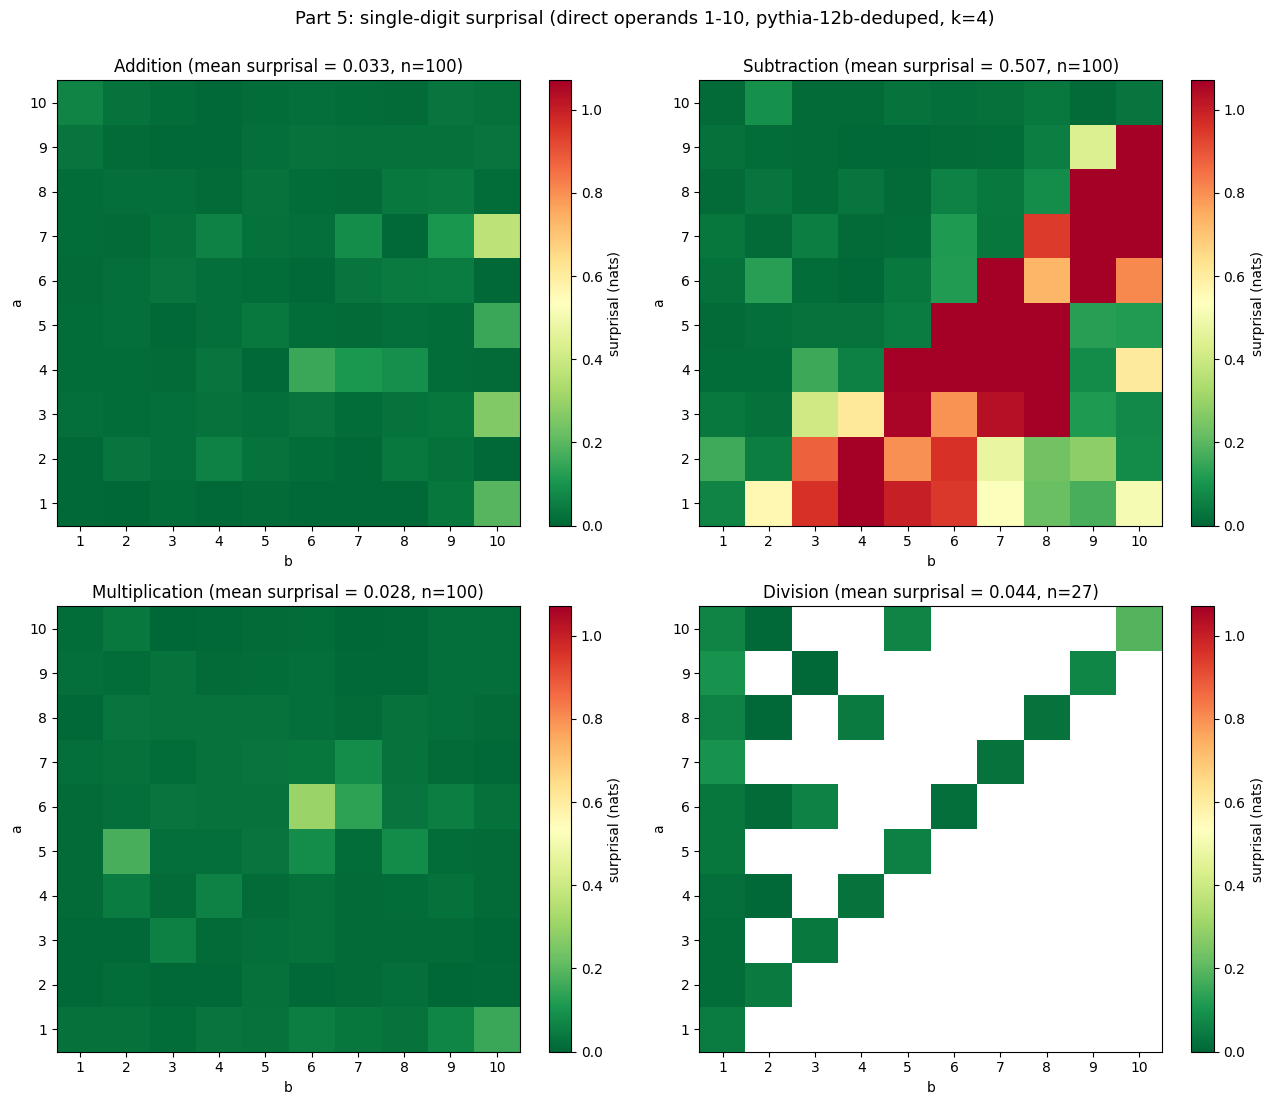

In [44]:
# ── Part 5: surprisal heatmaps (single-digit direct, axes a,b in 1..10) ──
pooled5 = np.concatenate([results5[op]["surprisal"].values for op in OPS])
vmax5 = float(np.quantile(pooled5, 0.95))
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, op in zip(axes.ravel(), OPS):
    piv = (results5[op].pivot(index="a", columns="b", values="surprisal")
           .reindex(index=range(1, 11), columns=range(1, 11)))
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax5, aspect="auto", origin="lower")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(range(1, 11)); ax.set_yticklabels(range(1, 11))
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()} (mean surprisal = {results5[op]['surprisal'].mean():.3f}, n={len(results5[op])})")
    plt.colorbar(im, ax=ax, label="surprisal (nats)")
fig.suptitle(f"Part 5: single-digit surprisal (direct operands 1-10, {MODEL_NAME.split('/')[-1]}, k={K_SHOT})",
             y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part5_1digit_direct_surprisal_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


In [45]:
# ── Part 5: surprisal vs problem size (|c|), and vs Pile frequency ───────
rp = {}
for op in OPS:
    d = results5[op]
    rp[op] = {
        "size": safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float)),
        "freq": safe_pearson(d["surprisal"].values, d["freq"].values.astype(float)),   # raw Pile frequency
    }

# Paper paragraph, filled with the computed values.
# (frequency correlation uses Pearson r on raw Pile frequency)
paragraph = (
    "This is shown quantitatively in the high correlation between surprisal and "
    "problem size (c) for each operation: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction (r = {:.3f}, p = {:.3g}), "
    "multiplication (r = {:.3f}, p = {:.3g}), and division (r = {:.3f}, p = {:.3g}). "
    "Finally, we evaluated whether surprisal on a problem was correlated with the "
    "frequency of that problem in the Pile. This was the case: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction ({:.3f}, p = {:.3g}), "
    "multiplication ({:.3f}, p = {:.3g}), and division ({:.3f}, p = {:.3g})."
).format(
    *rp["+"]["size"], *rp["-"]["size"], *rp["*"]["size"], *rp["/"]["size"],
    *rp["+"]["freq"], *rp["-"]["freq"], *rp["*"]["freq"], *rp["/"]["freq"],
)
print(paragraph)


This is shown quantitatively in the high correlation between surprisal and problem size (c) for each operation: addition (r = 0.212, p = 0.0344), subtraction (r = -0.183, p = 0.0686), multiplication (r = -0.065, p = 0.52), and division (r = 0.146, p = 0.468). Finally, we evaluated whether surprisal on a problem was correlated with the frequency of that problem in the Pile. This was the case: addition (r = -0.113, p = 0.263), subtraction (-0.200, p = 0.0458), multiplication (0.062, p = 0.54), and division (-0.272, p = 0.17).


In [46]:
# ── Part 5: add accuracy (needed for the summary table) ─────────────────
# Greedy decode on the same prompts; adds `correct`/`prediction` to results5.
for op in OPS:
    results5[op] = eval_accuracy(model, tokenizer, results5[op],
                                 batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    print(f"{OP_NAMES[op]:14s} | n={len(results5[op]):3d} | acc = {results5[op]['correct'].mean():.3f}")


addition       | n=100 | acc = 1.000


subtraction    | n=100 | acc = 0.780


multiplication | n=100 | acc = 1.000


division       | n= 27 | acc = 1.000


In [47]:
# ── Part 5: summary table + export to .docx ─────────────────────────────
# Rows = operations; cols = mean accuracy, SD, r(surprisal,size) + p, r(surprisal,freq) + p.
# Frequency uses raw Pile counts; problem size = |c|.
try:
    from docx import Document
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-docx"])
    from docx import Document

assert all("correct" in results5[op].columns for op in OPS), "run the p5_acc cell first"

stats = {}
for op in OPS:
    d = results5[op]
    acc = d["correct"].astype(float).values
    rs, ps = safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float))
    rf, pf = safe_pearson(d["surprisal"].values, d["freq"].values.astype(float))
    stats[op] = (acc.mean(), acc.std(), rs, ps, rf, pf)

# dataframe (for in-notebook view)
part5_table = pd.DataFrame(
    {OP_NAMES[op].capitalize(): stats[op] for op in OPS},
    index=["mean_accuracy", "SD", "r_surprisal_size", "p_size", "r_surprisal_freq", "p_freq"],
).T
print(part5_table.to_string(float_format=lambda v: f"{v: .4g}"))

# .docx export
def fnum(v, sci=False):
    if v != v:
        return "n/a"
    return f"{v:.3g}" if sci else f"{v:.3f}"

doc = Document()
doc.add_heading("Single-digit arithmetic (operands 1-10, direct, 4-shot): per-operation statistics", level=2)
cols = ["Operation", "Mean accuracy", "SD",
        "r (surprisal-size)", "p", "r (surprisal-freq)", "p"]
t = doc.add_table(rows=1, cols=len(cols))
t.style = "Table Grid"
for i, c in enumerate(cols):
    t.rows[0].cells[i].text = c
for op in OPS:
    m, sd, rs, ps, rf, pf = stats[op]
    vals = [OP_NAMES[op].capitalize(), fnum(m), fnum(sd),
            fnum(rs), fnum(ps, True), fnum(rf), fnum(pf, True)]
    cells = t.add_row().cells
    for i, v in enumerate(vals):
        cells[i].text = v

OUT = "../results/tables/part5_stats_table.docx"
doc.save(OUT)
print(f"\nSaved {OUT}  (n: addition/subtraction/multiplication = 100, division = {len(results5['/'])} exact cells)")


                mean_accuracy      SD  r_surprisal_size   p_size  r_surprisal_freq   p_freq
Addition                    1       0            0.2118  0.03435            -0.113   0.2631
Subtraction              0.78  0.4142           -0.1829  0.06857           -0.2002  0.04578
Multiplication              1       0          -0.06515   0.5196           0.06198   0.5401
Division                    1       0            0.1457   0.4684           -0.2718   0.1702

Saved ../results/tables/part5_stats_table.docx  (n: addition/subtraction/multiplication = 100, division = 27 exact cells)


---
# Part 6: 1- and 2-digit problems together, direct operands (1–99), 4-shot

Same as Part 5 but over the **combined single- and double-digit range**: operands `a, b ∈ 1..99` shown directly (`a + b`, `a − b`, `a × b`, `a / b`). Division keeps exact (`a mod b = 0`) cells only; the others use the full 99×99 grid (9801 cells). **Problem size = |c|** (magnitude of the result). Surprisal is the total `−log P(answer)`, 4-shot. Frequency correlation is **Pearson r on raw Pile counts**. Results go to `results6`.

In [48]:
# ── Part 6: direct operands 1-99 (1- and 2-digit), 4-shot ────────────────
def gen_direct(op, pairs):
    sym = OP_SYMBOL[op]; rows = []
    for a, b in pairs:
        if op == "/" and a % b != 0:
            continue                       # exact division only -> integer answers
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        rows.append({"op": op, "a": a, "b": b, "prompt": f"{a} {sym} {b} =",
                     "target": str(c), "answer": c, "problem_size": abs(c),   # size = |result|
                     "freq": freq_expr.get((op, a, b), 0)})
    return pd.DataFrame(rows)

def kshot_direct_pairs(op, pool_pairs, k=K_SHOT, seed=KSHOT_SEED):
    if k == 0:
        return ""
    rng = random.Random(seed)
    pool = [(a, b) for a, b in pool_pairs if not (op == "/" and a % b != 0)]
    rng.shuffle(pool)
    sym = OP_SYMBOL[op]; lines = []
    for a, b in pool[:k]:
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        lines.append(f"{a} {sym} {b} = {c}")
    return "\n".join(lines)

PAIRS_BOTH = [(a, b) for a in range(1, 100) for b in range(1, 100)]   # operands 1..99 (1- and 2-digit)
results6 = {}
for op in OPS:
    df = gen_direct(op, PAIRS_BOTH)
    df = apply_kshot_prefix(df, kshot_direct_pairs(op, PAIRS_BOTH, k=K_SHOT))
    df = eval_logprob(model, tokenizer, df, batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    df["model"] = MODEL_NAME; df["k_shot"] = K_SHOT
    results6[op] = df
    print(f"{OP_NAMES[op]:14s} | n={len(df):5d} | mean surprisal={df['surprisal'].mean():.3f}")


addition       | n= 9801 | mean surprisal=0.628


subtraction    | n= 9801 | mean surprisal=1.697


multiplication | n= 9801 | mean surprisal=3.185


division       | n=  473 | mean surprisal=0.286


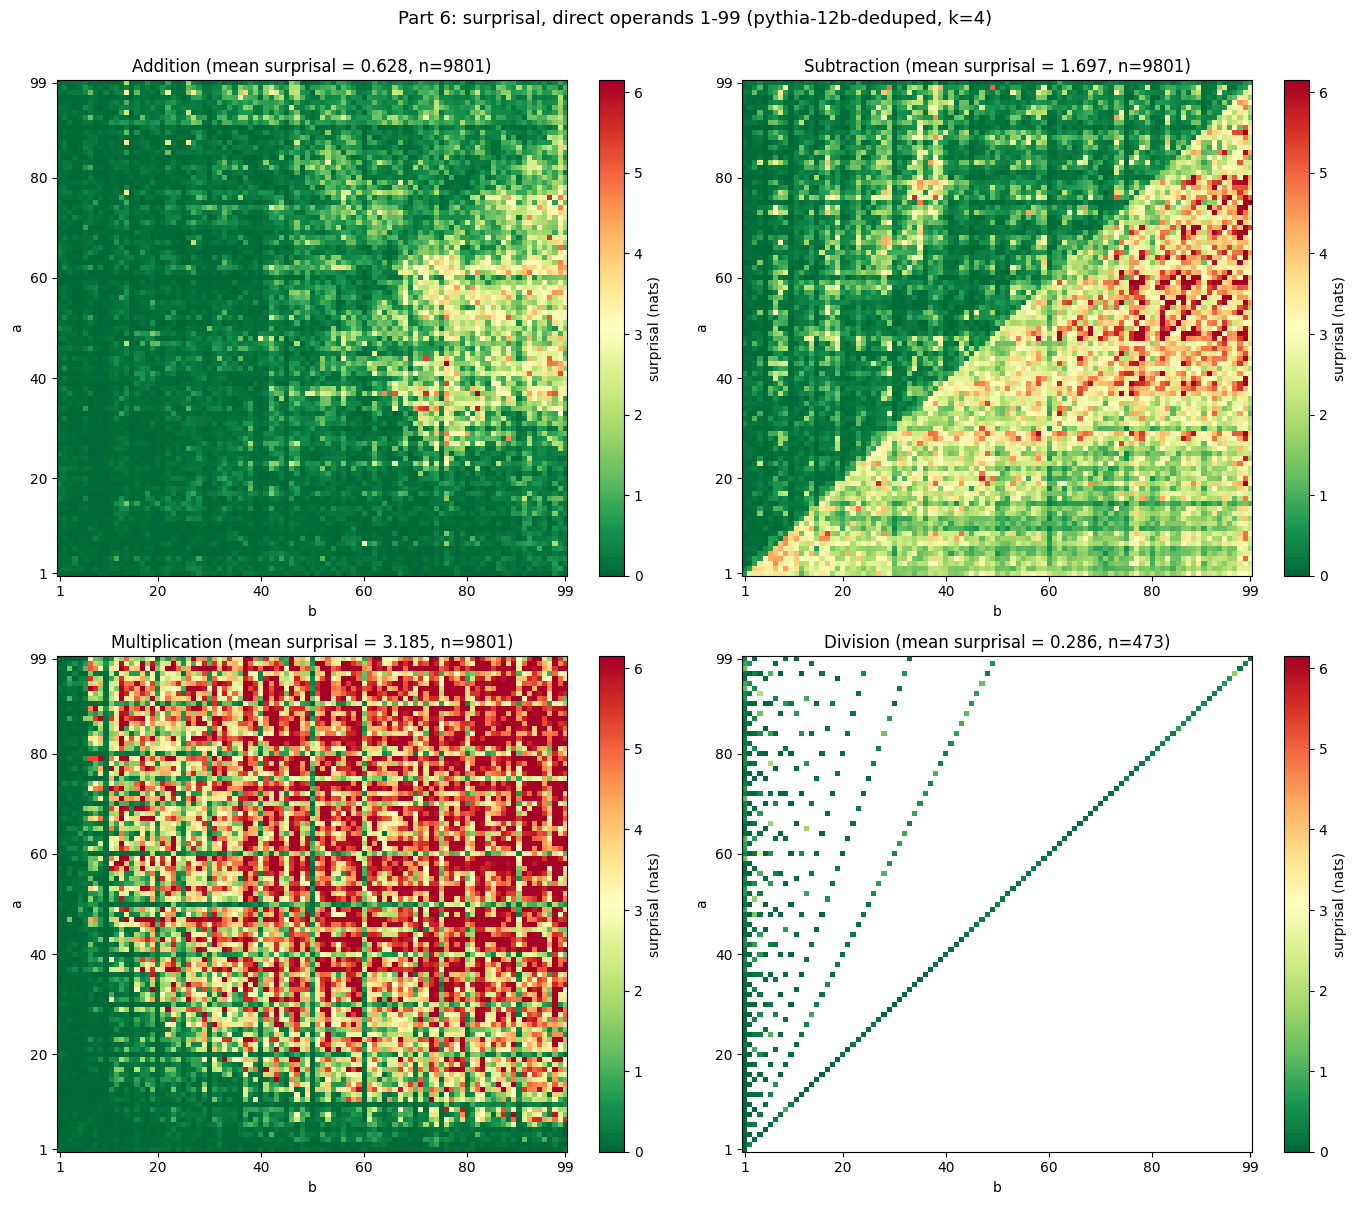

In [49]:
# ── Part 6: surprisal heatmaps (direct operands 1..99) ──────────────────
tick_pos = [0, 19, 39, 59, 79, 98]; tick_lab = [1, 20, 40, 60, 80, 99]
pooled6 = np.concatenate([results6[op]["surprisal"].values for op in OPS])
vmax6 = float(np.quantile(pooled6, 0.95))
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, op in zip(axes.ravel(), OPS):
    piv = (results6[op].pivot(index="a", columns="b", values="surprisal")
           .reindex(index=range(1, 100), columns=range(1, 100)))
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax6, aspect="auto", origin="lower")
    ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
    ax.set_xticklabels(tick_lab); ax.set_yticklabels(tick_lab)
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()} (mean surprisal = {results6[op]['surprisal'].mean():.3f}, n={len(results6[op])})")
    plt.colorbar(im, ax=ax, label="surprisal (nats)")
fig.suptitle(f"Part 6: surprisal, direct operands 1-99 ({MODEL_NAME.split('/')[-1]}, k={K_SHOT})", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part6_both_digit_surprisal_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


In [50]:
# ── Part 6: surprisal vs problem size (|c|) and raw Pile frequency ───────
rp6 = {}
for op in OPS:
    d = results6[op]
    rp6[op] = {
        "size": safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float)),
        "freq": safe_pearson(d["surprisal"].values, d["freq"].values.astype(float)),   # raw frequency
    }

paragraph = (
    "This is shown quantitatively in the high correlation between surprisal and "
    "problem size (c) for each operation: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction (r = {:.3f}, p = {:.3g}), "
    "multiplication (r = {:.3f}, p = {:.3g}), and division (r = {:.3f}, p = {:.3g}). "
    "Finally, we evaluated whether surprisal on a problem was correlated with the "
    "frequency of that problem in the Pile. This was the case: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction ({:.3f}, p = {:.3g}), "
    "multiplication ({:.3f}, p = {:.3g}), and division ({:.3f}, p = {:.3g})."
).format(
    *rp6["+"]["size"], *rp6["-"]["size"], *rp6["*"]["size"], *rp6["/"]["size"],
    *rp6["+"]["freq"], *rp6["-"]["freq"], *rp6["*"]["freq"], *rp6["/"]["freq"],
)
print(paragraph)


This is shown quantitatively in the high correlation between surprisal and problem size (c) for each operation: addition (r = 0.473, p = 0), subtraction (r = -0.061, p = 1.93e-09), multiplication (r = 0.586, p = 0), and division (r = 0.098, p = 0.0323). Finally, we evaluated whether surprisal on a problem was correlated with the frequency of that problem in the Pile. This was the case: addition (r = -0.031, p = 0.00215), subtraction (-0.053, p = 1.22e-07), multiplication (-0.145, p = 2.24e-47), and division (-0.132, p = 0.00407).


---
# Part 7: 1- and 2-digit problems (inverse framing), operands 1–99, 4-shot

Same analysis as Part 6 but with the **inverse framing** instead of direct operands:
`+: a+b`, `-: (a+b)-b=a`, `*: a*b`, `/: (a*b)/b=a`, with `a, b ∈ 1..100`.

All four operations get the full 100×100 grid (10000 cells, integer positive answers — no exact-division restriction needed). **Problem size = |c|** (the result). Surprisal = total `−log P(answer)`, 4-shot. Frequency = **raw Pile count of the displayed expression `x op y`** (note: inverse `-`/`÷` display large derived operands, so Pile coverage is sparse). Results → `results7`.

In [51]:
# ── Part 7: inverse framing, operands 1-100, 4-shot ───────────────────────
def gen_inverse(op, pairs):
    sym = OP_SYMBOL[op]; rows = []
    for a, b in pairs:
        x, y, ans = op_cell(op, a, b)
        rows.append({"op": op, "a": a, "b": b, "x": x, "y": y,
                     "prompt": f"{x} {sym} {y} =", "target": str(ans), "answer": ans,
                     "problem_size": abs(ans),                  # size = |result|
                     "freq": freq_expr.get((op, x, y), 0)})     # freq of displayed 'x op y'
    return pd.DataFrame(rows)

PAIRS_BOTH = [(a, b) for a in range(1, 101) for b in range(1, 101)]   # operands 1..100
results7 = {}
for op in OPS:
    df = gen_inverse(op, PAIRS_BOTH)
    df = apply_kshot_prefix(df, kshot_fact(op, PAIRS_BOTH, k=K_SHOT))   # inverse-framed demos
    df = eval_logprob(model, tokenizer, df, batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    df["model"] = MODEL_NAME; df["k_shot"] = K_SHOT
    results7[op] = df
    print(f"{OP_NAMES[op]:14s} | n={len(df):5d} | mean surprisal={df['surprisal'].mean():.3f}")


addition       | n=10000 | mean surprisal=0.494


subtraction    | n=10000 | mean surprisal=0.624


multiplication | n=10000 | mean surprisal=3.500


division       | n=10000 | mean surprisal=1.940


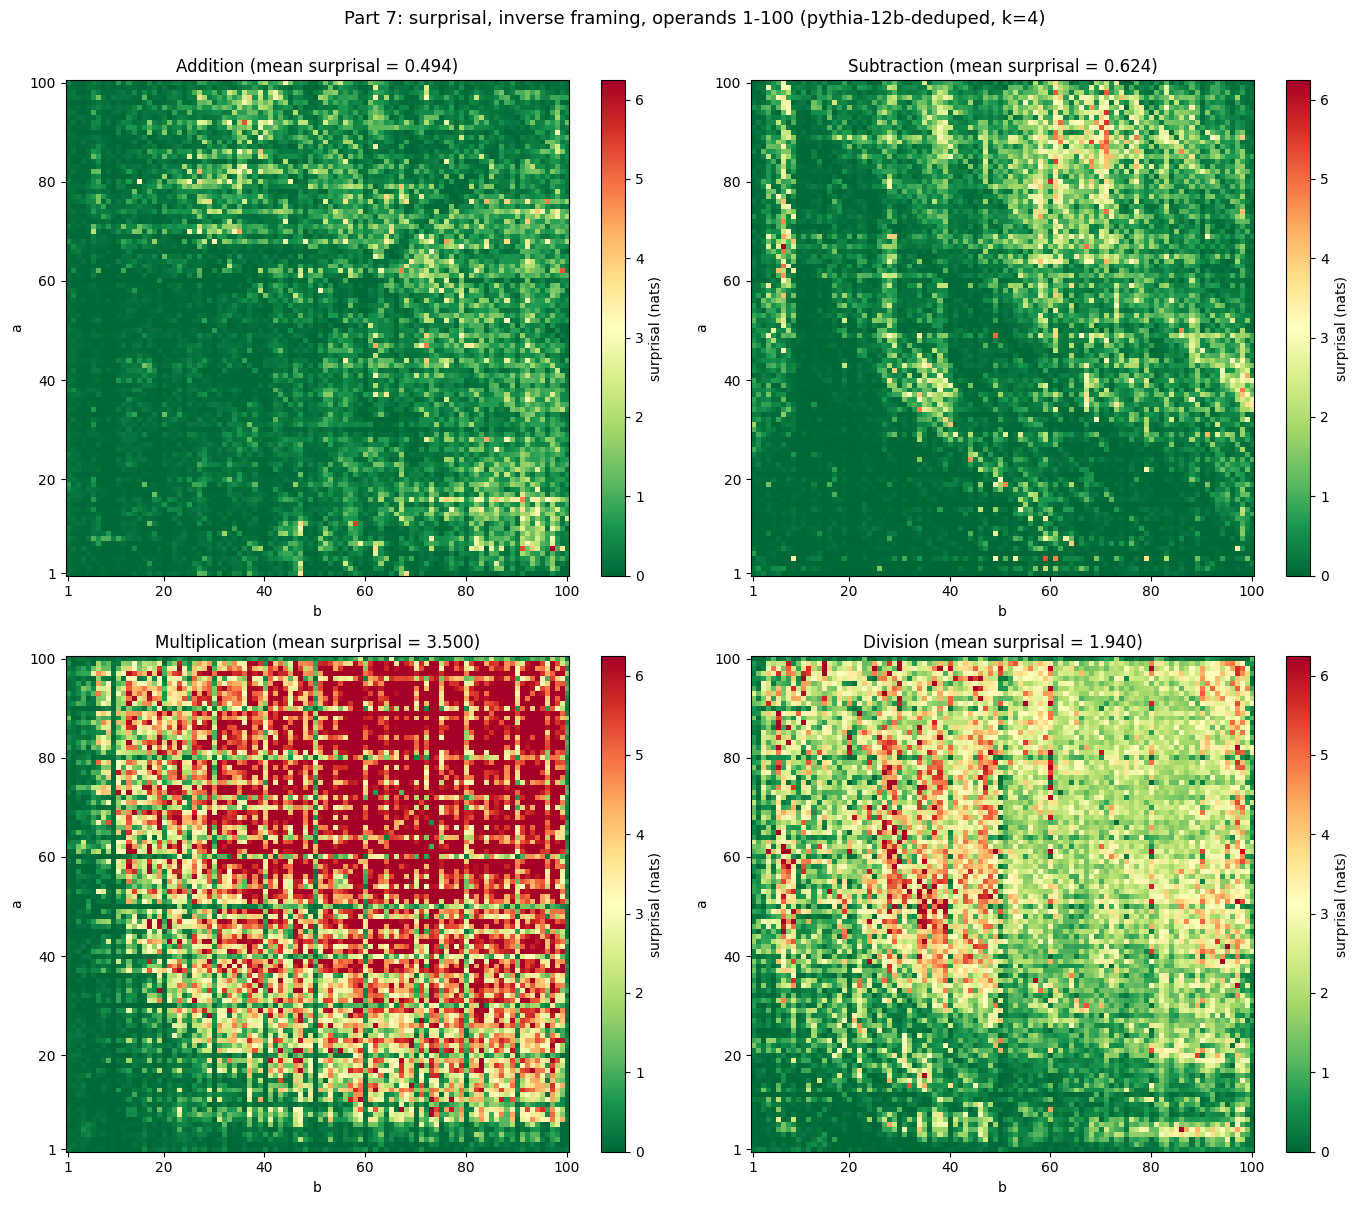

In [52]:
# ── Part 7: surprisal heatmaps (inverse framing, axes = (a,b) grid 1..99) ─
tick_pos = [0, 19, 39, 59, 79, 99]; tick_lab = [1, 20, 40, 60, 80, 100]
pooled7 = np.concatenate([results7[op]["surprisal"].values for op in OPS])
vmax7 = float(np.quantile(pooled7, 0.95))
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, op in zip(axes.ravel(), OPS):
    piv = (results7[op].pivot(index="a", columns="b", values="surprisal")
           .reindex(index=range(1, 101), columns=range(1, 101)))
    im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax7, aspect="auto", origin="lower")
    ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
    ax.set_xticklabels(tick_lab); ax.set_yticklabels(tick_lab)
    ax.set_xlabel("b"); ax.set_ylabel("a")
    ax.set_title(f"{OP_NAMES[op].capitalize()} (mean surprisal = {results7[op]['surprisal'].mean():.3f})")
    plt.colorbar(im, ax=ax, label="surprisal (nats)")
fig.suptitle(f"Part 7: surprisal, inverse framing, operands 1-100 ({MODEL_NAME.split('/')[-1]}, k={K_SHOT})", y=1.0, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part7_inverse_both_digit_surprisal_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


In [53]:
# ── Part 7: surprisal vs problem size (|c|) and raw Pile frequency ───────
rp7 = {}
for op in OPS:
    d = results7[op]
    rp7[op] = {
        "size": safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float)),
        "freq": safe_pearson(d["surprisal"].values, d["freq"].values.astype(float)),   # raw frequency
    }

paragraph = (
    "This is shown quantitatively in the high correlation between surprisal and "
    "problem size (c) for each operation: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction (r = {:.3f}, p = {:.3g}), "
    "multiplication (r = {:.3f}, p = {:.3g}), and division (r = {:.3f}, p = {:.3g}). "
    "Finally, we evaluated whether surprisal on a problem was correlated with the "
    "frequency of that problem in the Pile. This was the case: "
    "addition (r = {:.3f}, p = {:.3g}), subtraction ({:.3f}, p = {:.3g}), "
    "multiplication ({:.3f}, p = {:.3g}), and division ({:.3f}, p = {:.3g})."
).format(
    *rp7["+"]["size"], *rp7["-"]["size"], *rp7["*"]["size"], *rp7["/"]["size"],
    *rp7["+"]["freq"], *rp7["-"]["freq"], *rp7["*"]["freq"], *rp7["/"]["freq"],
)
print(paragraph)


This is shown quantitatively in the high correlation between surprisal and problem size (c) for each operation: addition (r = 0.316, p = 9.97e-231), subtraction (r = 0.373, p = 0), multiplication (r = 0.605, p = 0), and division (r = 0.440, p = 0). Finally, we evaluated whether surprisal on a problem was correlated with the frequency of that problem in the Pile. This was the case: addition (r = -0.033, p = 0.00082), subtraction (-0.052, p = 1.52e-07), multiplication (-0.148, p = 3.96e-50), and division (-0.131, p = 2.24e-39).


### Cross-operation accuracy correlations (inverse-pair "discovery" test)

We correlate, across all `(a,b)` cells, the per-cell **accuracies** of each pair of operations. If the model has discovered that subtraction inverts addition and division inverts multiplication, the **inverse pairs** (addition~subtraction, multiplication~division) should correlate more than the **cross-pair baseline** (addition~multiplication, addition~division, subtraction~multiplication, subtraction~division).

We report raw correlations and **partial** correlations controlling for operand magnitude (`a, b, a*b`) — the latter removes the trivial "big numbers are hard for everything" confound, which inflates every pair.

In [54]:
# ── Part 7: add accuracy to results7 (greedy decode on the same prompts) ──
# Heavy: generation over 10000 cells x 4 ops on the 12B. Surprisal in results7 is
# preserved; this just adds the `correct`/`prediction` columns.
for op in OPS:
    results7[op] = eval_accuracy(model, tokenizer, results7[op],
                                 batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    print(f"{OP_NAMES[op]:14s} | acc = {results7[op]['correct'].mean():.3f}")


addition       | acc = 0.861


subtraction    | acc = 0.806


multiplication | acc = 0.382


division       | acc = 0.370


In [55]:
# ── Part 7: inverse-pair vs cross-pair correlations (surprisal & accuracy) ──
inv_pairs   = [("+", "-"), ("*", "/")]
cross_pairs = [("+", "*"), ("+", "/"), ("-", "*"), ("-", "/")]
nm = {"+": "addition", "-": "subtraction", "*": "multiplication", "/": "division"}

def report_xcorr(value_col):
    wide = pd.DataFrame({op: results7[op].set_index(["a", "b"])[value_col].astype(float) for op in OPS})
    idx = wide.index.to_frame(index=False).astype(float)
    cov = np.column_stack([idx["a"].values, idx["b"].values, (idx["a"] * idx["b"]).values])

    def xcorr(i, j, partial):
        sub = wide[[i, j]].dropna()
        if len(sub) < 5 or sub[i].std() == 0 or sub[j].std() == 0:
            return np.nan, np.nan
        xi, yj = sub[i].values, sub[j].values
        if partial:
            rows = wide.index.get_indexer(sub.index)
            Z = np.column_stack([np.ones(len(sub)), cov[rows]])
            xi, yj = _residualize(xi, Z), _residualize(yj, Z)
            if np.std(xi) == 0 or np.std(yj) == 0:
                return np.nan, np.nan
        return safe_pearson(xi, yj)

    for partial in (False, True):
        tag = "PARTIAL (control a, b, a*b)" if partial else "RAW"
        print(f"  --- {tag} ---")
        inv_r = []
        print("  Inverse pairs:")
        for i, j in inv_pairs:
            r, p = xcorr(i, j, partial); inv_r.append(r)
            print(f"    {nm[i]} ~ {nm[j]:14s}: r = {r:.3f}, p = {p:.3g}")
        cross_r = []
        print("  Cross pairs (baseline):")
        for i, j in cross_pairs:
            r, p = xcorr(i, j, partial); cross_r.append(r)
            print(f"    {nm[i]} ~ {nm[j]:14s}: r = {r:.3f}, p = {p:.3g}")
        im, cm = np.nanmean(inv_r), np.nanmean(cross_r)
        print(f"    --> inverse mean r = {im:.3f}   baseline mean r = {cm:.3f}   gap = {im - cm:+.3f}")
    print()

print("##### SURPRISAL correlations #####")
report_xcorr("surprisal")

if all("correct" in results7[op].columns for op in OPS):
    print("##### ACCURACY correlations #####")
    report_xcorr("correct")
else:
    print("##### ACCURACY correlations: run p7_acc first to add the `correct` column. #####")


##### SURPRISAL correlations #####
  --- RAW ---
  Inverse pairs:
    addition ~ subtraction   : r = 0.147, p = 1.79e-49
    multiplication ~ division      : r = 0.402, p = 0
  Cross pairs (baseline):
    addition ~ multiplication: r = 0.306, p = 3.1e-216
    addition ~ division      : r = 0.076, p = 3.5e-14
    subtraction ~ multiplication: r = 0.384, p = 0
    subtraction ~ division      : r = 0.215, p = 1.03e-104
    --> inverse mean r = 0.274   baseline mean r = 0.245   gap = +0.029
  --- PARTIAL (control a, b, a*b) ---
  Inverse pairs:
    addition ~ subtraction   : r = 0.061, p = 1.09e-09
    multiplication ~ division      : r = 0.254, p = 1.01e-146
  Cross pairs (baseline):
    addition ~ multiplication: r = 0.172, p = 1.7e-67
    addition ~ division      : r = 0.002, p = 0.879
    subtraction ~ multiplication: r = 0.174, p = 1.03e-68
    subtraction ~ division      : r = 0.050, p = 4.59e-07
    --> inverse mean r = 0.157   baseline mean r = 0.100   gap = +0.058

##### ACCURACY 

In [56]:
# ── Part 7: summary table + export to .docx ─────────────────────────────
# Rows = operations; cols = mean accuracy, SD, r(surprisal,size) + p, r(surprisal,freq) + p.
# Inverse framing, operands 1-100; size = |c|; frequency = raw Pile count of displayed 'x op y'.
try:
    from docx import Document
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-docx"])
    from docx import Document

assert all("correct" in results7[op].columns for op in OPS), "run the p7_acc cell first"

stats = {}
for op in OPS:
    d = results7[op]
    acc = d["correct"].astype(float).values
    rs, ps = safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float))
    rf, pf = safe_pearson(d["surprisal"].values, d["freq"].values.astype(float))
    stats[op] = (acc.mean(), acc.std(), rs, ps, rf, pf)

part7_table = pd.DataFrame(
    {OP_NAMES[op].capitalize(): stats[op] for op in OPS},
    index=["mean_accuracy", "SD", "r_surprisal_size", "p_size", "r_surprisal_freq", "p_freq"],
).T
print(part7_table.to_string(float_format=lambda v: f"{v: .4g}"))

def fnum(v, sci=False):
    if v != v:
        return "n/a"
    return f"{v:.3g}" if sci else f"{v:.3f}"

doc = Document()
doc.add_heading("Arithmetic (inverse framing, operands 1-100, 4-shot): per-operation statistics", level=2)
cols = ["Operation", "Mean accuracy", "SD",
        "r (surprisal-size)", "p", "r (surprisal-freq)", "p"]
t = doc.add_table(rows=1, cols=len(cols))
t.style = "Table Grid"
for i, c in enumerate(cols):
    t.rows[0].cells[i].text = c
for op in OPS:
    m, sd, rs, ps, rf, pf = stats[op]
    vals = [OP_NAMES[op].capitalize(), fnum(m), fnum(sd),
            fnum(rs), fnum(ps, True), fnum(rf), fnum(pf, True)]
    cells = t.add_row().cells
    for i, v in enumerate(vals):
        cells[i].text = v

OUT = "../results/tables/part7_stats_table.docx"
doc.save(OUT)
print(f"\nSaved {OUT}  (n = {len(results7['+'])} cells per operation)")


                mean_accuracy      SD  r_surprisal_size      p_size  r_surprisal_freq     p_freq
Addition               0.8608  0.3462             0.316  9.973e-231          -0.03345  0.0008204
Subtraction            0.8065   0.395             0.373           0          -0.05247  1.522e-07
Multiplication         0.3824   0.486            0.6046           0           -0.1481  3.962e-50
Division               0.3697  0.4827            0.4402           0           -0.1307  2.242e-39

Saved ../results/tables/part7_stats_table.docx  (n = 10000 cells per operation)


---
# Part 8: Part-5 analysis across Pythia sizes

Repeats Part 5 (single-digit, **direct** operands 1–10, 4-shot, total-logprob surprisal) on every model in `PYTHIA_MODELS` (70M–12B; the 12B is reused from the earlier load). For each model we compute the surprisal heatmaps and the per-operation correlations of surprisal with problem size (`|c|`) and with raw Pile frequency, then plot how those correlations change with scale.

In [57]:
# ── Part 8: sweep Part-5 (direct single-digit, 4-shot) over Pythia sizes ──
import gc
short = {"+": "add", "-": "sub", "*": "mul", "/": "div"}

def _gen_direct_1d(op, pairs):
    sym = OP_SYMBOL[op]; rows = []
    for a, b in pairs:
        if op == "/" and a % b != 0:
            continue
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        rows.append({"op": op, "a": a, "b": b, "prompt": f"{a} {sym} {b} =",
                     "target": str(c), "answer": c, "problem_size": abs(c),
                     "freq": freq_expr.get((op, a, b), 0)})
    return pd.DataFrame(rows)

def _kshot_direct(op, k=K_SHOT, seed=KSHOT_SEED):
    if k == 0: return ""
    rng = random.Random(seed)
    pool = [(a, b) for a in range(1, 11) for b in range(1, 11) if not (op == "/" and a % b != 0)]
    rng.shuffle(pool)
    sym = OP_SYMBOL[op]; lines = []
    for a, b in pool[:k]:
        c = {"+": a + b, "-": a - b, "*": a * b, "/": a // b}[op]
        lines.append(f"{a} {sym} {b} = {c}")
    return "\n".join(lines)

PAIRS_1D = [(a, b) for a in range(1, 11) for b in range(1, 11)]
sweep5_results, sweep5_rows = {}, []
for name in PYTHIA_MODELS:
    reuse = (name == MODEL_NAME) and ("model" in globals())
    if reuse:
        tok_s, mdl_s = tokenizer, model
        print(f"Reusing loaded {name}")
    else:
        tok_s, mdl_s = load_model(name)
    by_op = {}
    row = {"model": name.split("/")[-1], "n_params": sum(p.numel() for p in mdl_s.parameters())}
    for op in OPS:
        df = _gen_direct_1d(op, PAIRS_1D)
        df = apply_kshot_prefix(df, _kshot_direct(op, k=K_SHOT))
        df = eval_logprob(mdl_s, tok_s, df, batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
        df = eval_accuracy(mdl_s, tok_s, df, batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
        by_op[op] = df
        rs, _ = safe_pearson(df["surprisal"].values, df["problem_size"].values.astype(float))
        rf, _ = safe_pearson(df["surprisal"].values, df["freq"].values.astype(float))
        row[f"{short[op]}_rsize"] = rs
        row[f"{short[op]}_rfreq"] = rf
    sweep5_results[name.split("/")[-1]] = by_op
    sweep5_rows.append(row)
    if not reuse:
        del mdl_s, tok_s
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep5_df = pd.DataFrame(sweep5_rows).set_index("model")
print()
print("Surprisal correlations across Pythia sizes (single-digit, direct, k=%d):" % K_SHOT)
print("  *_rsize = r(surprisal, |c|);  *_rfreq = r(surprisal, raw Pile freq)")
print(sweep5_df.to_string(float_format=lambda v: f"{v: .3g}"))
sweep5_df


Loading EleutherAI/pythia-70m-deduped...
  Loaded: 70M params on cuda:0


Loading EleutherAI/pythia-160m-deduped...
  Loaded: 162M params on cuda:0


Loading EleutherAI/pythia-410m-deduped...
  Loaded: 405M params on cuda:0


Loading EleutherAI/pythia-1b-deduped...
  Loaded: 1012M params on cuda:0


Loading EleutherAI/pythia-1.4b-deduped...


...

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.81s/it]


  Loaded: 6857M params on cuda:0


Reusing loaded EleutherAI/pythia-12b-deduped



Surprisal correlations across Pythia sizes (single-digit, direct, k=4):
  *_rsize = r(surprisal, |c|);  *_rfreq = r(surprisal, raw Pile freq)
                        n_params  add_rsize  add_rfreq  sub_rsize  sub_rfreq  mul_rsize  mul_rfreq  div_rsize  div_rfreq
model                                                                                                                   
pythia-70m-deduped      70426624     0.0696      0.239      0.474     -0.452      0.596     -0.155      0.785     -0.133
pythia-160m-deduped    162322944      -0.18      0.419      0.457      -0.25      0.593     -0.188      0.745   -0.00325
pythia-410m-deduped    405334016      0.573     -0.172    -0.0791      0.145      0.656     -0.184      0.881     -0.284
pythia-1b-deduped     1011781632      0.514     -0.277     -0.108     -0.366      0.641     -0.228      0.368      0.194
pythia-1.4b-deduped   1414647808    -0.0743       0.34     -0.193     -0.101      0.129    -0.0667     -0.423      0.367
pythia-2.8

,n_params,add_rsize,add_rfreq,sub_rsize,sub_rfreq,mul_rsize,mul_rfreq,div_rsize,div_rfreq
model,,,,,,,,,
pythia-70m-deduped,70426624,0.069605,0.238835,0.473904,-0.452379,0.596016,-0.154842,0.785175,-0.132934
pythia-160m-deduped,162322944,-0.179823,0.418609,0.456725,-0.249525,0.592796,-0.187860,0.744658,-0.003248
pythia-410m-deduped,405334016,0.572712,-0.171765,-0.079071,0.144922,0.656324,-0.183988,0.881188,-0.283698
pythia-1b-deduped,1011781632,0.514092,-0.276970,-0.108167,-0.366400,0.641161,-0.228170,0.367657,0.193565
pythia-1.4b-deduped,1414647808,-0.074307,0.339904,-0.193195,-0.101375,0.128554,-0.066699,-0.423458,0.366990
pythia-2.8b-deduped,2775208960,-0.213119,0.546530,0.037055,-0.221773,-0.113009,0.064297,0.410750,-0.473669
pythia-6.9b-deduped,6857302016,-0.364089,0.317408,0.167685,-0.218806,0.041494,0.083274,0.005421,0.086047
pythia-12b-deduped,11846072320,0.211846,-0.112963,-0.182881,-0.200231,-0.065150,0.061981,0.145677,-0.271833


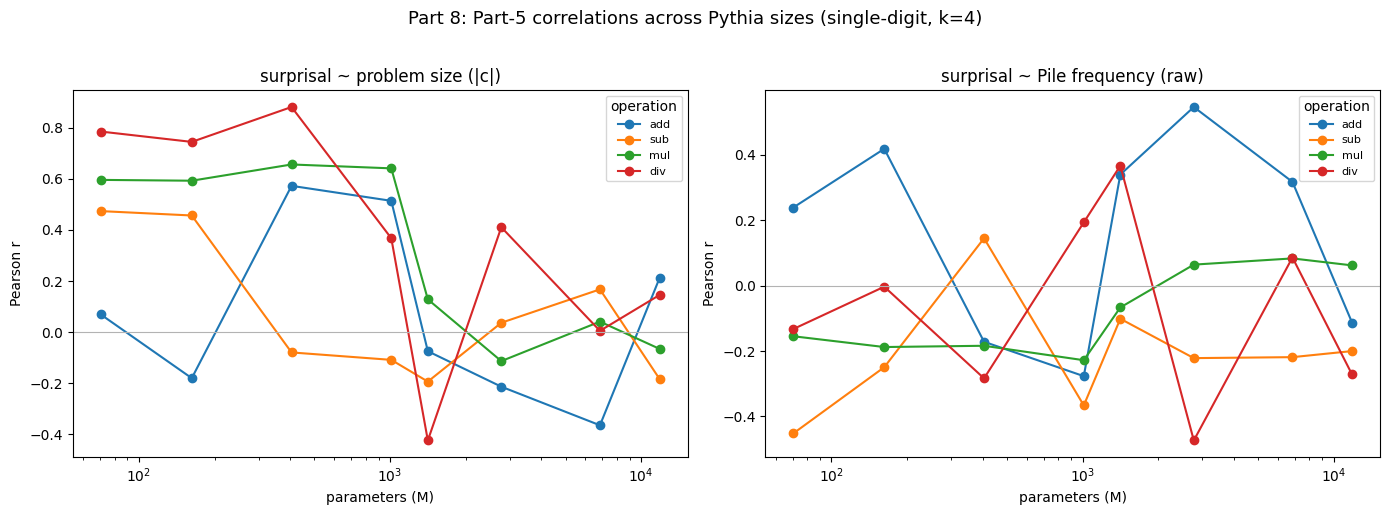

In [58]:
# ── Part 8: correlations vs model size ──────────────────────────────────
x = sweep5_df["n_params"].values / 1e6
colors = {"add": "tab:blue", "sub": "tab:orange", "mul": "tab:green", "div": "tab:red"}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
for k in ["add", "sub", "mul", "div"]:
    axL.plot(x, sweep5_df[f"{k}_rsize"], "o-", color=colors[k], label=k)
    axR.plot(x, sweep5_df[f"{k}_rfreq"], "o-", color=colors[k], label=k)
for ax, t in [(axL, "surprisal ~ problem size (|c|)"), (axR, "surprisal ~ Pile frequency (raw)")]:
    ax.set_xscale("log"); ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("parameters (M)"); ax.set_ylabel("Pearson r"); ax.set_title(t)
    ax.legend(title="operation", fontsize=8)
fig.suptitle(f"Part 8: Part-5 correlations across Pythia sizes (single-digit, k={K_SHOT})", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/part8_part5_sweep_correlations.png", dpi=150, bbox_inches="tight")
plt.show()


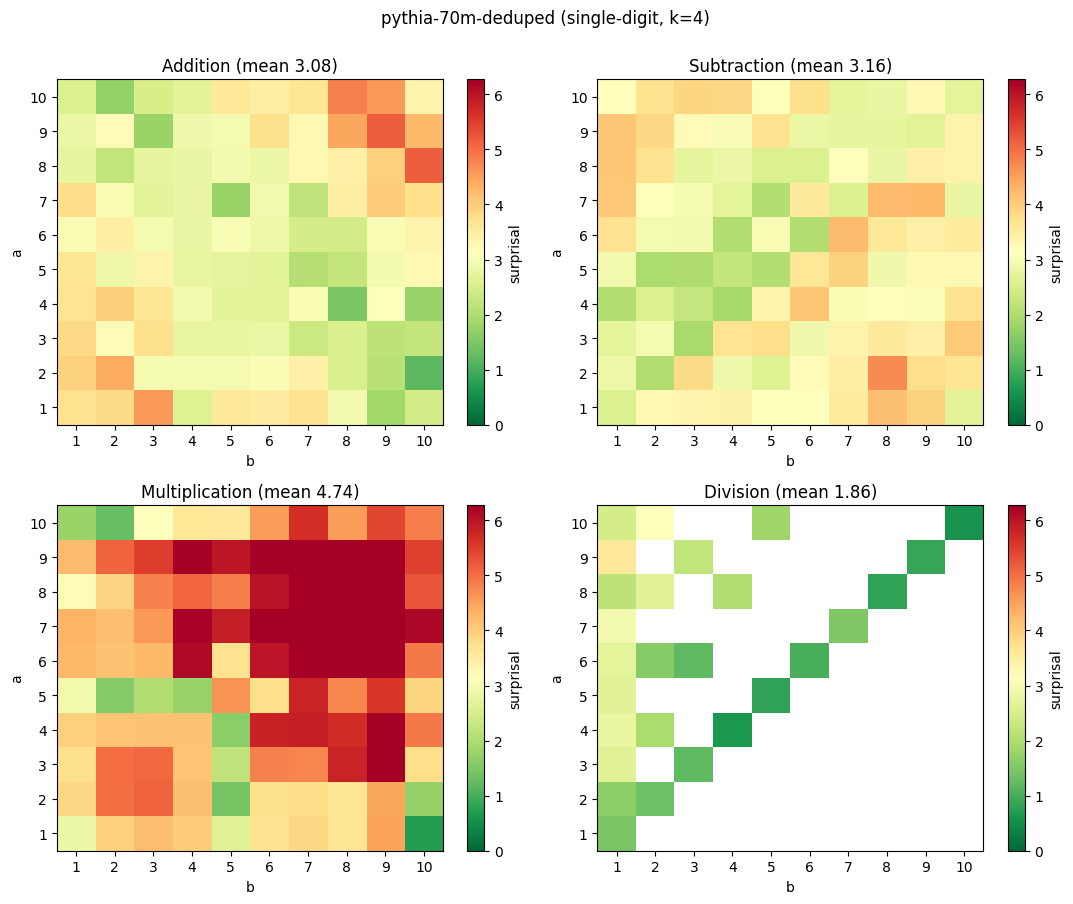

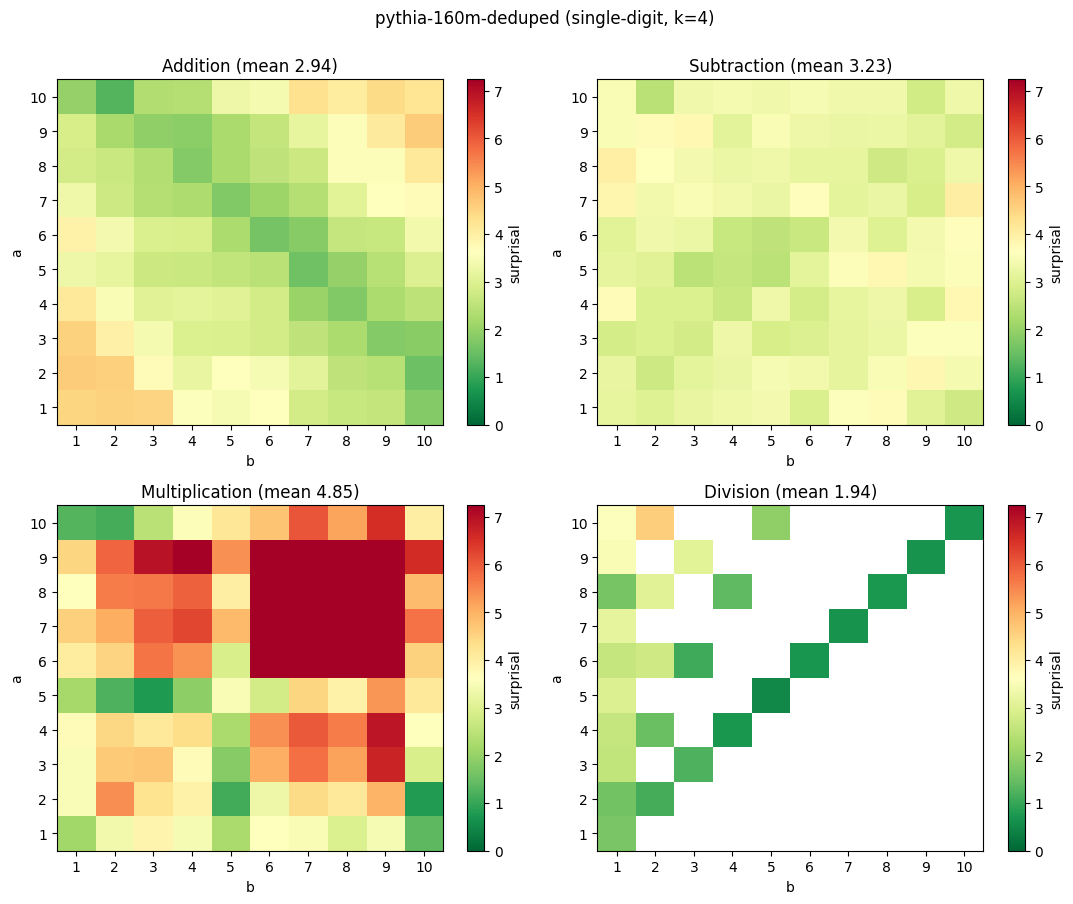

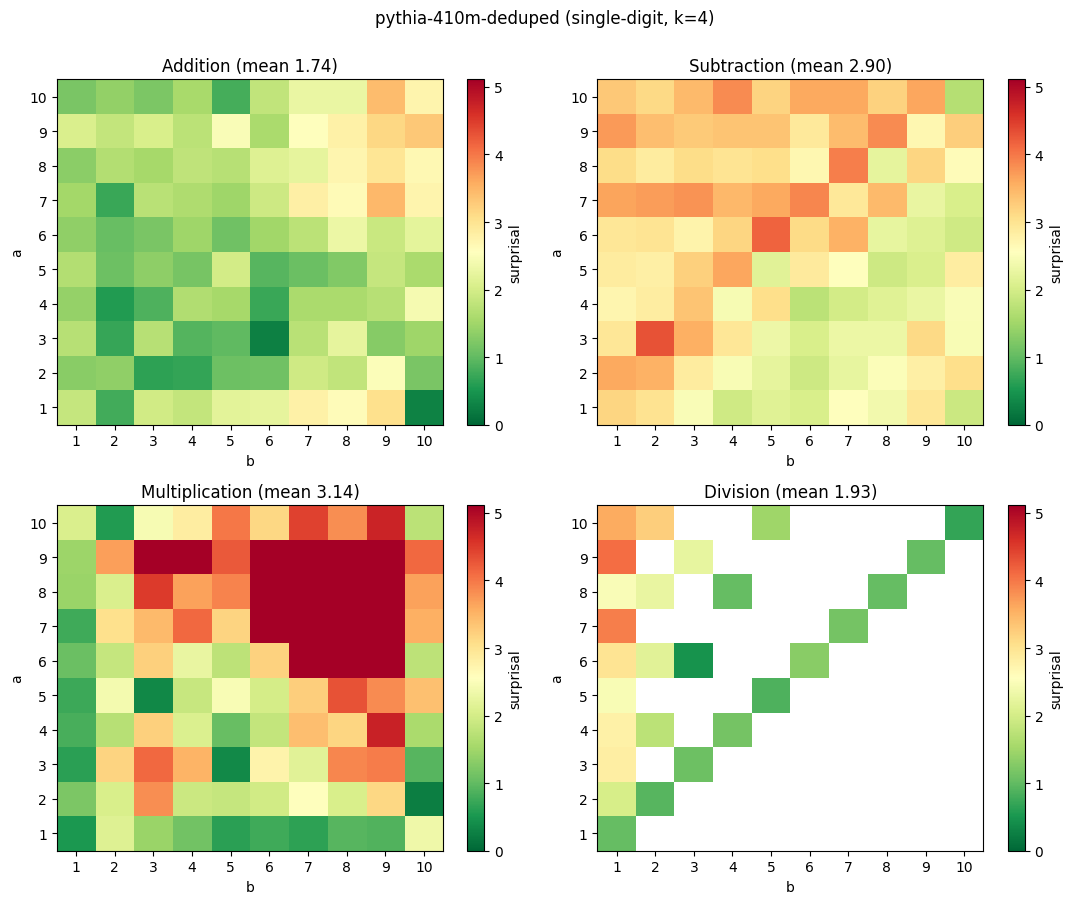

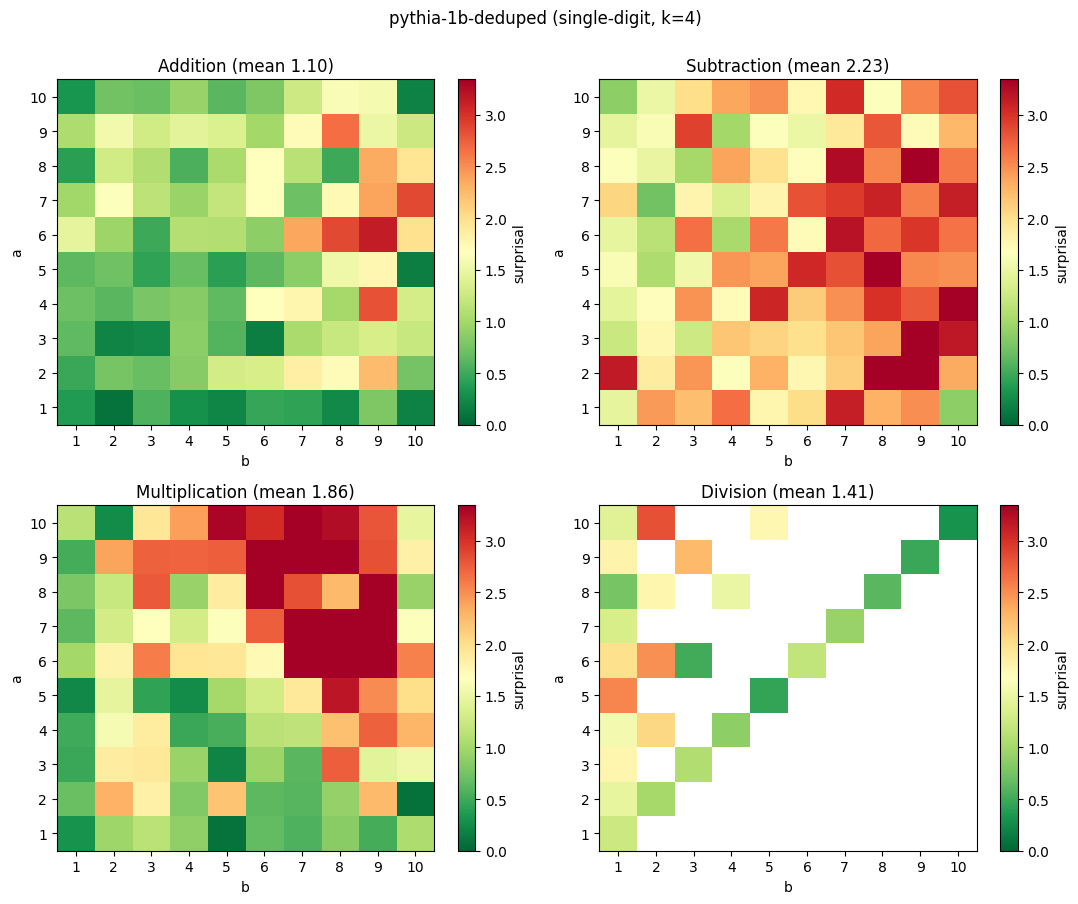

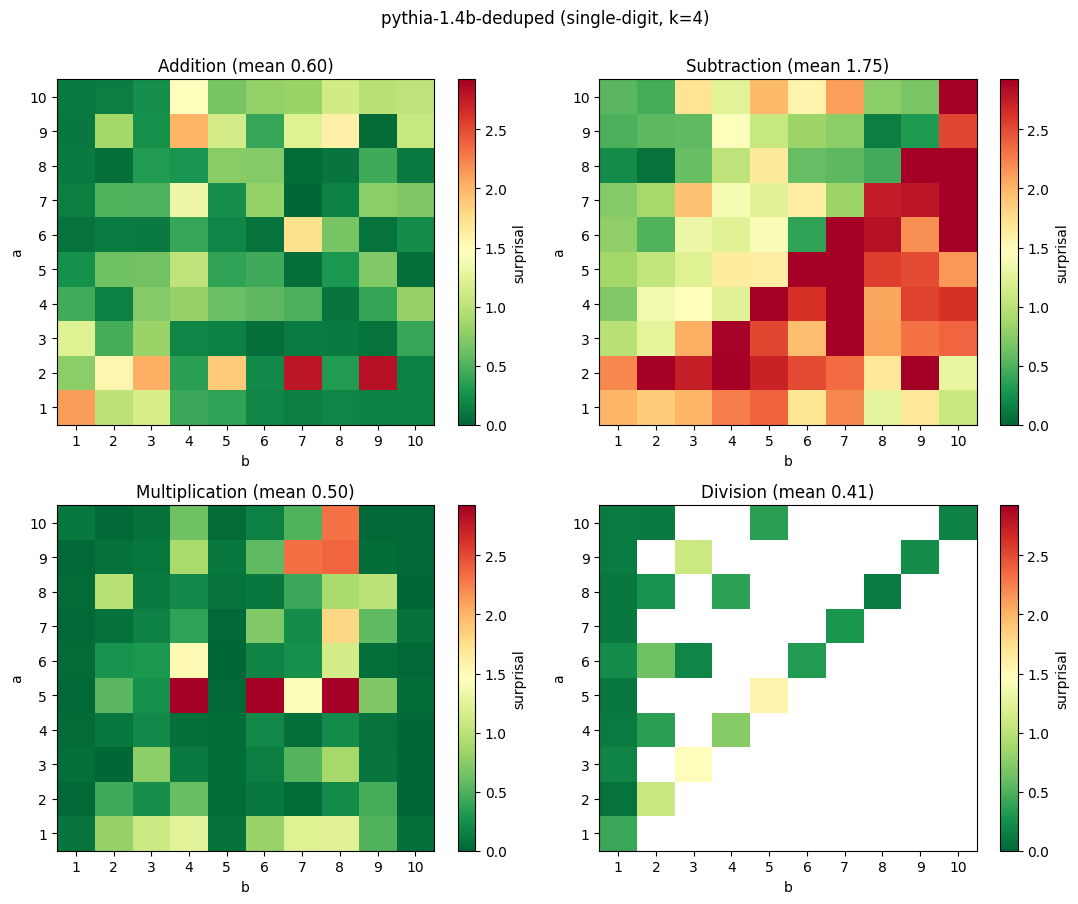

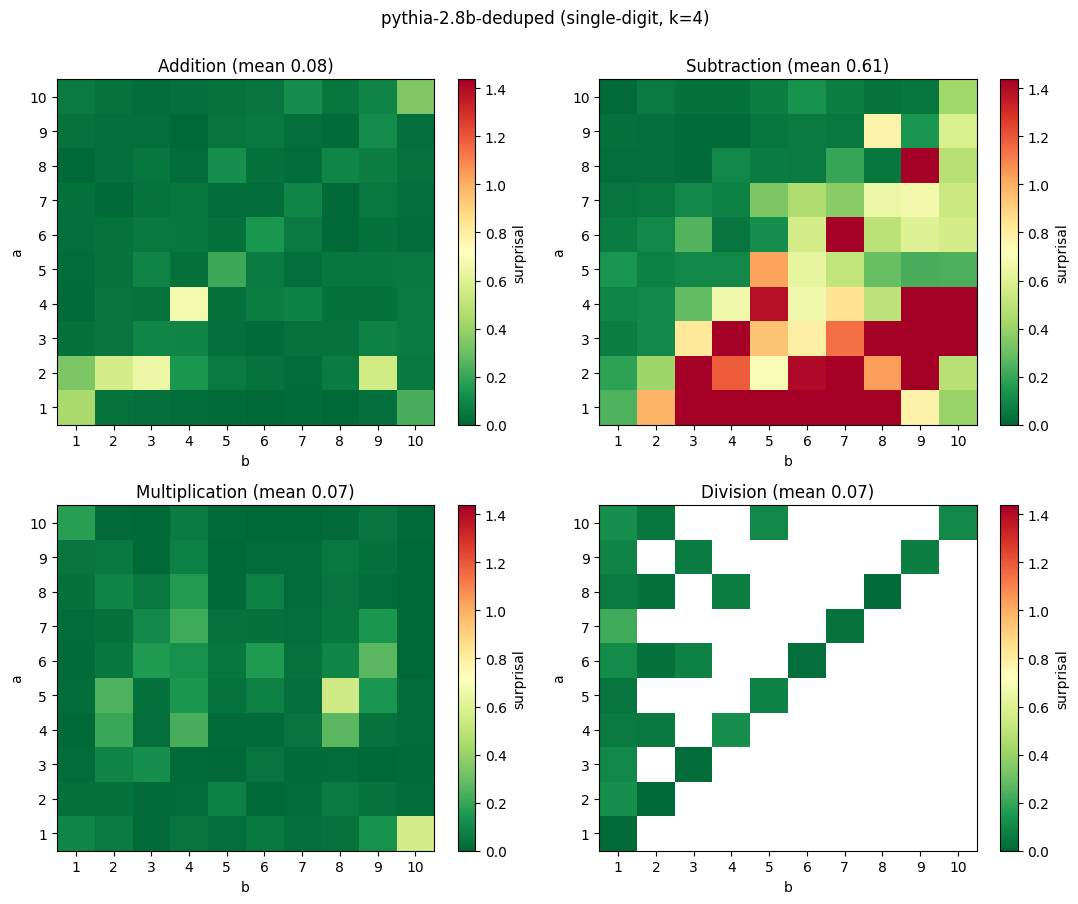

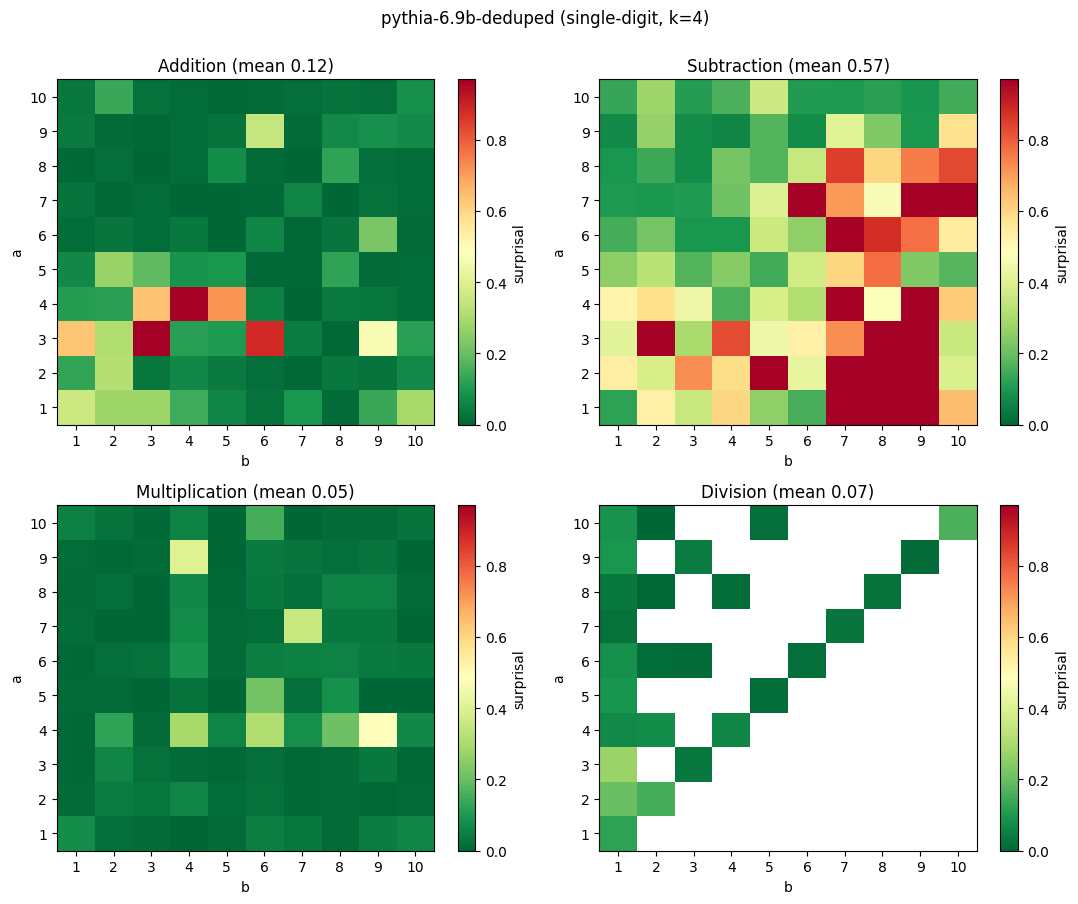

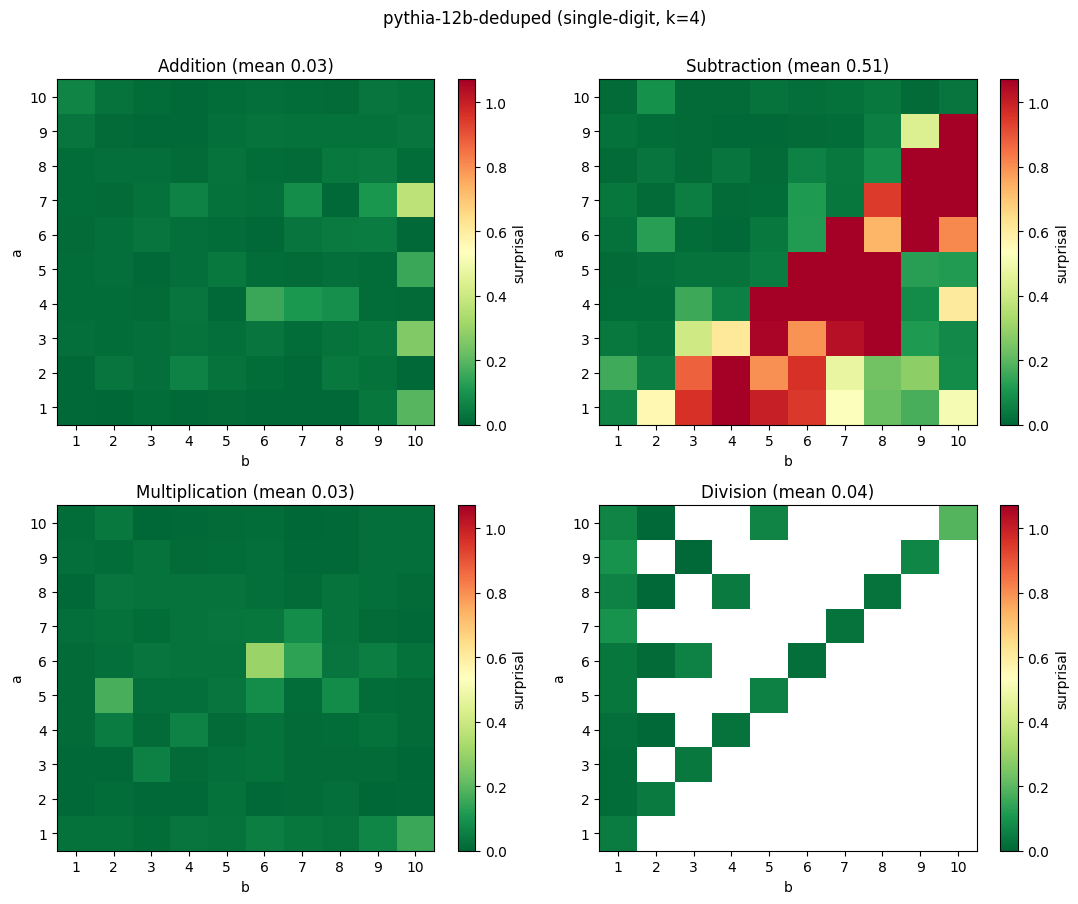

In [59]:
# ── Part 8: surprisal heatmaps per model (single-digit, direct) ─────────
for mshort, by_op in sweep5_results.items():
    pooled = np.concatenate([by_op[op]["surprisal"].values for op in OPS])
    vmax = float(np.quantile(pooled, 0.95))
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, op in zip(axes.ravel(), OPS):
        piv = (by_op[op].pivot(index="a", columns="b", values="surprisal")
               .reindex(index=range(1, 11), columns=range(1, 11)))
        im = ax.imshow(piv.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto", origin="lower")
        ax.set_xticks(range(10)); ax.set_yticks(range(10))
        ax.set_xticklabels(range(1, 11)); ax.set_yticklabels(range(1, 11))
        ax.set_xlabel("b"); ax.set_ylabel("a")
        ax.set_title(f"{OP_NAMES[op].capitalize()} (mean {by_op[op]['surprisal'].mean():.2f})")
        plt.colorbar(im, ax=ax, label="surprisal")
    fig.suptitle(f"{mshort} (single-digit, k={K_SHOT})", y=1.0, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../results/figures/part8_surprisal_{mshort}.png", dpi=130, bbox_inches="tight")
    plt.show()


In [60]:
# ── Part 8: per-model stat tables -> ONE .docx (a section per model) ─────
# Same table as Part 5 (mean acc, SD, r(surprisal,size)+p, r(surprisal,freq)+p),
# one heading+table per model in a single document. Skips the 12B (its single-digit
# table is part5_stats_table.docx).
try:
    from docx import Document
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-docx"])
    from docx import Document

def fnum(v, sci=False):
    if v != v:
        return "n/a"
    return f"{v:.3g}" if sci else f"{v:.3f}"

cols = ["Operation", "Mean accuracy", "SD", "r (surprisal-size)", "p", "r (surprisal-freq)", "p"]
twelve = MODEL_NAME.split("/")[-1]

doc = Document()
doc.add_heading("Single-digit arithmetic (operands 1-10, direct, 4-shot): per-operation statistics by model", level=1)

n_tables = 0
for mshort, by_op in sweep5_results.items():
    if mshort == twelve:
        continue                                   # 12B already in part5_stats_table.docx
    assert all("correct" in by_op[op].columns for op in OPS), f"{mshort}: re-run p8_sweep (needs accuracy)"
    doc.add_heading(mshort, level=2)
    t = doc.add_table(rows=1, cols=len(cols)); t.style = "Table Grid"
    for i, c in enumerate(cols):
        t.rows[0].cells[i].text = c
    for op in OPS:
        d = by_op[op]; acc = d["correct"].astype(float).values
        rs, ps = safe_pearson(d["surprisal"].values, d["problem_size"].values.astype(float))
        rf, pf = safe_pearson(d["surprisal"].values, d["freq"].values.astype(float))
        vals = [OP_NAMES[op].capitalize(), fnum(acc.mean()), fnum(acc.std()),
                fnum(rs), fnum(ps, True), fnum(rf), fnum(pf, True)]
        cells = t.add_row().cells
        for i, v in enumerate(vals):
            cells[i].text = v
    doc.add_paragraph("")                           # spacer between models
    n_tables += 1

OUT = "../results/tables/part8_stats_all_models.docx"
doc.save(OUT)
print(f"Saved {OUT} with {n_tables} per-model tables (smaller models, 12B excluded).")


Saved ../results/tables/part8_stats_all_models.docx with 7 per-model tables (smaller models, 12B excluded).


---

# Part 9: Subproblem-difficulty & prominent-number analyses (Sec 3.5 / Sec 3.6)

Cells below were merged in from `Arithmetic experiments_2_noc_sum_control_carry.ipynb`.
They reproduce the **carry-stratified** (Fig X in Sec 3.5), **extreme-carry**,
**prominent result** and **prominent operand** analyses.

**Dependencies:** these cells assume `df_single_eval`, `df_ctrl_eval`, `df_s2_eval`,
`low_pairs`, `high_pairs` exist from the earlier Parts (single-digit addition cells above).
Run Parts 1–8 first.


### Composite Surprisal Sum Analysis

In [61]:
from scipy.stats import pearsonr, spearmanr

print("=== Correlation: composite sub-step surprisal -> multi-digit performance ===\n")
for col in ["comp_surp_sum", "comp_surp_max"]:
    r, p = spearmanr(df_s2_eval[col], df_s2_eval["surprisal"])
    print(f"{col:15s} vs surprisal : rho={r:+.3f}, p={p:.3e}")
print()
for col in ["comp_surp_sum", "comp_surp_max"]:
    r, p = spearmanr(df_s2_eval[col], df_s2_eval["correct"].astype(float))
    print(f"{col:15s} vs accuracy  : rho={r:+.3f}, p={p:.3e}")

=== Correlation: composite sub-step surprisal -> multi-digit performance ===



NameError: name 'df_s2_eval' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression

X = df_s2_eval[["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]].values
y_surp = df_s2_eval["surprisal"].values
y_acc = df_s2_eval["correct"].astype(int).values

lin = LinearRegression().fit(X, y_surp)

print("=== Simple regressions with controls ===")
print(f"Linear R^2   (surprisal): {lin.score(X, y_surp):.3f}")
print()
print("Feature order:")
print("  comp_surp_sum, carry_to_tens, freq_pair_sum, n_result_digits")
print("Linear coefficients:")
print(pd.Series(lin.coef_, index=["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]).round(4))

if len(np.unique(y_acc)) < 2:
    print("\nSkipped logistic regression: only one accuracy class present in df_s2_eval.")
else:
    log = LogisticRegression(max_iter=1000).fit(X, y_acc)
    print(f"\nLogistic acc (accuracy) : {log.score(X, y_acc):.3f}")

=== Simple regressions with controls ===
Linear R^2   (surprisal): 0.127

Feature order:
  comp_surp_sum, carry_to_tens, freq_pair_sum, n_result_digits
Linear coefficients:
comp_surp_sum      0.0513
carry_to_tens      0.0435
freq_pair_sum     -0.0000
n_result_digits    0.5691
dtype: float64

Logistic acc (accuracy) : 0.830


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

features = ["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]

X = df_s2_eval[features].copy()
X_sm = sm.add_constant(X)  # adds intercept

y_surp = df_s2_eval["surprisal"].values
y_acc = df_s2_eval["correct"].astype(int).values

print("=== Statsmodels regressions with controls ===")

# OLS for surprisal
ols = sm.OLS(y_surp, X_sm).fit()
print("\n=== OLS: surprisal ===")
print(ols.summary())

# If you want just coefficients/p-values:
print("\nOLS coefficients:")
print(ols.params.round(4))
print("\nOLS p-values:")
print(ols.pvalues.round(4))

# Logistic regression for accuracy
if len(np.unique(y_acc)) < 2:
    print("\nSkipped logistic regression: only one accuracy class present in df_s2_eval.")
else:
    logit = sm.Logit(y_acc, X_sm).fit(disp=False)
    print("\n=== Logistic: correct ===")
    print(logit.summary())

    print("\nLogit coefficients:")
    print(logit.params.round(4))
    print("\nLogit p-values:")
    print(logit.pvalues.round(4))

    # Optional: odds ratios
    print("\nOdds ratios:")
    print(np.exp(logit.params).round(4))


=== Statsmodels regressions with controls ===

=== OLS: surprisal ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     293.4
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.76e-236
Time:                        16:54:13   Log-Likelihood:                -9153.6
No. Observations:                8100   AIC:                         1.832e+04
Df Residuals:                    8095   BIC:                         1.835e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
from scipy.stats import ttest_ind

summary = df_ctrl_eval.groupby("category").agg(
    n=("correct", "count"),
    accuracy=("correct", "mean"),
    mean_surprisal=("surprisal", "mean"),
    mean_comp_surp_sum=("comp_surp_sum", "mean"),
    carry_rate=("carry_to_tens", "mean"),
).round(3)
print(summary)

print("\n=== Pairwise t-tests on surprisal ===")
cats = list(summary.index)
for i, c1 in enumerate(cats):
    for c2 in cats[i+1:]:
        s1 = df_ctrl_eval[df_ctrl_eval.category == c1]["surprisal"]
        s2 = df_ctrl_eval[df_ctrl_eval.category == c2]["surprisal"]
        t, p = ttest_ind(s1, s2, equal_var=False)
        print(f"{c1:10s} vs {c2:10s}: t={t:+.2f}, p={p:.3e}")

             n  accuracy  mean_surprisal  mean_comp_surp_sum  carry_rate
category                                                                
easy-easy  400     0.988           0.095               0.010        0.10
easy-hard  400     0.968           0.154               0.284        0.45
hard-easy  400     0.805           0.562               0.284        0.10
hard-hard  400     0.765           0.625               0.558        0.45

=== Pairwise t-tests on surprisal ===
easy-easy  vs easy-hard : t=-2.96, p=3.189e-03
easy-easy  vs hard-easy : t=-10.99, p=6.230e-25
easy-easy  vs hard-hard : t=-11.66, p=1.890e-27
easy-hard  vs hard-easy : t=-8.95, p=5.451e-18
easy-hard  vs hard-hard : t=-9.74, p=9.717e-21
hard-easy  vs hard-hard : t=-1.04, p=2.980e-01


### Visualizations

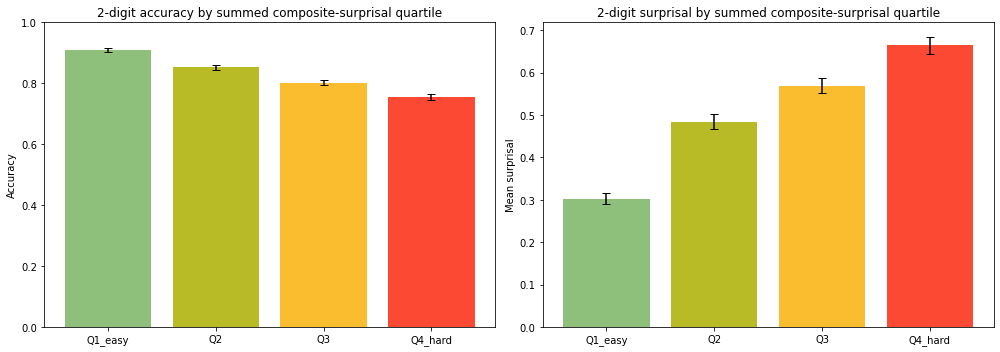

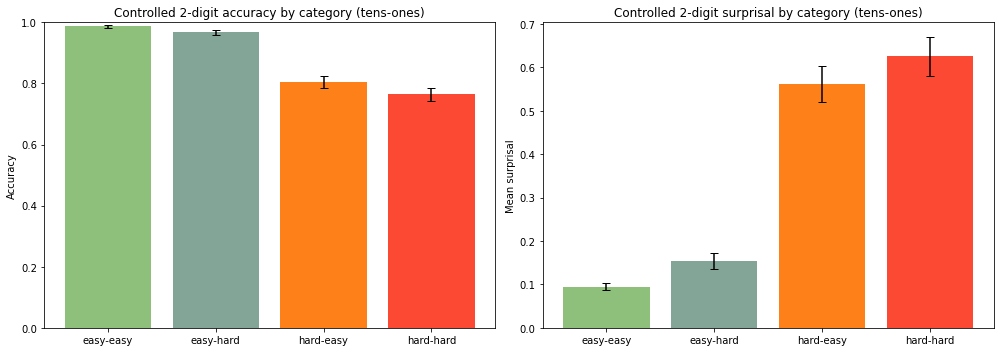

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quartile_order = ["Q1_easy", "Q2", "Q3", "Q4_hard"]
q_acc = df_s2_eval.groupby("score_quartile")["correct"].mean().reindex(quartile_order)
q_acc_se = df_s2_eval.groupby("score_quartile")["correct"].sem().reindex(quartile_order)
q_surp = df_s2_eval.groupby("score_quartile")["surprisal"].mean().reindex(quartile_order)
q_surp_se = df_s2_eval.groupby("score_quartile")["surprisal"].sem().reindex(quartile_order)

axes[0].bar(q_acc.index, q_acc.values, yerr=q_acc_se.values, capsize=4,
            color=["#8ec07c", "#b8bb26", "#fabd2f", "#fb4934"])
axes[0].set_title("2-digit accuracy by summed composite-surprisal quartile")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(q_surp.index, q_surp.values, yerr=q_surp_se.values, capsize=4,
            color=["#8ec07c", "#b8bb26", "#fabd2f", "#fb4934"])
axes[1].set_title("2-digit surprisal by summed composite-surprisal quartile")
axes[1].set_ylabel("Mean surprisal")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
cat_acc = df_ctrl_eval.groupby("category")["correct"].mean().reindex(cat_order)
cat_acc_se = df_ctrl_eval.groupby("category")["correct"].sem().reindex(cat_order)
cat_surp = df_ctrl_eval.groupby("category")["surprisal"].mean().reindex(cat_order)
cat_surp_se = df_ctrl_eval.groupby("category")["surprisal"].sem().reindex(cat_order)
axes[0].bar(cat_acc.index, cat_acc.values, yerr=cat_acc_se.values, capsize=4,
            color=["#8ec07c", "#83a598", "#fe8019", "#fb4934"])
axes[0].set_title("Controlled 2-digit accuracy by category (tens-ones)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(cat_surp.index, cat_surp.values, yerr=cat_surp_se.values, capsize=4,
            color=["#8ec07c", "#83a598", "#fe8019", "#fb4934"])
axes[1].set_title("Controlled 2-digit surprisal by category (tens-ones)")
axes[1].set_ylabel("Mean surprisal")
plt.tight_layout()
plt.show()

### Carry-Stratified Tens-vs-Ones Comparison

To control for carry effects, we can re-plot the controlled categories **within each `carry_to_tens` regime**. This keeps the carry condition fixed and lets us compare whether `hard-easy` (hard tens, easy ones) is worse than `easy-hard` (easy tens, hard ones) among problems with **no carry** and among problems with **carry** separately.

Carry-stratified controlled summary:


n  accuracy  accuracy_se  mean_surprisal  \
carry_to_tens category                                                
0             easy-easy  360     0.989        0.006           0.088   
              easy-hard  220     0.991        0.006           0.097   
              hard-easy  360     0.800        0.021           0.576   
              hard-hard  220     0.773        0.028           0.577   
1             easy-easy   40     0.975        0.025           0.153   
              easy-hard  180     0.939        0.018           0.225   
              hard-easy   40     0.850        0.057           0.431   
              hard-hard  180     0.756        0.032           0.684   

                         surprisal_se  
carry_to_tens category                 
0             easy-easy         0.008  
              easy-hard         0.012  
              hard-easy         0.045  
              hard-hard         0.059  
1             easy-easy         0.039  
              easy-hard         0.037  
              hard-easy         0.082  
              hard-hard         0.069

When this surprisal delta is positive, hard tens are hurting more than hard ones within the same carry regime.


,accuracy_delta_hard_easy_minus_easy_hard,surprisal_delta_hard_easy_minus_easy_hard
carry_to_tens,,
No carry to tens,-0.191,0.479
Carry to tens,-0.089,0.206


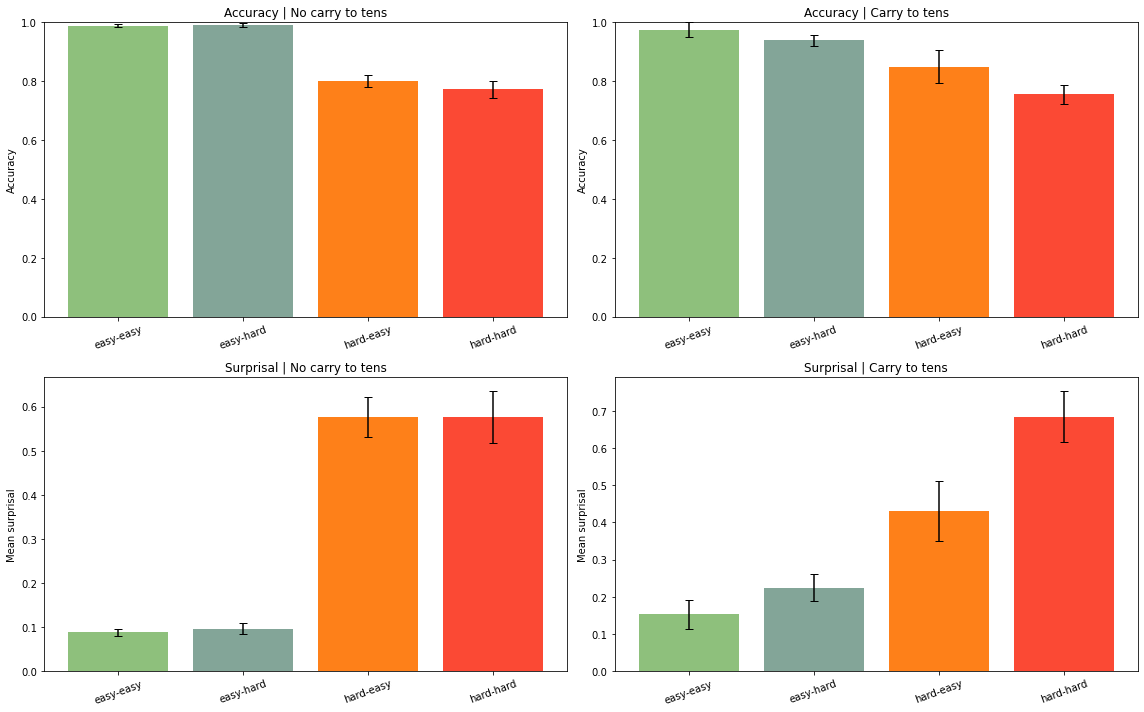

In [ ]:
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
carry_order = [0, 1]
carry_labels = {0: "No carry to tens", 1: "Carry to tens"}
bar_colors = ["#8ec07c", "#83a598", "#fe8019", "#fb4934"]

carry_summary = (
    df_ctrl_eval.groupby(["carry_to_tens", "category"])
              .agg(
                  n=("correct", "size"),
                  accuracy=("correct", "mean"),
                  accuracy_se=("correct", "sem"),
                  mean_surprisal=("surprisal", "mean"),
                  surprisal_se=("surprisal", "sem"),
              )
              .round(3)
)
print("Carry-stratified controlled summary:")
display(carry_summary)

focus = carry_summary.reset_index()
focus = focus[focus["category"].isin(["easy-hard", "hard-easy"])]
focus_piv = focus.pivot(index="carry_to_tens", columns="category").reindex(carry_order)
comparison = pd.DataFrame({
    "accuracy_delta_hard_easy_minus_easy_hard": focus_piv[("accuracy", "hard-easy")] - focus_piv[("accuracy", "easy-hard")],
    "surprisal_delta_hard_easy_minus_easy_hard": focus_piv[("mean_surprisal", "hard-easy")] - focus_piv[("mean_surprisal", "easy-hard")],
}).rename(index=carry_labels).round(3)
print("When this surprisal delta is positive, hard tens are hurting more than hard ones within the same carry regime.")
display(comparison)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, carry_val in enumerate(carry_order):
    subset = df_ctrl_eval[df_ctrl_eval["carry_to_tens"] == carry_val]

    acc_mean = subset.groupby("category")["correct"].mean().reindex(cat_order)
    acc_se = subset.groupby("category")["correct"].sem().reindex(cat_order).fillna(0)
    axes[0, col_idx].bar(cat_order, acc_mean.values, yerr=acc_se.values, capsize=4, color=bar_colors)
    axes[0, col_idx].set_title(f"Accuracy | {carry_labels[carry_val]}")
    axes[0, col_idx].set_ylabel("Accuracy")
    axes[0, col_idx].set_ylim(0, 1)
    axes[0, col_idx].tick_params(axis="x", rotation=20)

    surp_mean = subset.groupby("category")["surprisal"].mean().reindex(cat_order)
    surp_se = subset.groupby("category")["surprisal"].sem().reindex(cat_order).fillna(0)
    axes[1, col_idx].bar(cat_order, surp_mean.values, yerr=surp_se.values, capsize=4, color=bar_colors)
    axes[1, col_idx].set_title(f"Surprisal | {carry_labels[carry_val]}")
    axes[1, col_idx].set_ylabel("Mean surprisal")
    axes[1, col_idx].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Extreme Carry Regimes

We can also isolate the two cleanest carry settings: (1) **no carries at all**, where neither ones nor tens overflow, and (2) **carry in both ones and tens**, where the ones column carries into tens and the tens column carries into hundreds.

Extreme-carry controlled summary:


n  accuracy  accuracy_se  mean_surprisal  \
carry_regime category                                                
carry_both   easy-easy    4     1.000        0.000           0.097   
             easy-hard   18     0.778        0.101           0.474   
             hard-easy   18     0.778        0.101           0.620   
             hard-hard   81     0.605        0.055           0.895   
no_carries   easy-easy  324     0.994        0.004           0.067   
             easy-hard  198     0.990        0.007           0.091   
             hard-easy  198     0.949        0.016           0.186   
             hard-hard  121     0.992        0.008           0.112   

                        surprisal_se  
carry_regime category                 
carry_both   easy-easy         0.036  
             easy-hard         0.130  
             hard-easy         0.133  
             hard-hard         0.098  
no_carries   easy-easy         0.007  
             easy-hard         0.013  
             hard-easy         0.022  
             hard-hard         0.016

Positive surprisal delta means hard tens hurt more than hard ones in that regime.


,accuracy_delta_hard_easy_minus_easy_hard,surprisal_delta_hard_easy_minus_easy_hard
carry_regime,,
No carries at all,-0.041,0.095
Carry in ones and tens,0.000,0.146


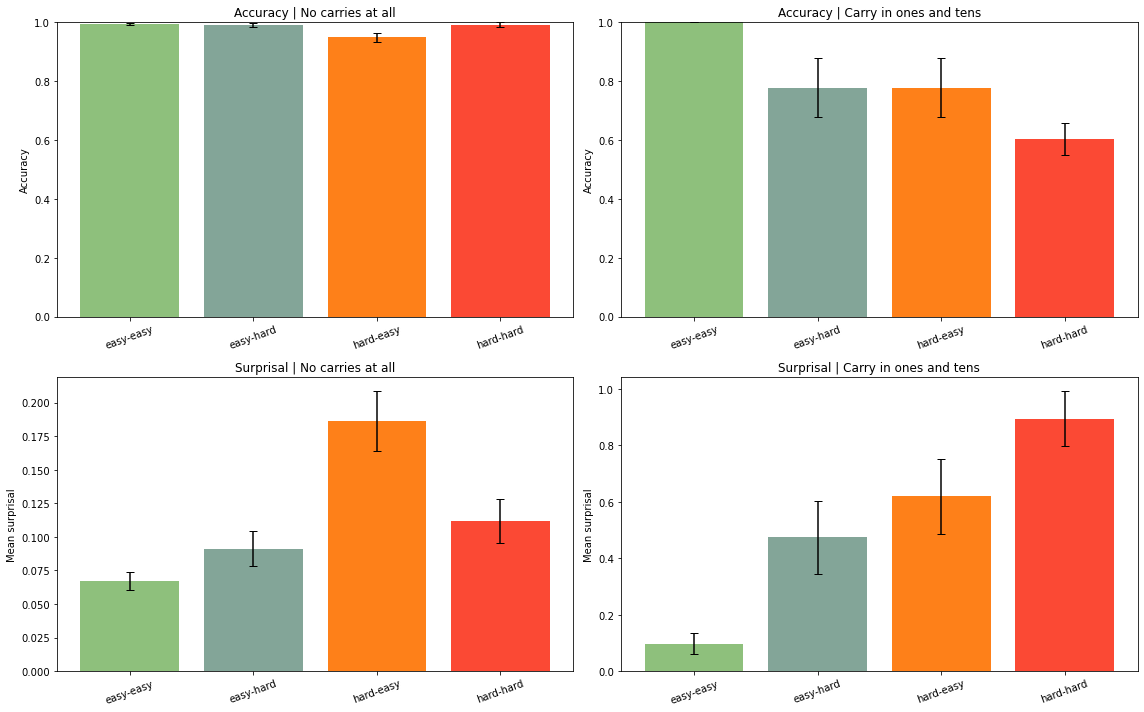

In [ ]:
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
bar_colors = ["#8ec07c", "#83a598", "#fe8019", "#fb4934"]

df_ctrl_extreme = df_ctrl_eval.copy()
df_ctrl_extreme["carry_regime"] = np.select(
    [
        (df_ctrl_extreme["carry_to_tens"] == 0) & (df_ctrl_extreme["tens_has_carry"] == 0),
        (df_ctrl_extreme["carry_to_tens"] == 1) & (df_ctrl_extreme["tens_has_carry"] == 1),
    ],
    ["no_carries", "carry_both"],
    default="other",
)

extreme_order = ["no_carries", "carry_both"]
extreme_labels = {
    "no_carries": "No carries at all",
    "carry_both": "Carry in ones and tens",
}

extreme_summary = (
    df_ctrl_extreme[df_ctrl_extreme["carry_regime"].isin(extreme_order)]
        .groupby(["carry_regime", "category"])
        .agg(
            n=("correct", "size"),
            accuracy=("correct", "mean"),
            accuracy_se=("correct", "sem"),
            mean_surprisal=("surprisal", "mean"),
            surprisal_se=("surprisal", "sem"),
        )
        .round(3)
)
print("Extreme-carry controlled summary:")
display(extreme_summary)

focus = extreme_summary.reset_index()
focus = focus[focus["category"].isin(["easy-hard", "hard-easy"])]
focus_piv = focus.pivot(index="carry_regime", columns="category").reindex(extreme_order)
extreme_comparison = pd.DataFrame({
    "accuracy_delta_hard_easy_minus_easy_hard": focus_piv[("accuracy", "hard-easy")] - focus_piv[("accuracy", "easy-hard")],
    "surprisal_delta_hard_easy_minus_easy_hard": focus_piv[("mean_surprisal", "hard-easy")] - focus_piv[("mean_surprisal", "easy-hard")],
}).rename(index=extreme_labels).round(3)
print("Positive surprisal delta means hard tens hurt more than hard ones in that regime.")
display(extreme_comparison)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, regime in enumerate(extreme_order):
    subset = df_ctrl_extreme[df_ctrl_extreme["carry_regime"] == regime]

    acc_mean = subset.groupby("category")["correct"].mean().reindex(cat_order)
    acc_se = subset.groupby("category")["correct"].sem().reindex(cat_order).fillna(0)
    axes[0, col_idx].bar(cat_order, acc_mean.values, yerr=acc_se.values, capsize=4, color=bar_colors)
    axes[0, col_idx].set_title(f"Accuracy | {extreme_labels[regime]}")
    axes[0, col_idx].set_ylabel("Accuracy")
    axes[0, col_idx].set_ylim(0, 1)
    axes[0, col_idx].tick_params(axis="x", rotation=20)

    surp_mean = subset.groupby("category")["surprisal"].mean().reindex(cat_order)
    surp_se = subset.groupby("category")["surprisal"].sem().reindex(cat_order).fillna(0)
    axes[1, col_idx].bar(cat_order, surp_mean.values, yerr=surp_se.values, capsize=4, color=bar_colors)
    axes[1, col_idx].set_title(f"Surprisal | {extreme_labels[regime]}")
    axes[1, col_idx].set_ylabel("Mean surprisal")
    axes[1, col_idx].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Prominent Result Numbers

Using the same definition as `metrics.ipynb`, we treat **powers of 2**, **powers of 10**, and **multiples of 10** as prominent numbers, and test whether problems whose correct result is prominent have different arithmetic **accuracy** or **surprisal**. This is computed once over the combined addition evaluations rather than split into single-digit vs 2-digit sections.

Combined addition evaluations by source:
two_digit_sample    8100
single_digit         100

=== All evaluated addition problems ===
                  n  accuracy  mean_surprisal  median_surprisal
non_prominent  7232     0.834           0.493             0.156
prominent       968     0.817           0.551             0.149
accuracy delta (prominent - non): -0.017 | z=-1.32, p=1.859e-01
surprisal delta (prominent - non): +0.059 | t=+1.99, p=4.643e-02

Prominent result values: All evaluated addition problems
 result_abs prominent_label  n  accuracy  mean_surprisal
          2             2^1  3     1.000           0.033
          4             2^2  5     1.000           0.039
          8             2^3  9     1.000           0.028
         10            10^1  9     1.000           0.038
         16             2^4  3     1.000           0.018
         20             x10  1     1.000           0.039
         30             x10 11     1.000           0.028
         32             2^5 13   

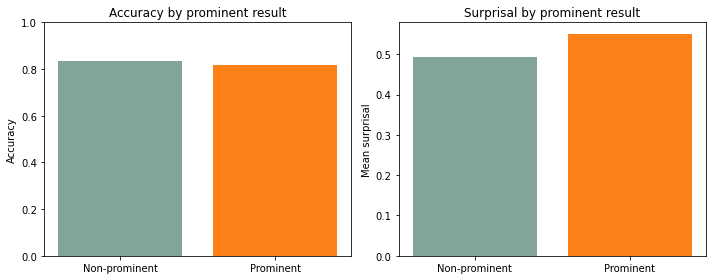

In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

powers_of_2 = {2**i for i in range(1, 60)}
powers_of_10 = {10**i for i in range(1, 20)}
multiples_of_10 = {10 * i for i in range(1, 2000)}
prominent_results = powers_of_2 | powers_of_10 | multiples_of_10

def prominent_result_label(v):
    v = int(v)
    labels = []
    if v in powers_of_2:
        labels.append(f"2^{int(np.log2(v))}")
    if v in powers_of_10:
        labels.append(f"10^{int(np.log10(v))}")
    elif v != 0 and v % 10 == 0:
        labels.append("x10")
    return ", ".join(labels)

df_add_all = pd.concat([
    df_single_eval.assign(
        eval_source="single_digit",
        target_value=df_single_eval["target"].astype(int),
        left_operand=df_single_eval["a"].astype(int),
        right_operand=df_single_eval["b"].astype(int),
    ),
    df_s2_eval.assign(
        eval_source="two_digit_sample",
        target_value=df_s2_eval["C"].astype(int),
        left_operand=df_s2_eval["A"].astype(int),
        right_operand=df_s2_eval["B"].astype(int),
    ),
], ignore_index=True, sort=False)

def annotate_prominent_results(df, result_col):
    out = df.copy()
    out["result_value"] = out[result_col].astype(int)
    out["result_abs"] = out["result_value"].abs()
    out["result_digits"] = out["result_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["is_prominent_result"] = out["result_abs"].isin(prominent_results)
    out["prominent_label"] = out["result_abs"].apply(prominent_result_label)
    return out

df_add_all_prom = annotate_prominent_results(df_add_all, "target_value")

def summarize_prominence(df, dataset_name):
    summary = (
        df.groupby("is_prominent_result")
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
              median_surprisal=("surprisal", "median"),
          )
          .reindex([False, True])
    )
    summary.index = ["non_prominent", "prominent"]
    print(f"=== {dataset_name} ===")
    print(summary.round(3))

    prominent = df[df["is_prominent_result"]]
    baseline = df[~df["is_prominent_result"]]
    z_acc, p_acc = proportions_ztest(
        [prominent["correct"].sum(), baseline["correct"].sum()],
        [len(prominent), len(baseline)],
    )
    t_surp, p_surp = ttest_ind(prominent["surprisal"], baseline["surprisal"], equal_var=False)
    print(f"accuracy delta (prominent - non): {prominent['correct'].mean() - baseline['correct'].mean():+.3f} | z={z_acc:+.2f}, p={p_acc:.3e}")
    print(f"surprisal delta (prominent - non): {prominent['surprisal'].mean() - baseline['surprisal'].mean():+.3f} | t={t_surp:+.2f}, p={p_surp:.3e}")
    print()

def prominent_result_table(df, dataset_name, max_rows=15):
    table = (
        df[df["is_prominent_result"]]
          .groupby(["result_abs", "prominent_label"])
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
          )
          .reset_index()
          .sort_values(["result_abs", "prominent_label"])
    )
    print(f"Prominent result values: {dataset_name}")
    print(table.head(max_rows).round(3).to_string(index=False))
    print()

print("Combined addition evaluations by source:")
print(df_add_all_prom["eval_source"].value_counts().to_string())
print()

summarize_prominence(df_add_all_prom, "All evaluated addition problems")
prominent_result_table(df_add_all_prom, "All evaluated addition problems", max_rows=25)

plot_df = (
    df_add_all_prom.groupby("is_prominent_result")
                  .agg(accuracy=("correct", "mean"), mean_surprisal=("surprisal", "mean"))
                  .reindex([False, True])
)
labels = ["Non-prominent", "Prominent"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, plot_df["accuracy"].values, color=["#83a598", "#fe8019"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by prominent result")

axes[1].bar(labels, plot_df["mean_surprisal"].values, color=["#83a598", "#fe8019"])
axes[1].set_ylabel("Mean surprisal")
axes[1].set_title("Surprisal by prominent result")

plt.tight_layout()
plt.show()


### Prominent Operands

We can also ask whether arithmetic is easier when the **operands themselves** are prominent numbers. Here we use the same prominence definition as above and compare problems where **both operands are prominent**, **both are non-prominent**, or the pair is **mixed**, again over the combined addition evaluations.

=== All evaluated addition problems ===
                               n  accuracy  mean_surprisal  median_surprisal
operand_prominence_pattern                                                  
both_non_prominent          6133     0.822           0.535             0.182
mixed                       1914     0.859           0.408             0.092
both_prominent               153     0.902           0.230             0.042
accuracy delta (both prominent - both non): +0.080 | z=+2.57, p=1.027e-02
surprisal delta (both prominent - both non): -0.305 | t=-7.15, p=2.431e-11

Most surprising both-prominent operand problems: All evaluated addition problems
   prompt  left_operand  right_operand  correct  surprisal operand_prominence_pattern
40 + 70 =            40             70    False      3.209             both_prominent
30 + 50 =            30             50    False      2.908             both_prominent
50 + 90 =            50             90    False      2.262             both_prominent


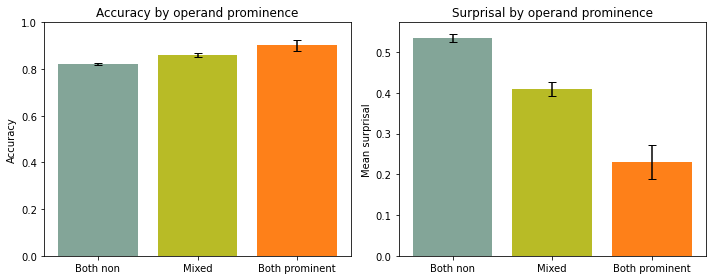

In [ ]:
def annotate_prominent_operands(df, left_col, right_col):
    out = df.copy()
    out["left_operand"] = out[left_col].astype(int)
    out["right_operand"] = out[right_col].astype(int)
    out["left_abs"] = out["left_operand"].abs()
    out["right_abs"] = out["right_operand"].abs()
    out["left_digits"] = out["left_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["right_digits"] = out["right_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["operand_digit_pair"] = out.apply(lambda r: f"{r['left_digits']}d+{r['right_digits']}d", axis=1)
    out["left_prominent"] = out["left_abs"].isin(prominent_results)
    out["right_prominent"] = out["right_abs"].isin(prominent_results)
    out["both_operands_prominent"] = out["left_prominent"] & out["right_prominent"]
    out["both_operands_non_prominent"] = (~out["left_prominent"]) & (~out["right_prominent"])
    out["operand_prominence_pattern"] = np.select(
        [
            out["both_operands_non_prominent"],
            out["both_operands_prominent"],
        ],
        ["both_non_prominent", "both_prominent"],
        default="mixed",
    )
    return out

df_add_all_ops = annotate_prominent_operands(df_add_all_prom, "left_operand", "right_operand")

def summarize_operand_prominence(df, dataset_name):
    order = ["both_non_prominent", "mixed", "both_prominent"]
    summary = (
        df.groupby("operand_prominence_pattern")
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
              median_surprisal=("surprisal", "median"),
          )
          .reindex(order)
    )
    print(f"=== {dataset_name} ===")
    print(summary.round(3))

    prom = df[df["operand_prominence_pattern"] == "both_prominent"]
    non = df[df["operand_prominence_pattern"] == "both_non_prominent"]
    z_acc, p_acc = proportions_ztest(
        [prom["correct"].sum(), non["correct"].sum()],
        [len(prom), len(non)],
    )
    t_surp, p_surp = ttest_ind(prom["surprisal"], non["surprisal"], equal_var=False)
    print(f"accuracy delta (both prominent - both non): {prom['correct'].mean() - non['correct'].mean():+.3f} | z={z_acc:+.2f}, p={p_acc:.3e}")
    print(f"surprisal delta (both prominent - both non): {prom['surprisal'].mean() - non['surprisal'].mean():+.3f} | t={t_surp:+.2f}, p={p_surp:.3e}")
    print()

def prominent_operand_examples(df, dataset_name, max_rows=15):
    cols = [c for c in ["prompt", "left_operand", "right_operand", "correct", "surprisal", "operand_prominence_pattern"] if c in df.columns]
    print(f"Most surprising both-prominent operand problems: {dataset_name}")
    print(
        df[df["operand_prominence_pattern"] == "both_prominent"]
          .sort_values("surprisal", ascending=False)[cols]
          .head(max_rows)
          .round(3)
          .to_string(index=False)
    )
    print()

summarize_operand_prominence(df_add_all_ops, "All evaluated addition problems")
prominent_operand_examples(df_add_all_ops, "All evaluated addition problems", max_rows=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
order = ["both_non_prominent", "mixed", "both_prominent"]
labels = ["Both non", "Mixed", "Both prominent"]
plot_df = (
    df_add_all_ops.groupby("operand_prominence_pattern")
                  .agg(
                      accuracy=("correct", "mean"),
                      accuracy_se=("correct", "sem"),
                      mean_surprisal=("surprisal", "mean"),
                      surprisal_se=("surprisal", "sem"),
                  )
                  .reindex(order)
)
axes[0].bar(labels, plot_df["accuracy"].values, yerr=plot_df["accuracy_se"].fillna(0).values, capsize=4,
            color=["#83a598", "#b8bb26", "#fe8019"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by operand prominence")

axes[1].bar(labels, plot_df["mean_surprisal"].values, yerr=plot_df["surprisal_se"].fillna(0).values, capsize=4,
            color=["#83a598", "#b8bb26", "#fe8019"])
axes[1].set_ylabel("Mean surprisal")
axes[1].set_title("Surprisal by operand prominence")

plt.tight_layout()
plt.show()
